<a href="https://colab.research.google.com/github/raiatul1983/skills-copilot-codespaces-vscode/blob/main/brain_tumor_longitudinal_glioma_progression_pipeli_visualization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ======================================================================================
# SINGLE-CELL KAGGLE PIPELINE
# V9 Uncertainty-Gated Residual Correction + Patient-Level Bagging
# for Next-Timepoint Post-Treatment Glioma Progression Prediction
# ======================================================================================
# Task: progression = 1 if V_next / V_current >= 1.25, else 0.
# Validation: strict nested patient-level grouped CV.
# Run this entire file in ONE Kaggle notebook cell.
# Recommended runtime: CPU or GPU (TPU not required).
# ======================================================================================

import os, sys, re, gc, glob, json, math, time, random, warnings, subprocess
from pathlib import Path
from collections import defaultdict
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)

import numpy as np
np.random.seed(SEED)

# --------------------------------------------------------------------------------------
# 1. ROBUST PACKAGE SETUP
# --------------------------------------------------------------------------------------
def package_available(name):
    try:
        __import__(name)
        return True
    except Exception:
        return False


def pip_install(args):
    cmd = [sys.executable, "-m", "pip", "install", "-q"] + list(args)
    try:
        subprocess.check_call(cmd)
        return True
    except Exception as e:
        print("Installation attempt failed:", " ".join(args))
        print(str(e))
        return False


for pip_name, import_name in [
    ("nibabel", "nibabel"),
    ("scikit-image", "skimage"),
    ("openpyxl", "openpyxl"),
    ("joblib", "joblib"),
    ("tqdm", "tqdm"),
]:
    if not package_available(import_name):
        pip_install([pip_name])

if not package_available("xgboost"):
    pip_install(["xgboost"])
if not package_available("catboost"):
    pip_install(["catboost"])
if not package_available("SimpleITK"):
    pip_install(["SimpleITK"])

# Optional PyRadiomics. The pipeline does NOT depend on it.
# When the completed V5 3D feature cache exists, installation is skipped entirely.
V5_CACHE_HINT = os.path.exists("/kaggle/working/focused_v5_3d_timepoint_features.csv")
PYRADIOMICS_AVAILABLE = package_available("radiomics")
if not PYRADIOMICS_AVAILABLE and not V5_CACHE_HINT:
    print("\nPyRadiomics unavailable. Trying isolated installation routes because no V5 feature cache was found...")
    for attempt in [
        ["--no-build-isolation", "pyradiomics==3.0.1"],
        ["--no-build-isolation", "pyradiomics"],
        ["git+https://github.com/AIM-Harvard/pyradiomics.git"],
    ]:
        if pip_install(attempt) and package_available("radiomics"):
            PYRADIOMICS_AVAILABLE = True
            break
elif V5_CACHE_HINT and not PYRADIOMICS_AVAILABLE:
    print("\nCompleted V5 feature cache detected. PyRadiomics installation is not required for V9 modelling.")

# --------------------------------------------------------------------------------------
# 2. IMPORTS
# --------------------------------------------------------------------------------------
import pandas as pd
import nibabel as nib
import matplotlib.pyplot as plt
import joblib
from tqdm.auto import tqdm
from IPython.display import display
from scipy.stats import skew, kurtosis
from scipy.ndimage import binary_dilation, binary_erosion, gaussian_laplace

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    roc_auc_score, average_precision_score, accuracy_score, balanced_accuracy_score,
    f1_score, precision_score, recall_score, confusion_matrix, matthews_corrcoef,
    brier_score_loss, log_loss, roc_curve, precision_recall_curve
)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

try:
    from sklearn.model_selection import StratifiedGroupKFold
    HAS_SGKF = True
except Exception:
    HAS_SGKF = False

try:
    from skimage.feature import graycomatrix, graycoprops
except Exception:
    from skimage.feature import greycomatrix as graycomatrix
    from skimage.feature import greycoprops as graycoprops

try:
    from skimage.measure import marching_cubes, mesh_surface_area
    HAS_MARCHING_CUBES = True
except Exception:
    HAS_MARCHING_CUBES = False

try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except Exception:
    XGBOOST_AVAILABLE = False

try:
    from catboost import CatBoostClassifier
    CATBOOST_AVAILABLE = True
except Exception:
    CATBOOST_AVAILABLE = False

if PYRADIOMICS_AVAILABLE:
    try:
        import SimpleITK as sitk
        from radiomics import featureextractor
    except Exception:
        PYRADIOMICS_AVAILABLE = False

# --------------------------------------------------------------------------------------
# 3. CONFIGURATION
# --------------------------------------------------------------------------------------
OUTPUT_DIR = Path("/kaggle/working")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MANUSCRIPT_REFERENCE_AUC = 0.713
PROGRESSION_THRESHOLD = 0.25
RING_ITERATIONS = 3

N_OUTER_SPLITS = 5
N_INNER_SPLITS = 4
N_STABILITY_REPEATS = 3
STABILITY_MIN_FREQUENCY = 0.50
TOP_FEATURES_PER_RESAMPLE = 80
MIN_SELECTED_FEATURES = 30
MAX_SELECTED_FEATURES = 80
N_BOOTSTRAP = 1000

USE_OPTIONAL_PYRADIOMICS = True
RICH_MODALITIES = ["t2w", "t2f"]

MODALITY_SUFFIXES = {
    "t1c": "brain_t1c.nii",
    "t1n": "brain_t1n.nii",
    "t2f": "brain_t2f.nii",
    "t2w": "brain_t2w.nii",
}
MASK_SUFFIX = "tumorMask.nii"

TIMEPOINT_FEATURE_PATH = OUTPUT_DIR / "focused_v5_3d_timepoint_features.csv"
TIMEPOINT_CACHE_META_PATH = OUTPUT_DIR / "focused_v5_3d_timepoint_features_meta.json"
PAIR_PATH = OUTPUT_DIR / "focused_v5_nonleaky_longitudinal_pairs.csv"
RESULTS_PATH = OUTPUT_DIR / "focused_v5_nested_results.csv"
OOF_PATH = OUTPUT_DIR / "focused_v5_nested_oof_predictions.csv"
FOLD_DETAILS_PATH = OUTPUT_DIR / "focused_v5_nested_fold_details.csv"
FEATURE_STABILITY_PATH = OUTPUT_DIR / "focused_v5_feature_stability.csv"
FINAL_STABILITY_PATH = OUTPUT_DIR / "focused_v5_final_feature_stability.csv"
CALIBRATION_PATH = OUTPUT_DIR / "focused_v5_calibration_table.csv"
DCA_PATH = OUTPUT_DIR / "focused_v5_decision_curve.csv"
FINAL_MODEL_PATH = OUTPUT_DIR / "focused_v5_final_model_bundle.pkl"
SUMMARY_PATH = OUTPUT_DIR / "focused_v5_manuscript_ready_summary.csv"

print("\n" + "=" * 90)
print("V9 UNCERTAINTY-GATED RESIDUAL GLIOMA PROGRESSION PIPELINE")
print("=" * 90)
print("Custom 3D radiomics: ENABLED")
print("Optional PyRadiomics:", PYRADIOMICS_AVAILABLE and USE_OPTIONAL_PYRADIOMICS)
print("XGBoost available:", XGBOOST_AVAILABLE)
print("CatBoost available:", CATBOOST_AVAILABLE)
print("Output directory:", OUTPUT_DIR)
print("Manuscript reference AUC:", MANUSCRIPT_REFERENCE_AUC)
print("=" * 90)

# --------------------------------------------------------------------------------------
# 4. DATASET DISCOVERY
# --------------------------------------------------------------------------------------
def find_mu_root(input_root="/kaggle/input"):
    candidates = []
    for root, dirs, files in os.walk(input_root):
        if len([d for d in dirs if d.startswith("PatientID_")]) >= 10:
            candidates.append(root)
    if not candidates:
        raise FileNotFoundError("MU-Glioma-Post root not found. Attach the imaging dataset.")
    return sorted(candidates, key=lambda x: (len(x), x))[0]


def find_clinical_file(input_root="/kaggle/input"):
    files = glob.glob(os.path.join(input_root, "**", "*.xlsx"), recursive=True)
    if not files:
        return None
    preferred = [f for f in files if "clinical" in os.path.basename(f).lower() and "glioma" in os.path.basename(f).lower()]
    if preferred:
        return sorted(preferred)[0]
    preferred = [f for f in files if "clinical" in os.path.basename(f).lower()]
    return sorted(preferred if preferred else files)[0]


def normalize_patient_id(value):
    text = str(value).strip()
    nums = re.findall(r"\d+", text)
    return f"PatientID_{int(nums[-1]):04d}" if nums else text


MU_ROOT = find_mu_root()
CLINICAL_FILE = find_clinical_file()
print("\nDetected MU-Glioma-Post root:")
print(MU_ROOT)
print("\nDetected clinical file:")
print(CLINICAL_FILE)

# --------------------------------------------------------------------------------------
# 5. CLINICAL DATA AND SCAN DAYS
# --------------------------------------------------------------------------------------
clinical_df = None
clinical_id_column = None
if CLINICAL_FILE is not None:
    clinical_df = pd.read_excel(CLINICAL_FILE)
    clinical_df.columns = [str(c).strip() for c in clinical_df.columns]
    id_candidates = [
        c for c in clinical_df.columns
        if (("patient" in c.lower() and "id" in c.lower()) or c.lower() in ["patientid", "id", "case_id"])
    ]
    clinical_id_column = id_candidates[0] if id_candidates else clinical_df.columns[0]
    clinical_df["patient_id_norm"] = clinical_df[clinical_id_column].apply(normalize_patient_id)
    print("\nClinical data shape:", clinical_df.shape)
    print("Clinical ID column:", clinical_id_column)
else:
    print("\nClinical spreadsheet not found. Imaging-only mode will run.")


def build_timepoint_day_long_table(clinical_data):
    columns = ["patient_id", "timepoint", "timepoint_num", "days_from_diagnosis"]
    if clinical_data is None:
        return pd.DataFrame(columns=columns)
    pattern = re.compile(r"Number of Days from Diagnosis to .*MRI.*\(Timepoint_(\d+)\)", re.IGNORECASE)
    day_columns = []
    for col in clinical_data.columns:
        match = pattern.search(str(col))
        if match:
            day_columns.append((col, int(match.group(1))))
    rows = []
    for _, row in clinical_data.iterrows():
        pid = row["patient_id_norm"]
        for col, tp_num in day_columns:
            val = pd.to_numeric(row[col], errors="coerce")
            if pd.notna(val):
                rows.append({
                    "patient_id": pid,
                    "timepoint": f"Timepoint_{tp_num}",
                    "timepoint_num": tp_num,
                    "days_from_diagnosis": float(val),
                })
    return pd.DataFrame(rows)


timepoint_day_df = build_timepoint_day_long_table(clinical_df)
print("Actual scan-day table shape:", timepoint_day_df.shape)

# --------------------------------------------------------------------------------------
# 6. TIME-SAFE EVENT FEATURES
# --------------------------------------------------------------------------------------
def detect_event_day_columns(clinical_data):
    if clinical_data is None:
        return []
    out = []
    for col in clinical_data.columns:
        lower = str(col).lower()
        if "number of days from diagnosis to" in lower and "mri" not in lower:
            out.append(col)
    return out


EVENT_DAY_COLUMNS = detect_event_day_columns(clinical_df)
print("Time-stamped non-MRI event columns detected:", len(EVENT_DAY_COLUMNS))


def event_category(column_name):
    lower = str(column_name).lower()
    mapping = [
        ("surgery", ["surg", "resection", "craniotomy"]),
        ("biopsy", ["biopsy"]),
        ("chemo", ["chemo", "temozolomide"]),
        ("radiation", ["radiation", "radiotherapy"]),
        ("immunotherapy", ["immunotherapy"]),
        ("brachytherapy", ["brachy"]),
        ("other_therapy", ["other additional therapy", "litt", "proton"]),
    ]
    for category, keywords in mapping:
        if any(k in lower for k in keywords):
            return category
    return "other_event"


def build_time_safe_event_features(clinical_row, current_day):
    categories = ["surgery", "biopsy", "chemo", "radiation", "immunotherapy", "brachytherapy", "other_therapy", "other_event"]
    out = {}
    for cat in categories:
        out[f"prior_{cat}_count"] = 0.0
        out[f"prior_{cat}_ever"] = 0.0
        out[f"days_since_last_{cat}"] = np.nan
    out["prior_event_count_total"] = 0.0
    out["days_since_last_prior_event"] = np.nan
    out["days_since_first_prior_event"] = np.nan
    if clinical_row is None or pd.isna(current_day):
        return out
    by_category = defaultdict(list)
    all_days = []
    for col in EVENT_DAY_COLUMNS:
        val = pd.to_numeric(clinical_row.get(col, np.nan), errors="coerce")
        if pd.isna(val) or float(val) > float(current_day):
            continue
        val = float(val)
        by_category[event_category(col)].append(val)
        all_days.append(val)
    for cat in categories:
        days = by_category.get(cat, [])
        if days:
            out[f"prior_{cat}_count"] = float(len(days))
            out[f"prior_{cat}_ever"] = 1.0
            out[f"days_since_last_{cat}"] = float(current_day - max(days))
    if all_days:
        out["prior_event_count_total"] = float(len(all_days))
        out["days_since_last_prior_event"] = float(current_day - max(all_days))
        out["days_since_first_prior_event"] = float(current_day - min(all_days))
    return out

# --------------------------------------------------------------------------------------
# 7. IMAGE UTILITIES
# --------------------------------------------------------------------------------------
def get_timepoint_number(name):
    nums = re.findall(r"\d+", str(name))
    return int(nums[-1]) if nums else None


def load_nifti(path):
    img = nib.load(path)
    data = np.asanyarray(img.dataobj).astype(np.float32, copy=False)
    data = np.nan_to_num(data, nan=0.0, posinf=0.0, neginf=0.0)
    spacing = img.header.get_zooms()[:3]
    spacing = tuple(float(abs(v)) for v in spacing[:3]) if len(spacing) >= 3 else (1.0, 1.0, 1.0)
    voxel_volume_mm3 = float(spacing[0] * spacing[1] * spacing[2])
    return data, spacing, voxel_volume_mm3


def robust_zscore_volume(volume):
    volume = volume.astype(np.float32, copy=False)
    out = np.zeros_like(volume, dtype=np.float32)
    if volume.ndim != 3:
        return out
    for z in range(volume.shape[2]):
        sl = volume[:, :, z]
        nz = sl[sl != 0]
        if nz.size < 20:
            continue
        lo, hi = np.percentile(nz, [1, 99])
        if hi <= lo:
            continue
        clipped = np.clip(sl, lo, hi)
        vals = clipped[sl != 0]
        if vals.size < 20 or vals.std() < 1e-6:
            continue
        norm = (clipped - vals.mean()) / (vals.std() + 1e-8)
        norm[sl == 0] = 0.0
        out[:, :, z] = norm.astype(np.float32)
    return out


def safe_stats(values, prefix):
    values = np.asarray(values, dtype=np.float32)
    values = values[np.isfinite(values)]
    names = ["mean", "std", "min", "max", "median", "p10", "p25", "p75", "p90", "iqr", "skew", "kurtosis", "energy"]
    out = {f"{prefix}_{n}": 0.0 for n in names}
    if values.size == 0:
        return out
    out[f"{prefix}_mean"] = float(np.mean(values))
    out[f"{prefix}_std"] = float(np.std(values))
    out[f"{prefix}_min"] = float(np.min(values))
    out[f"{prefix}_max"] = float(np.max(values))
    out[f"{prefix}_median"] = float(np.median(values))
    out[f"{prefix}_p10"] = float(np.percentile(values, 10))
    out[f"{prefix}_p25"] = float(np.percentile(values, 25))
    out[f"{prefix}_p75"] = float(np.percentile(values, 75))
    out[f"{prefix}_p90"] = float(np.percentile(values, 90))
    out[f"{prefix}_iqr"] = float(np.percentile(values, 75) - np.percentile(values, 25))
    if values.size > 3:
        out[f"{prefix}_skew"] = float(skew(values))
        out[f"{prefix}_kurtosis"] = float(kurtosis(values))
    out[f"{prefix}_energy"] = float(np.mean(values ** 2))
    for k in out:
        if not np.isfinite(out[k]):
            out[k] = 0.0
    return out

# --------------------------------------------------------------------------------------
# 8. 2D AND CUSTOM 3D TEXTURE
# --------------------------------------------------------------------------------------
def largest_slice_glcm(volume, mask, prefix):
    names = ["contrast", "dissimilarity", "homogeneity", "energy", "correlation", "ASM"]
    out = {f"{prefix}_glcm2d_{n}": 0.0 for n in names}
    if volume is None or mask is None or mask.ndim != 3 or mask.sum() == 0:
        return out
    z = int(np.argmax(mask.sum(axis=(0, 1))))
    img = volume[:, :, z]
    msk = mask[:, :, z].astype(bool)
    coords = np.where(msk)
    if len(coords[0]) < 20:
        return out
    x1, x2, y1, y2 = coords[0].min(), coords[0].max(), coords[1].min(), coords[1].max()
    crop = img[x1:x2 + 1, y1:y2 + 1]
    crop_mask = msk[x1:x2 + 1, y1:y2 + 1]
    vals = crop[crop_mask]
    if vals.size < 20:
        return out
    lo, hi = np.percentile(vals, [1, 99])
    if hi <= lo:
        return out
    q = (np.clip((crop - lo) / (hi - lo + 1e-8), 0, 1) * 15).astype(np.uint8)
    q[~crop_mask] = 0
    try:
        glcm = graycomatrix(q, distances=[1], angles=[0, np.pi/4, np.pi/2, 3*np.pi/4], levels=16, symmetric=True, normed=True)
        for n in names:
            value = float(graycoprops(glcm, n).mean())
            if np.isfinite(value):
                out[f"{prefix}_glcm2d_{n}"] = value
    except Exception:
        pass
    return out


THREE_D_OFFSETS = [
    (1,0,0),(0,1,0),(0,0,1),(1,1,0),(1,-1,0),(1,0,1),(1,0,-1),
    (0,1,1),(0,1,-1),(1,1,1),(1,1,-1),(1,-1,1),(1,-1,-1)
]


def crop_to_mask_bbox(volume, mask, margin=1):
    coords = np.where(mask > 0)
    if len(coords[0]) == 0:
        return volume, mask
    starts, ends = [], []
    for axis in range(3):
        starts.append(max(int(coords[axis].min()) - margin, 0))
        ends.append(min(int(coords[axis].max()) + margin + 1, mask.shape[axis]))
    sl = tuple(slice(starts[a], ends[a]) for a in range(3))
    return volume[sl], mask[sl]


def custom_3d_glcm_features(volume, mask, prefix, levels=16):
    names = ["contrast", "dissimilarity", "homogeneity", "ASM", "energy", "correlation", "entropy"]
    out = {f"{prefix}_glcm3d_{n}": 0.0 for n in names}
    if volume is None or mask is None or mask.sum() < 30:
        return out
    vol, msk = crop_to_mask_bbox(volume, mask.astype(bool), margin=1)
    vals = vol[msk]
    vals = vals[np.isfinite(vals)]
    if vals.size < 30:
        return out
    lo, hi = np.percentile(vals, [1, 99])
    if hi <= lo:
        return out
    q = (np.clip((vol - lo) / (hi - lo + 1e-8), 0, 1) * (levels - 1)).astype(np.int16)
    matrix = np.zeros((levels, levels), dtype=np.float64)
    shape = msk.shape
    for dx, dy, dz in THREE_D_OFFSETS:
        src_slices, dst_slices, valid = [], [], True
        for offset, size in zip((dx, dy, dz), shape):
            if abs(offset) >= size:
                valid = False
                break
            if offset >= 0:
                src_slices.append(slice(0, size - offset))
                dst_slices.append(slice(offset, size))
            else:
                src_slices.append(slice(-offset, size))
                dst_slices.append(slice(0, size + offset))
        if not valid:
            continue
        src_slices, dst_slices = tuple(src_slices), tuple(dst_slices)
        valid_pairs = msk[src_slices] & msk[dst_slices]
        if valid_pairs.sum() == 0:
            continue
        a = q[src_slices][valid_pairs]
        b = q[dst_slices][valid_pairs]
        counts = np.bincount(a * levels + b, minlength=levels * levels).reshape(levels, levels)
        matrix += counts + counts.T
    total = matrix.sum()
    if total <= 0:
        return out
    p = matrix / total
    i = np.arange(levels).reshape(-1, 1)
    j = np.arange(levels).reshape(1, -1)
    d = np.abs(i - j)
    contrast = np.sum(p * d**2)
    dissimilarity = np.sum(p * d)
    homogeneity = np.sum(p / (1 + d**2))
    asm = np.sum(p**2)
    energy = np.sqrt(asm)
    pi, pj = p.sum(axis=1), p.sum(axis=0)
    mi = float(np.sum(np.arange(levels) * pi))
    mj = float(np.sum(np.arange(levels) * pj))
    si = float(np.sqrt(np.sum((np.arange(levels) - mi)**2 * pi)))
    sj = float(np.sqrt(np.sum((np.arange(levels) - mj)**2 * pj)))
    correlation = float(np.sum(p * (i - mi) * (j - mj)) / (si * sj)) if si > 1e-8 and sj > 1e-8 else 0.0
    nz = p[p > 0]
    entropy = float(-np.sum(nz * np.log2(nz)))
    values = {"contrast": contrast, "dissimilarity": dissimilarity, "homogeneity": homogeneity,
              "ASM": asm, "energy": energy, "correlation": correlation, "entropy": entropy}
    for n, v in values.items():
        if np.isfinite(v):
            out[f"{prefix}_glcm3d_{n}"] = float(v)
    return out

# --------------------------------------------------------------------------------------
# 9. CUSTOM 3D SHAPE AND LoG
# --------------------------------------------------------------------------------------
def custom_3d_shape_features(mask, spacing):
    names = [
        "shape3d_surface_area_mm2", "shape3d_sphericity", "shape3d_extent",
        "shape3d_elongation", "shape3d_flatness", "shape3d_bbox_diagonal_mm",
        "shape3d_centroid_x_norm", "shape3d_centroid_y_norm", "shape3d_centroid_z_norm",
        "shape3d_boundary_fraction"
    ]
    out = {n: 0.0 for n in names}
    mask = mask.astype(bool)
    nvox = int(mask.sum())
    if nvox == 0:
        return out
    coords = np.column_stack(np.where(mask)).astype(np.float64)
    phys = coords * np.asarray(spacing).reshape(1, 3)
    centroid = coords.mean(axis=0)
    out["shape3d_centroid_x_norm"] = float(centroid[0] / max(mask.shape[0] - 1, 1))
    out["shape3d_centroid_y_norm"] = float(centroid[1] / max(mask.shape[1] - 1, 1))
    out["shape3d_centroid_z_norm"] = float(centroid[2] / max(mask.shape[2] - 1, 1))
    bbox_lengths = phys.max(axis=0) - phys.min(axis=0) + np.asarray(spacing)
    volume_mm3 = float(nvox * np.prod(spacing))
    out["shape3d_extent"] = float(volume_mm3 / (np.prod(bbox_lengths) + 1e-8))
    out["shape3d_bbox_diagonal_mm"] = float(np.linalg.norm(bbox_lengths))
    if len(phys) >= 10:
        eig = np.sort(np.maximum(np.linalg.eigvalsh(np.cov(phys - phys.mean(axis=0), rowvar=False)), 0))[::-1]
        if eig[0] > 1e-8:
            out["shape3d_elongation"] = float(np.sqrt(eig[1] / eig[0]))
            out["shape3d_flatness"] = float(np.sqrt(eig[2] / eig[0]))
    boundary = mask & ~binary_erosion(mask)
    out["shape3d_boundary_fraction"] = float(boundary.sum() / (nvox + 1e-8))
    surface = 0.0
    if HAS_MARCHING_CUBES and min(mask.shape) >= 2 and nvox >= 20:
        try:
            vertices, faces, _, _ = marching_cubes(mask.astype(np.float32), level=0.5, spacing=spacing)
            surface = float(mesh_surface_area(vertices, faces))
        except Exception:
            surface = 0.0
    if surface <= 0:
        surface = float(boundary.sum() * (spacing[0]*spacing[1] + spacing[0]*spacing[2] + spacing[1]*spacing[2]) / 3.0)
    out["shape3d_surface_area_mm2"] = surface
    if surface > 1e-8:
        out["shape3d_sphericity"] = float((np.pi ** (1/3)) * ((6 * volume_mm3) ** (2/3)) / surface)
    for k in out:
        if not np.isfinite(out[k]):
            out[k] = 0.0
    return out


def log_features(volume, mask, prefix, sigmas=(1.0, 2.0, 3.0)):
    out = {}
    if mask.sum() < 20:
        for sigma in sigmas:
            tag = str(sigma).replace(".", "p")
            out.update(safe_stats([], f"{prefix}_log{tag}"))
        return out
    # LoG is computed only on a tumor-centered crop. This preserves the tumor
    # response statistics while avoiding six expensive full-volume convolutions.
    volume_crop, mask_crop = crop_to_mask_bbox(volume, mask.astype(bool), margin=6)
    for sigma in sigmas:
        tag = str(sigma).replace(".", "p")
        filtered = gaussian_laplace(volume_crop, sigma=sigma).astype(np.float32)
        out.update(safe_stats(filtered[mask_crop > 0], f"{prefix}_log{tag}"))
    return out

# --------------------------------------------------------------------------------------
# 10. OPTIONAL PYRADIOMICS
# --------------------------------------------------------------------------------------
PYRAD_BASIC = None
PYRAD_RICH = None
if PYRADIOMICS_AVAILABLE and USE_OPTIONAL_PYRADIOMICS:
    try:
        settings = {"binWidth": 0.25, "normalize": False, "resampledPixelSpacing": None}
        PYRAD_BASIC = featureextractor.RadiomicsFeatureExtractor(**settings)
        PYRAD_BASIC.disableAllFeatures()
        PYRAD_BASIC.enableFeatureClassByName("firstorder")
        PYRAD_RICH = featureextractor.RadiomicsFeatureExtractor(**settings)
        PYRAD_RICH.disableAllFeatures()
        for cls in ["firstorder", "glcm", "glrlm", "glszm", "gldm", "ngtdm"]:
            PYRAD_RICH.enableFeatureClassByName(cls)
        print("Optional PyRadiomics extractors initialized.")
    except Exception as e:
        print("Optional PyRadiomics initialization failed:", str(e))
        PYRAD_BASIC = PYRAD_RICH = None


def sitk_from_numpy(array, spacing):
    image = sitk.GetImageFromArray(np.transpose(array, (2, 1, 0)))
    image.SetSpacing((float(spacing[2]), float(spacing[1]), float(spacing[0])))
    return image


def optional_pyradiomics_features(volume, mask, spacing, modality):
    out = {}
    if PYRAD_BASIC is None or mask.sum() < 20:
        return out
    try:
        image = sitk_from_numpy(volume, spacing)
        mask_image = sitk_from_numpy(mask.astype(np.uint8), spacing)
        extractor = PYRAD_RICH if modality in RICH_MODALITIES else PYRAD_BASIC
        result = extractor.execute(image, mask_image, label=1)
        for key, value in result.items():
            if key.startswith("diagnostics_"):
                continue
            numeric = pd.to_numeric(value, errors="coerce")
            if pd.notna(numeric):
                clean = re.sub(r"[^A-Za-z0-9_]+", "_", str(key))
                out[f"{modality}_pyrad_{clean}"] = float(numeric)
    except Exception:
        pass
    return out

# --------------------------------------------------------------------------------------
# 11. TIMEPOINT FEATURE EXTRACTION
# --------------------------------------------------------------------------------------
def find_matching_file(directory, suffix):
    matches = glob.glob(os.path.join(directory, f"*{suffix}"))
    if not matches:
        matches = glob.glob(os.path.join(directory, f"*{suffix}*"))
    return sorted(matches)[0] if matches else None


def extract_timepoint_features(tp_dir, patient_id, tp_name):
    tp_num = get_timepoint_number(tp_name)
    mask_path = find_matching_file(tp_dir, MASK_SUFFIX)
    if mask_path is None:
        return None
    mask_data, spacing, voxel_volume_mm3 = load_nifti(mask_path)
    mask = (mask_data > 0).astype(np.uint8)
    tumor_voxels = int(mask.sum())
    features = {
        "patient_id": patient_id,
        "timepoint": tp_name,
        "timepoint_num": tp_num,
        "tumor_voxels": tumor_voxels,
        "tumor_volume_ml": float(tumor_voxels * voxel_volume_mm3 / 1000.0),
        "voxel_volume_mm3": voxel_volume_mm3,
        "mask_shape_x": mask.shape[0],
        "mask_shape_y": mask.shape[1],
        "mask_shape_z": mask.shape[2],
    }
    slice_areas = mask.sum(axis=(0, 1))
    features["tumor_slice_count"] = int((slice_areas > 0).sum())
    if tumor_voxels > 0:
        coords = np.where(mask > 0)
        features["bbox_x"] = int(coords[0].max() - coords[0].min() + 1)
        features["bbox_y"] = int(coords[1].max() - coords[1].min() + 1)
        features["bbox_z"] = int(coords[2].max() - coords[2].min() + 1)
        features["bbox_volume"] = int(features["bbox_x"] * features["bbox_y"] * features["bbox_z"])
        features["compactness_proxy"] = float(tumor_voxels / (features["bbox_volume"] + 1e-8))
        features["largest_slice_area_voxels"] = int(slice_areas.max())
    else:
        features.update({"bbox_x":0,"bbox_y":0,"bbox_z":0,"bbox_volume":0,"compactness_proxy":0.0,"largest_slice_area_voxels":0})
    features.update(custom_3d_shape_features(mask, spacing))
    ring = binary_dilation(mask.astype(bool), iterations=RING_ITERATIONS) & ~mask.astype(bool)

    for modality, suffix in MODALITY_SUFFIXES.items():
        mod_path = find_matching_file(tp_dir, suffix)
        if mod_path is None:
            features[f"{modality}_present"] = 0
            features.update(safe_stats([], f"{modality}_tumor"))
            features.update(safe_stats([], f"{modality}_ring"))
            continue
        features[f"{modality}_present"] = 1
        volume, mod_spacing, _ = load_nifti(mod_path)
        if volume.shape != mask.shape:
            features[f"{modality}_shape_match"] = 0
            features.update(safe_stats([], f"{modality}_tumor"))
            features.update(safe_stats([], f"{modality}_ring"))
            continue
        features[f"{modality}_shape_match"] = 1
        normalized = robust_zscore_volume(volume)
        features.update(safe_stats(normalized[mask > 0], f"{modality}_tumor"))
        features.update(safe_stats(normalized[ring > 0], f"{modality}_ring"))
        tumor_mean = features.get(f"{modality}_tumor_mean", 0.0)
        ring_mean = features.get(f"{modality}_ring_mean", 0.0)
        features[f"{modality}_tumor_to_ring_mean_difference"] = float(tumor_mean - ring_mean)
        features[f"{modality}_tumor_to_ring_mean_ratio"] = float(tumor_mean / (abs(ring_mean) + 1e-6))
        features.update(largest_slice_glcm(normalized, mask, modality))
        if modality in RICH_MODALITIES:
            features.update(custom_3d_glcm_features(normalized, mask, modality))
            features.update(log_features(normalized, mask, modality))
        if PYRADIOMICS_AVAILABLE and USE_OPTIONAL_PYRADIOMICS:
            features.update(optional_pyradiomics_features(normalized, mask, mod_spacing, modality))
        del volume, normalized

    for key, value in list(features.items()):
        if isinstance(value, (float, np.floating)) and not np.isfinite(value):
            features[key] = np.nan
    return features

# --------------------------------------------------------------------------------------
# 12. EXTRACT OR LOAD TIMEPOINT FEATURES
# --------------------------------------------------------------------------------------
print("\n" + "=" * 90)
print("TIMEPOINT FEATURE EXTRACTION")
print("=" * 90)

# A completed-cache marker prevents a partial checkpoint from being mistaken for a
# finished 594-timepoint feature table after an interrupted Kaggle session.
cache_complete = False
if TIMEPOINT_FEATURE_PATH.exists() and TIMEPOINT_CACHE_META_PATH.exists():
    try:
        cache_meta = json.loads(TIMEPOINT_CACHE_META_PATH.read_text())
        cache_complete = bool(cache_meta.get("complete", False))
    except Exception:
        cache_complete = False

if cache_complete:
    timepoint_df = pd.read_csv(TIMEPOINT_FEATURE_PATH)
    print("Loaded completed focused 3D timepoint-feature cache.")
else:
    patient_dirs = sorted(glob.glob(os.path.join(MU_ROOT, "PatientID_*")))
    print("Patient folders:", len(patient_dirs))

    if TIMEPOINT_FEATURE_PATH.exists():
        try:
            partial_df = pd.read_csv(TIMEPOINT_FEATURE_PATH)
            records = partial_df.to_dict("records")
            completed_patients = set(partial_df["patient_id"].astype(str).unique()) if "patient_id" in partial_df.columns else set()
            print("Resuming partial feature cache. Completed patients:", len(completed_patients))
        except Exception:
            records, completed_patients = [], set()
    else:
        records, completed_patients = [], set()

    pending_patient_dirs = [p for p in patient_dirs if os.path.basename(p) not in completed_patients]
    for patient_index, patient_dir in enumerate(tqdm(pending_patient_dirs, desc="Patients"), start=1):
        patient_id = os.path.basename(patient_dir)
        tp_dirs = sorted(
            glob.glob(os.path.join(patient_dir, "Timepoint_*")),
            key=lambda p: get_timepoint_number(os.path.basename(p)) if get_timepoint_number(os.path.basename(p)) is not None else 9999
        )
        for tp_dir in tp_dirs:
            row = extract_timepoint_features(tp_dir, patient_id, os.path.basename(tp_dir))
            if row is not None:
                records.append(row)
        if patient_index % 20 == 0:
            pd.DataFrame(records).to_csv(TIMEPOINT_FEATURE_PATH, index=False)
            TIMEPOINT_CACHE_META_PATH.write_text(json.dumps({"complete": False, "patients_done": len(set(r.get("patient_id") for r in records))}, indent=2))
            gc.collect()

    timepoint_df = pd.DataFrame(records)
    timepoint_df.to_csv(TIMEPOINT_FEATURE_PATH, index=False)
    TIMEPOINT_CACHE_META_PATH.write_text(json.dumps({
        "complete": True,
        "rows": int(len(timepoint_df)),
        "patients": int(timepoint_df["patient_id"].nunique()) if "patient_id" in timepoint_df.columns else 0,
        "custom_3d_radiomics": True,
        "optional_pyradiomics": bool(PYRADIOMICS_AVAILABLE and USE_OPTIONAL_PYRADIOMICS),
    }, indent=2))

timepoint_df["patient_id"] = timepoint_df["patient_id"].astype(str)
timepoint_df["timepoint"] = timepoint_df["timepoint"].astype(str)
timepoint_df["timepoint_num"] = timepoint_df["timepoint"].apply(get_timepoint_number)
if len(timepoint_day_df) > 0:
    timepoint_df = timepoint_df.drop(columns=["days_from_diagnosis"], errors="ignore")
    timepoint_df = timepoint_df.merge(
        timepoint_day_df[["patient_id", "timepoint", "days_from_diagnosis"]],
        on=["patient_id", "timepoint"], how="left"
    )
else:
    timepoint_df["days_from_diagnosis"] = np.nan

timepoint_df.to_csv(TIMEPOINT_FEATURE_PATH, index=False)
print("Timepoint feature table shape:", timepoint_df.shape)
print("Unique patients with features:", timepoint_df["patient_id"].nunique())
print("Saved:", TIMEPOINT_FEATURE_PATH)

# --------------------------------------------------------------------------------------
# 13. STATIC CLINICAL FEATURES
# --------------------------------------------------------------------------------------
STATIC_CLINICAL_CANDIDATES = [
    "Sex at Birth", "Age at diagnosis", "Race", "Grade of Primary Brain Tumor",
    "Stereotactic Biopsy before Surgical Resection", "IDH1 mutation", "IDH2 mutation",
    "1p/19q", "ATRX mutation", "MGMT methylation", "BRAF V600E mutation",
    "TERT promoter mutation", "Chromosome 7 gain and Chromosome 10 loss",
    "H3-3A mutation", "EGFR amplification", "PTEN mutation", "CDKN2A/B deletion",
    "TP53 alteration"
]
STATIC_CLINICAL_COLUMNS = [c for c in STATIC_CLINICAL_CANDIDATES if clinical_df is not None and c in clinical_df.columns]
print("Static clinical columns used:", len(STATIC_CLINICAL_COLUMNS))
clinical_lookup = {}
if clinical_df is not None:
    for _, row in clinical_df.iterrows():
        clinical_lookup[row["patient_id_norm"]] = row

# --------------------------------------------------------------------------------------
# 14. FOCUSED HISTORY FEATURES
# --------------------------------------------------------------------------------------
def build_history_base_feature_list(columns):
    columns = list(columns)
    selected = []
    exact = [
        "tumor_volume_ml", "tumor_voxels", "tumor_slice_count", "largest_slice_area_voxels",
        "bbox_x", "bbox_y", "bbox_z", "compactness_proxy", "shape3d_surface_area_mm2",
        "shape3d_sphericity", "shape3d_extent", "shape3d_elongation", "shape3d_flatness",
        "shape3d_bbox_diagonal_mm", "shape3d_boundary_fraction"
    ]
    selected.extend([f for f in exact if f in columns])
    for modality in ["t2w", "t2f"]:
        for region in ["tumor", "ring"]:
            for stat in ["mean","std","median","p10","p25","p75","p90","iqr","skew","kurtosis","energy"]:
                f = f"{modality}_{region}_{stat}"
                if f in columns:
                    selected.append(f)
        for metric in ["contrast","homogeneity","energy","correlation","entropy"]:
            f = f"{modality}_glcm3d_{metric}"
            if f in columns:
                selected.append(f)
    for stat in ["mean","median","p75","p90","iqr","kurtosis"]:
        f = f"t1c_tumor_{stat}"
        if f in columns:
            selected.append(f)
    return list(dict.fromkeys(selected))[:64]


HISTORY_BASE_FEATURES = build_history_base_feature_list(timepoint_df.columns)
print("Focused history base features:", len(HISTORY_BASE_FEATURES))


# ======================================================================================

# ======================================================================================
# 15. V9 CONFIGURATION AND OUTPUT PATHS
# ======================================================================================
# V9 keeps the successful V7 information model and changes how extra information is used:
#   1) a stable manuscript-style anchor is always preserved;
#   2) a residual correction expert is applied only to anchor-uncertain cases;
#   3) the correction expert uses focused 3D, longitudinal, kinetic, and treatment-phase data;
#   4) a small monotonic kinetic expert provides biologically constrained support;
#   5) all predictive models are averaged across patient-level subsamples;
#   6) features must survive repeated grouped consensus selection;
#   7) one global threshold is aggregated across repeated grouped inner folds and shrunk.

V9_PREFIX = "v9_uncertainty_gated_residual"
PAIR_PATH = OUTPUT_DIR / f"{V9_PREFIX}_nonleaky_pairs.csv"
RESULTS_PATH = OUTPUT_DIR / f"{V9_PREFIX}_nested_results.csv"
OOF_PATH = OUTPUT_DIR / f"{V9_PREFIX}_nested_oof_predictions.csv"
FOLD_DETAILS_PATH = OUTPUT_DIR / f"{V9_PREFIX}_fold_details.csv"
FEATURE_STABILITY_PATH = OUTPUT_DIR / f"{V9_PREFIX}_feature_stability.csv"
GATE_CANDIDATES_PATH = OUTPUT_DIR / f"{V9_PREFIX}_gate_candidates.csv"
THRESHOLD_DETAILS_PATH = OUTPUT_DIR / f"{V9_PREFIX}_threshold_details.csv"
FINAL_STABILITY_PATH = OUTPUT_DIR / f"{V9_PREFIX}_final_feature_stability.csv"
FINAL_MODEL_PATH = OUTPUT_DIR / f"{V9_PREFIX}_final_model_bundle.pkl"
SUMMARY_PATH = OUTPUT_DIR / f"{V9_PREFIX}_manuscript_ready_summary.csv"
DCA_PATH = OUTPUT_DIR / f"{V9_PREFIX}_decision_curve.csv"
CALIBRATION_PATH = OUTPUT_DIR / f"{V9_PREFIX}_calibration_table.csv"

INCLUDE_PREDICTION_HORIZON = True

print("\n" + "=" * 90)
print("V9 MODELLING TARGET")
print("=" * 90)
print("Primary target: preserve AUC above manuscript reference =", MANUSCRIPT_REFERENCE_AUC)
print("Secondary target: improve balanced accuracy, F1, and sensitivity without losing specificity")
print("Uncertainty-gated residual correction: ENABLED")
print("Patient-level bagging/subsampling: ENABLED")
print("Consensus feature selection: ENABLED")
print("Monotonic kinetic support expert: ENABLED when XGBoost is available")
print("One shrunk global threshold: ENABLED")


# ======================================================================================
# 16. BUILD V9 NON-LEAKY LONGITUDINAL PAIRS WITH TUMOR KINETICS
# ======================================================================================
print("\n" + "=" * 90)
print("BUILDING V9 NON-LEAKY LONGITUDINAL PAIRS")
print("=" * 90)

metadata_cols = {"patient_id", "timepoint", "timepoint_num", "days_from_diagnosis"}
CURRENT_TIMEPOINT_FEATURES = [
    c for c in timepoint_df.columns
    if c not in metadata_cols and pd.api.types.is_numeric_dtype(timepoint_df[c])
]

KINETIC_BASE_FEATURES = [
    "tumor_volume_ml",
    "tumor_voxels",
    "largest_slice_area_voxels",
    "tumor_slice_count",
    "shape3d_surface_area_mm2",
    "shape3d_sphericity",
    "shape3d_extent",
    "t2w_tumor_median",
    "t2w_tumor_p25",
    "t2w_tumor_p10",
    "t2f_tumor_median",
    "t2f_tumor_p25",
]
KINETIC_BASE_FEATURES = [f for f in KINETIC_BASE_FEATURES if f in timepoint_df.columns]

pair_records = []

for patient_id, pdf in timepoint_df.groupby("patient_id"):
    pdf = pdf.sort_values(["timepoint_num", "days_from_diagnosis"]).reset_index(drop=True)
    if len(pdf) < 2:
        continue

    clinical_row = clinical_lookup.get(patient_id, None)

    for i in range(len(pdf) - 1):
        current_row = pdf.iloc[i]
        next_row = pdf.iloc[i + 1]

        current_volume = float(current_row["tumor_volume_ml"])
        next_volume = float(next_row["tumor_volume_ml"])
        next_ratio = float(next_volume / (current_volume + 1e-8))
        label = int(next_ratio >= 1.0 + PROGRESSION_THRESHOLD)

        current_day = pd.to_numeric(current_row.get("days_from_diagnosis", np.nan), errors="coerce")
        next_day = pd.to_numeric(next_row.get("days_from_diagnosis", np.nan), errors="coerce")

        prediction_horizon_days = (
            float(next_day - current_day)
            if pd.notna(current_day) and pd.notna(next_day) and next_day > current_day
            else np.nan
        )

        pair = {
            "patient_id": patient_id,
            "timepoint_current": current_row["timepoint"],
            "timepoint_next": next_row["timepoint"],
            "timepoint_current_num": current_row["timepoint_num"],
            "timepoint_next_num": next_row["timepoint_num"],
            "days_from_diagnosis_current": current_day,
            "prediction_horizon_days": prediction_horizon_days,
            "prediction_horizon_months": prediction_horizon_days / 30.4375 if pd.notna(prediction_horizon_days) else np.nan,
            "prediction_horizon_log_days": np.log1p(prediction_horizon_days) if pd.notna(prediction_horizon_days) else np.nan,
            "current_tumor_volume_ml": current_volume,
            "next_tumor_volume_ml": next_volume,
            "next_tumor_volume_ratio": next_ratio,
            "progression_like_25pct": label,
            "history_available": int(i >= 1),
            "number_prior_scans": int(i),
            "history_depth_2_available": int(i >= 2),
        }

        for feature in CURRENT_TIMEPOINT_FEATURES:
            pair[f"current_{feature}"] = current_row.get(feature, np.nan)

        core_previous = set(HISTORY_BASE_FEATURES[:15])

        if i >= 1:
            previous_row = pdf.iloc[i - 1]
            previous_day = pd.to_numeric(previous_row.get("days_from_diagnosis", np.nan), errors="coerce")
            history_days = (
                float(current_day - previous_day)
                if pd.notna(previous_day) and pd.notna(current_day) and current_day > previous_day
                else np.nan
            )
            pair["days_previous_to_current"] = history_days

            for feature in HISTORY_BASE_FEATURES:
                prev = pd.to_numeric(previous_row.get(feature, np.nan), errors="coerce")
                curr = pd.to_numeric(current_row.get(feature, np.nan), errors="coerce")

                if feature in core_previous:
                    pair[f"previous_{feature}"] = prev

                if pd.notna(prev) and pd.notna(curr):
                    delta = float(curr - prev)
                    pair[f"history_delta_{feature}"] = delta
                    pair[f"history_slope30_{feature}"] = (
                        float(delta / history_days * 30.0)
                        if pd.notna(history_days) and history_days > 0
                        else np.nan
                    )
                else:
                    pair[f"history_delta_{feature}"] = np.nan
                    pair[f"history_slope30_{feature}"] = np.nan

            previous_volume = float(previous_row["tumor_volume_ml"])
            if pd.notna(history_days) and history_days > 0 and previous_volume > 0 and current_volume > 0:
                log_growth_per_day = float(
                    (np.log(current_volume + 1e-8) - np.log(previous_volume + 1e-8)) / history_days
                )
                relative_change = float((current_volume - previous_volume) / (previous_volume + 1e-8))
                volume_ratio = float(current_volume / (previous_volume + 1e-8))

                pair["kinetic_log_volume_growth_per_day"] = log_growth_per_day
                pair["kinetic_log_volume_growth_per_30d"] = log_growth_per_day * 30.0
                pair["kinetic_relative_volume_change"] = relative_change
                pair["kinetic_volume_ratio"] = volume_ratio
                pair["kinetic_doubling_time_days"] = (
                    float(np.log(2.0) / log_growth_per_day) if log_growth_per_day > 1e-8 else np.nan
                )

                if pd.notna(prediction_horizon_days) and prediction_horizon_days > 0:
                    projected_log_change = float(log_growth_per_day * prediction_horizon_days)
                    projected_ratio = float(np.exp(np.clip(projected_log_change, -5.0, 5.0)))
                    pair["kinetic_projected_log_volume_change"] = projected_log_change
                    pair["kinetic_projected_volume_ratio"] = projected_ratio
                    pair["kinetic_projected_progression_margin"] = projected_ratio - 1.25
                    pair["kinetic_projected_progression_flag"] = float(projected_ratio >= 1.25)
                else:
                    pair["kinetic_projected_log_volume_change"] = np.nan
                    pair["kinetic_projected_volume_ratio"] = np.nan
                    pair["kinetic_projected_progression_margin"] = np.nan
                    pair["kinetic_projected_progression_flag"] = np.nan
            else:
                for name in [
                    "kinetic_log_volume_growth_per_day",
                    "kinetic_log_volume_growth_per_30d",
                    "kinetic_relative_volume_change",
                    "kinetic_volume_ratio",
                    "kinetic_doubling_time_days",
                    "kinetic_projected_log_volume_change",
                    "kinetic_projected_volume_ratio",
                    "kinetic_projected_progression_margin",
                    "kinetic_projected_progression_flag",
                ]:
                    pair[name] = np.nan

            for feature in KINETIC_BASE_FEATURES:
                prev = pd.to_numeric(previous_row.get(feature, np.nan), errors="coerce")
                curr = pd.to_numeric(current_row.get(feature, np.nan), errors="coerce")
                tag = re.sub(r"[^A-Za-z0-9_]+", "_", feature)

                if pd.notna(prev) and pd.notna(curr) and pd.notna(history_days) and history_days > 0:
                    slope_per_day = float((curr - prev) / history_days)
                    pair[f"kinetic_{tag}_slope_per_day"] = slope_per_day
                    pair[f"kinetic_{tag}_relative_change"] = float((curr - prev) / (abs(prev) + 1e-6))
                    pair[f"kinetic_{tag}_projected_delta"] = (
                        float(slope_per_day * prediction_horizon_days)
                        if pd.notna(prediction_horizon_days) and prediction_horizon_days > 0
                        else np.nan
                    )
                else:
                    pair[f"kinetic_{tag}_slope_per_day"] = np.nan
                    pair[f"kinetic_{tag}_relative_change"] = np.nan
                    pair[f"kinetic_{tag}_projected_delta"] = np.nan

            if i >= 2:
                older_row = pdf.iloc[i - 2]
                older_day = pd.to_numeric(older_row.get("days_from_diagnosis", np.nan), errors="coerce")
                older_volume = pd.to_numeric(older_row.get("tumor_volume_ml", np.nan), errors="coerce")
                previous_interval = (
                    float(previous_day - older_day)
                    if pd.notna(older_day) and pd.notna(previous_day) and previous_day > older_day
                    else np.nan
                )
                if (
                    pd.notna(previous_interval) and previous_interval > 0
                    and pd.notna(older_volume) and older_volume > 0 and previous_volume > 0
                    and pd.notna(history_days) and history_days > 0
                ):
                    old_rate = float((np.log(previous_volume + 1e-8) - np.log(float(older_volume) + 1e-8)) / previous_interval)
                    current_rate = pair.get("kinetic_log_volume_growth_per_day", np.nan)
                    pair["kinetic_log_volume_growth_acceleration"] = (
                        float(current_rate - old_rate) if pd.notna(current_rate) else np.nan
                    )
                else:
                    pair["kinetic_log_volume_growth_acceleration"] = np.nan
            else:
                pair["kinetic_log_volume_growth_acceleration"] = np.nan

        else:
            pair["days_previous_to_current"] = np.nan
            for feature in HISTORY_BASE_FEATURES:
                if feature in core_previous:
                    pair[f"previous_{feature}"] = np.nan
                pair[f"history_delta_{feature}"] = np.nan
                pair[f"history_slope30_{feature}"] = np.nan

            for name in [
                "kinetic_log_volume_growth_per_day",
                "kinetic_log_volume_growth_per_30d",
                "kinetic_relative_volume_change",
                "kinetic_volume_ratio",
                "kinetic_doubling_time_days",
                "kinetic_projected_log_volume_change",
                "kinetic_projected_volume_ratio",
                "kinetic_projected_progression_margin",
                "kinetic_projected_progression_flag",
                "kinetic_log_volume_growth_acceleration",
            ]:
                pair[name] = np.nan

            for feature in KINETIC_BASE_FEATURES:
                tag = re.sub(r"[^A-Za-z0-9_]+", "_", feature)
                pair[f"kinetic_{tag}_slope_per_day"] = np.nan
                pair[f"kinetic_{tag}_relative_change"] = np.nan
                pair[f"kinetic_{tag}_projected_delta"] = np.nan

        if clinical_row is not None:
            for column in STATIC_CLINICAL_COLUMNS:
                pair[f"clinical_{column}"] = clinical_row.get(column, np.nan)

        pair.update(build_time_safe_event_features(clinical_row, current_day))

        if clinical_row is not None and "Age at diagnosis" in clinical_row.index:
            age = pd.to_numeric(clinical_row.get("Age at diagnosis", np.nan), errors="coerce")
            pair["age_at_current_scan"] = (
                float(age + current_day / 365.25)
                if pd.notna(age) and pd.notna(current_day)
                else age
            )

        pair_records.append(pair)

pair_df = pd.DataFrame(pair_records)
pair_df.to_csv(PAIR_PATH, index=False)

print("Pair table shape:", pair_df.shape)
print("Unique patients:", pair_df["patient_id"].nunique())
print("Progression distribution:")
print(pair_df["progression_like_25pct"].value_counts())
print("Progression prevalence:", pair_df["progression_like_25pct"].mean())
print("History availability:", pair_df["history_available"].value_counts().to_dict())
print("Prediction horizon available:", int(pair_df["prediction_horizon_days"].notna().sum()), "/", len(pair_df))
print("Saved:", PAIR_PATH)

# ======================================================================================
# 17. MANUSCRIPT BENCHMARK AND SAFE FOCUSED DERIVED FEATURES
# ======================================================================================
MANUSCRIPT_BENCHMARK = {
    "AUC": 0.713,
    "Accuracy": 0.675,
    "Balanced_Accuracy": 0.672,
    "F1": 0.607,
    "Sensitivity": 0.658,
    "Specificity": 0.686,
}

# Safe trajectory summaries.
if "kinetic_volume_ratio" in pair_df.columns:
    pair_df["kinetic_prior_progression_flag"] = np.where(
        pair_df["kinetic_volume_ratio"].notna(),
        (pair_df["kinetic_volume_ratio"] >= 1.25).astype(float),
        np.nan,
    )
    pair_df["kinetic_prior_regression_flag"] = np.where(
        pair_df["kinetic_volume_ratio"].notna(),
        (pair_df["kinetic_volume_ratio"] <= 0.80).astype(float),
        np.nan,
    )
    pair_df["kinetic_prior_log_volume_ratio"] = np.log(
        pair_df["kinetic_volume_ratio"].clip(lower=1e-6)
    )

if "prediction_horizon_days" in pair_df.columns and "days_previous_to_current" in pair_df.columns:
    pair_df["kinetic_horizon_to_history_ratio"] = (
        pair_df["prediction_horizon_days"]
        / (pair_df["days_previous_to_current"].abs() + 1e-6)
    )
    pair_df["kinetic_horizon_minus_history_days"] = (
        pair_df["prediction_horizon_days"] - pair_df["days_previous_to_current"]
    )

pair_df["current_log_tumor_volume_ml"] = np.log1p(
    pair_df["current_tumor_volume_ml"].clip(lower=0)
)

# Treatment-phase indicators and a deliberately small set of mechanistic interactions.
def add_phase_indicators(frame, days_column, prefix):
    if days_column not in frame.columns:
        return
    days = pd.to_numeric(frame[days_column], errors="coerce")
    frame[f"{prefix}_phase_0_90"] = ((days >= 0) & (days <= 90)).astype(float)
    frame[f"{prefix}_phase_91_180"] = ((days > 90) & (days <= 180)).astype(float)
    frame[f"{prefix}_phase_181_365"] = ((days > 180) & (days <= 365)).astype(float)
    frame[f"{prefix}_phase_over_365"] = (days > 365).astype(float)
    frame.loc[days.isna(), [
        f"{prefix}_phase_0_90", f"{prefix}_phase_91_180",
        f"{prefix}_phase_181_365", f"{prefix}_phase_over_365"
    ]] = np.nan
    frame[f"{prefix}_recency_decay_180d"] = np.exp(-days.clip(lower=0) / 180.0)
    frame.loc[days.isna(), f"{prefix}_recency_decay_180d"] = np.nan

for event_name in ["radiation", "surgery", "chemo"]:
    add_phase_indicators(pair_df, f"days_since_last_{event_name}", event_name)

INTERACTION_SPECS = [
    ("kinetic_log_volume_growth_per_30d", "radiation_recency_decay_180d", "ix_growth_x_radiation_recency"),
    ("kinetic_projected_progression_margin", "radiation_recency_decay_180d", "ix_projected_margin_x_radiation_recency"),
    ("history_delta_t2w_tumor_median", "radiation_recency_decay_180d", "ix_t2w_delta_x_radiation_recency"),
    ("history_delta_t2f_tumor_median", "radiation_recency_decay_180d", "ix_t2f_delta_x_radiation_recency"),
    ("kinetic_log_volume_growth_per_30d", "surgery_recency_decay_180d", "ix_growth_x_surgery_recency"),
    ("kinetic_projected_progression_margin", "surgery_recency_decay_180d", "ix_projected_margin_x_surgery_recency"),
    ("history_delta_t1c_tumor_median", "surgery_recency_decay_180d", "ix_t1c_delta_x_surgery_recency"),
    ("kinetic_log_volume_growth_per_30d", "chemo_recency_decay_180d", "ix_growth_x_chemo_recency"),
    ("kinetic_projected_progression_margin", "chemo_recency_decay_180d", "ix_projected_margin_x_chemo_recency"),
]
for left, right, output in INTERACTION_SPECS:
    if left in pair_df.columns and right in pair_df.columns:
        pair_df[output] = pd.to_numeric(pair_df[left], errors="coerce") * pd.to_numeric(pair_df[right], errors="coerce")

pair_df.to_csv(PAIR_PATH, index=False)
print("Augmented V9 pair table shape:", pair_df.shape)


# ======================================================================================
# 18. FIXED FEATURE VIEWS
# ======================================================================================
TARGET_COLUMN = "progression_like_25pct"
LEAKAGE_COLUMNS = {
    "next_tumor_volume_ml",
    "next_tumor_volume_ratio",
    "timepoint_next_num",
}
IDENTIFIER_COLUMNS = {
    "patient_id", "timepoint_current", "timepoint_next", TARGET_COLUMN,
}
ALL_PREDICTOR_COLUMNS = [
    c for c in pair_df.columns
    if c not in LEAKAGE_COLUMNS and c not in IDENTIFIER_COLUMNS
]
X_ALL_RAW = pair_df[ALL_PREDICTOR_COLUMNS].copy().replace([np.inf, -np.inf], np.nan)
y = pair_df[TARGET_COLUMN].astype(int).values
groups = pair_df["patient_id"].astype(str).values
history_available = pair_df["history_available"].fillna(0).astype(int).values


def unique_existing(columns):
    return list(dict.fromkeys([c for c in columns if c in X_ALL_RAW.columns]))

current_pyrad_cols = [c for c in ALL_PREDICTOR_COLUMNS if c.startswith("current_") and "_pyrad_" in c]
current_custom3d_cols = [
    c for c in ALL_PREDICTOR_COLUMNS
    if c.startswith("current_")
    and ("shape3d_" in c or "_glcm3d_" in c or "_log" in c)
    and "_pyrad_" not in c
]
current_core_cols = [
    c for c in ALL_PREDICTOR_COLUMNS
    if c.startswith("current_") and c not in current_pyrad_cols and c not in current_custom3d_cols
]
clinical_cols = [c for c in ALL_PREDICTOR_COLUMNS if c.startswith("clinical_") or c == "age_at_current_scan"]
treatment_cols = [
    c for c in ALL_PREDICTOR_COLUMNS
    if c.startswith("prior_") or c.startswith("days_since_last_") or c.startswith("days_since_first_")
    or "_phase_" in c or c.endswith("_recency_decay_180d")
]
temporal_cols = unique_existing([
    "timepoint_current_num", "days_from_diagnosis_current",
    "prediction_horizon_days", "prediction_horizon_months", "prediction_horizon_log_days",
    "current_tumor_volume_ml", "current_log_tumor_volume_ml",
])
history_flag_cols = unique_existing([
    "history_available", "number_prior_scans", "history_depth_2_available", "days_previous_to_current",
])
history_previous_cols = [c for c in ALL_PREDICTOR_COLUMNS if c.startswith("previous_")]
history_delta_cols = [c for c in ALL_PREDICTOR_COLUMNS if c.startswith("history_delta_")]
history_slope_cols = [c for c in ALL_PREDICTOR_COLUMNS if c.startswith("history_slope30_")]
kinetic_cols = [c for c in ALL_PREDICTOR_COLUMNS if c.startswith("kinetic_")]
interaction_cols = [c for c in ALL_PREDICTOR_COLUMNS if c.startswith("ix_")]

# Anchor: preserve the successful manuscript-like information structure.
ANCHOR_VIEW_COLUMNS = unique_existing(current_core_cols + clinical_cols + temporal_cols)

# Focused correction view: no all-feature dump. T2w/T2f and shape dynamics dominate.
focused_current_correction = [
    c for c in current_core_cols + current_custom3d_cols
    if any(token in c for token in [
        "current_t2w_", "current_t2f_", "current_t1c_",
        "current_shape3d_", "current_tumor_volume", "current_largest_slice",
        "current_compactness", "current_bbox_"
    ])
]
focused_history_correction = [
    c for c in history_previous_cols + history_delta_cols + history_slope_cols
    if any(token in c for token in [
        "tumor_volume", "largest_slice", "shape3d_", "compactness",
        "t2w_", "t2f_", "t1c_"
    ])
]
selected_clinical_correction = [
    c for c in clinical_cols
    if any(token in c.lower() for token in ["grade", "idh", "mgmt", "age", "1p/19q", "sex"])
]
CORRECTION_VIEW_COLUMNS = unique_existing(
    focused_current_correction
    + focused_history_correction
    + history_flag_cols
    + kinetic_cols
    + treatment_cols
    + interaction_cols
    + selected_clinical_correction
    + temporal_cols
)

KINETIC_MONOTONIC_SPEC = {
    "kinetic_log_volume_growth_per_30d": 1,
    "kinetic_relative_volume_change": 1,
    "kinetic_volume_ratio": 1,
    "kinetic_projected_log_volume_change": 1,
    "kinetic_projected_volume_ratio": 1,
    "kinetic_projected_progression_margin": 1,
    "kinetic_projected_progression_flag": 1,
    "kinetic_prior_progression_flag": 1,
    "kinetic_prior_log_volume_ratio": 1,
    "kinetic_doubling_time_days": -1,
    "prediction_horizon_days": 0,
    "days_previous_to_current": 0,
    "current_log_tumor_volume_ml": 0,
}
KINETIC_MONOTONIC_COLUMNS = unique_existing(list(KINETIC_MONOTONIC_SPEC.keys()))

print("\nV9 feature views:")
print("Anchor raw features:", len(ANCHOR_VIEW_COLUMNS))
print("Correction raw features:", len(CORRECTION_VIEW_COLUMNS))
print("Monotonic kinetic features:", len(KINETIC_MONOTONIC_COLUMNS))


# ======================================================================================
# 19. V9 SETTINGS
# ======================================================================================
V9_OUTER_SPLITS = 5
V9_INNER_SPLITS = 4
V9_CONSENSUS_REPEATS = 4
V9_CONSENSUS_MIN_FREQUENCY = 0.70
V9_CORRELATION_THRESHOLD = 0.90
ANCHOR_MIN_FEATURES, ANCHOR_MAX_FEATURES = 25, 40
CORRECTION_MIN_FEATURES, CORRECTION_MAX_FEATURES = 15, 30

# Patient-level bagging. Increase to 10 for a slower higher-stability sensitivity analysis.
N_ANCHOR_BAGS = 6
N_CORRECTION_BAGS = 5
N_KINETIC_BAGS = 5
PATIENT_BAG_FRACTION = 0.85

# Train correction on a broad uncertain shell, then choose a narrower application gate.
CORRECTION_TRAIN_UNCERTAIN_FRACTION = 0.65
APPLICATION_GATE_FRACTIONS = [0.35, 0.50, 0.65]
CORRECTION_WEIGHTS = [0.25, 0.40, 0.55]
KINETIC_WEIGHTS = [0.00, 0.15, 0.25]

# Candidate guard: preserve the successful V7-level discrimination.
MAX_ALLOWED_POOLED_AUC_DROP = 0.003
MAX_ALLOWED_ROBUST_AUC_DROP = 0.004
MIN_CORRECTION_SELECTION_GAIN = 0.001

# Single regularized threshold.
THRESHOLD_REPEATS = 5
THRESHOLD_SHRINK_TO_05 = 0.25
THRESHOLD_MIN = 0.25
THRESHOLD_MAX = 0.75
N_BOOTSTRAP = 1000

print("Patient-level anchor bags:", N_ANCHOR_BAGS)
print("Patient-level correction bags:", N_CORRECTION_BAGS)
print("Correction train uncertain fraction:", CORRECTION_TRAIN_UNCERTAIN_FRACTION)
print("Application gate fractions:", APPLICATION_GATE_FRACTIONS)

# ======================================================================================
# 20. GROUPED SPLITS, PATIENT WEIGHTS, AND PATIENT-LEVEL SUBSAMPLING
# ======================================================================================
def make_grouped_splits(y_values, group_values, n_splits, seed):
    n_splits = min(n_splits, len(np.unique(group_values)))
    dummy = np.zeros((len(y_values), 1), dtype=np.float32)
    if HAS_SGKF:
        cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    else:
        cv = GroupKFold(n_splits=n_splits)
    return list(cv.split(dummy, y_values, group_values))


def patient_balanced_weights(group_values):
    group_values = np.asarray(group_values).astype(str)
    counts = pd.Series(group_values).value_counts().to_dict()
    weights = np.asarray([1.0 / counts[g] for g in group_values], dtype=np.float64)
    return weights / max(weights.mean(), 1e-8)


def patient_subsample_indices(y_values, group_values, fraction, seed, max_attempts=50):
    rng = np.random.default_rng(seed)
    unique_groups = np.unique(group_values.astype(str))
    n_keep = max(2, int(round(len(unique_groups) * fraction)))
    n_keep = min(n_keep, len(unique_groups))
    for _ in range(max_attempts):
        chosen = rng.choice(unique_groups, size=n_keep, replace=False)
        indices = np.where(np.isin(group_values.astype(str), chosen))[0]
        if len(np.unique(y_values[indices])) == 2:
            return indices
    return np.arange(len(y_values), dtype=int)


def safe_auc(y_true, score):
    return float(roc_auc_score(y_true, score)) if len(np.unique(y_true)) >= 2 else np.nan


def robust_auc_summary(y_true, score, split_list):
    pooled_auc = safe_auc(y_true, score)
    fold_aucs = []
    for _, val_idx in split_list:
        auc = safe_auc(y_true[val_idx], score[val_idx])
        if np.isfinite(auc):
            fold_aucs.append(auc)
    if not fold_aucs:
        fold_aucs = [pooled_auc]
    fold_std = float(np.std(fold_aucs))
    min_fold = float(np.min(fold_aucs))
    robust_score = pooled_auc - 0.12 * fold_std - 0.08 * max(0.0, 0.64 - min_fold)
    return {
        "pooled_auc": pooled_auc,
        "fold_aucs": fold_aucs,
        "fold_std": fold_std,
        "min_fold_auc": min_fold,
        "robust_score": robust_score,
    }


def empirical_percentile_score(reference_scores, new_scores):
    reference = np.sort(np.asarray(reference_scores, dtype=np.float64))
    new_scores = np.asarray(new_scores, dtype=np.float64)
    positions = np.searchsorted(reference, new_scores, side="right")
    return (positions + 0.5) / (len(reference) + 1.0)


def probability_logit(probability):
    p = np.clip(np.asarray(probability, dtype=np.float64), 1e-5, 1.0 - 1e-5)
    return np.log(p / (1.0 - p))


# ======================================================================================
# 21. PREPROCESSING AND REPEATED CONSENSUS FEATURE SELECTION
# ======================================================================================
def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", min_frequency=2, sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def fit_preprocessor(X_train_raw):
    numeric_columns = [c for c in X_train_raw.columns if pd.api.types.is_numeric_dtype(X_train_raw[c])]
    categorical_columns = [c for c in X_train_raw.columns if c not in numeric_columns]
    transformers = []
    if numeric_columns:
        transformers.append((
            "numeric",
            Pipeline([("imputer", SimpleImputer(strategy="median", add_indicator=True))]),
            numeric_columns,
        ))
    if categorical_columns:
        transformers.append((
            "categorical",
            Pipeline([
                ("imputer", SimpleImputer(strategy="most_frequent")),
                ("onehot", make_one_hot_encoder()),
            ]),
            categorical_columns,
        ))
    preprocessor = ColumnTransformer(transformers=transformers, remainder="drop", sparse_threshold=0.0)
    preprocessor.fit(X_train_raw)
    return preprocessor


def get_feature_names(preprocessor, width):
    try:
        return np.asarray(preprocessor.get_feature_names_out(), dtype=object)
    except Exception:
        return np.asarray([f"feature_{i}" for i in range(width)], dtype=object)


def consensus_select_indices(
    X_train,
    y_train,
    groups_train,
    feature_names,
    base_split_list,
    seed,
    min_features,
    max_features,
    force_patterns=None,
):
    n_features = X_train.shape[1]
    counts = np.zeros(n_features, dtype=np.float64)
    importance_sum = np.zeros(n_features, dtype=np.float64)
    total = 0
    top_per_fit = min(max(max_features * 2, 50), n_features)

    for repeat in range(V9_CONSENSUS_REPEATS):
        split_list = base_split_list if repeat == 0 else make_grouped_splits(
            y_train, groups_train, V9_INNER_SPLITS, seed + 1000 * repeat
        )
        for fold_idx, (train_idx, _) in enumerate(split_list, start=1):
            selector = ExtraTreesClassifier(
                n_estimators=500,
                max_depth=8,
                min_samples_leaf=3,
                max_features="sqrt",
                class_weight="balanced",
                random_state=seed + 100 * repeat + fold_idx,
                n_jobs=-1,
            )
            selector.fit(
                X_train[train_idx],
                y_train[train_idx],
                sample_weight=patient_balanced_weights(groups_train[train_idx]),
            )
            importance = selector.feature_importances_
            importance_sum += importance
            top_idx = np.argsort(importance)[-top_per_fit:]
            counts[top_idx] += 1.0
            total += 1

    frequency = counts / max(total, 1)
    mean_importance = importance_sum / max(total, 1)
    ranking = sorted(
        range(n_features),
        key=lambda i: (frequency[i], mean_importance[i]),
        reverse=True,
    )

    selected = [i for i in ranking if frequency[i] >= V9_CONSENSUS_MIN_FREQUENCY]
    selected = selected[:max_features]

    if force_patterns:
        forced = []
        for i, name in enumerate(feature_names):
            if any(pattern in str(name) for pattern in force_patterns):
                forced.append(i)
        selected = list(dict.fromkeys(forced + selected))[:max_features]

    if len(selected) < min_features:
        selected = list(dict.fromkeys(selected + ranking))[:min_features]

    # Spearman redundancy pruning in ranking order.
    candidate_pool = list(dict.fromkeys(selected + ranking[:max(max_features * 2, min_features)]))
    corr = pd.DataFrame(X_train[:, candidate_pool]).corr(method="spearman").abs().fillna(0.0).values
    local = {feature_idx: pos for pos, feature_idx in enumerate(candidate_pool)}
    kept = []
    for feature_idx in candidate_pool:
        redundant = False
        for kept_idx in kept:
            if corr[local[feature_idx], local[kept_idx]] > V9_CORRELATION_THRESHOLD:
                redundant = True
                break
        if not redundant:
            kept.append(feature_idx)
        if len(kept) >= max_features:
            break

    for feature_idx in ranking:
        if len(kept) >= min_features:
            break
        if feature_idx not in kept:
            kept.append(feature_idx)

    kept = np.asarray(kept[:max_features], dtype=int)
    table = pd.DataFrame({
        "feature": feature_names,
        "selection_frequency": frequency,
        "mean_importance": mean_importance,
        "selected": np.isin(np.arange(n_features), kept).astype(int),
    }).sort_values(["selected", "selection_frequency", "mean_importance"], ascending=False)
    return kept, table


def prepare_anchor_features(X_train_raw, X_test_raw, y_train, groups_train, split_list, seed):
    preprocessor = fit_preprocessor(X_train_raw)
    X_train_encoded = np.asarray(preprocessor.transform(X_train_raw), dtype=np.float32)
    X_test_encoded = np.asarray(preprocessor.transform(X_test_raw), dtype=np.float32)
    names = get_feature_names(preprocessor, X_train_encoded.shape[1])
    variance = VarianceThreshold(0.0)
    X_train_var = variance.fit_transform(X_train_encoded)
    X_test_var = variance.transform(X_test_encoded)
    names_var = names[variance.get_support()]
    selected, table = consensus_select_indices(
        X_train_var, y_train, groups_train, names_var, split_list, seed,
        ANCHOR_MIN_FEATURES, ANCHOR_MAX_FEATURES,
    )
    table["view"] = "anchor"
    return {
        "preprocessor": preprocessor,
        "variance_selector": variance,
        "selected_indices": selected,
        "selected_feature_names": names_var[selected],
        "X_train": X_train_var[:, selected],
        "X_test": X_test_var[:, selected],
        "stability_table": table,
    }


def prepare_correction_features(
    X_train_raw_all,
    X_test_raw,
    y_train,
    groups_train,
    train_uncertain_mask,
    seed,
):
    uncertain_idx = np.where(train_uncertain_mask)[0]
    if len(uncertain_idx) < 40 or len(np.unique(y_train[uncertain_idx])) < 2:
        uncertain_idx = np.arange(len(y_train))
        train_uncertain_mask = np.ones(len(y_train), dtype=bool)

    preprocessor = fit_preprocessor(X_train_raw_all.iloc[uncertain_idx].copy())
    X_train_encoded_all = np.asarray(preprocessor.transform(X_train_raw_all), dtype=np.float32)
    X_test_encoded = np.asarray(preprocessor.transform(X_test_raw), dtype=np.float32)
    names = get_feature_names(preprocessor, X_train_encoded_all.shape[1])
    variance = VarianceThreshold(0.0)
    variance.fit(X_train_encoded_all[uncertain_idx])
    X_train_var_all = variance.transform(X_train_encoded_all)
    X_test_var = variance.transform(X_test_encoded)
    names_var = names[variance.get_support()]

    local_X = X_train_var_all[uncertain_idx]
    local_y = y_train[uncertain_idx]
    local_groups = groups_train[uncertain_idx]
    local_splits = make_grouped_splits(local_y, local_groups, V9_INNER_SPLITS, seed)
    selected, table = consensus_select_indices(
        local_X, local_y, local_groups, names_var, local_splits, seed,
        CORRECTION_MIN_FEATURES, CORRECTION_MAX_FEATURES,
        force_patterns=["anchor_meta_score", "anchor_meta_rank", "anchor_meta_logit", "anchor_meta_uncertainty"],
    )
    table["view"] = "correction"
    return {
        "preprocessor": preprocessor,
        "variance_selector": variance,
        "selected_indices": selected,
        "selected_feature_names": names_var[selected],
        "X_train": X_train_var_all[:, selected],
        "X_test": X_test_var[:, selected],
        "stability_table": table,
        "train_uncertain_mask": train_uncertain_mask,
    }


# ======================================================================================
# 22. MODEL BANK AND PATIENT-LEVEL BAGGED PREDICTIONS
# ======================================================================================
ANCHOR_MODEL_CONFIGS = {
    "RandomForest": [
        {"n_estimators": 800, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt"},
        {"n_estimators": 1000, "max_depth": 10, "min_samples_leaf": 3, "max_features": 0.40},
    ],
    "ExtraTrees": [
        {"n_estimators": 900, "max_depth": None, "min_samples_leaf": 2, "max_features": "sqrt"},
        {"n_estimators": 1000, "max_depth": 10, "min_samples_leaf": 3, "max_features": 0.50},
    ],
    "ElasticLogistic": [
        {"C": 0.10, "l1_ratio": 0.20},
        {"C": 0.30, "l1_ratio": 0.50},
    ],
}

CORRECTION_MODEL_CONFIGS = {}
if CATBOOST_AVAILABLE:
    CORRECTION_MODEL_CONFIGS["CatBoost"] = {
        "iterations": 650, "depth": 3, "learning_rate": 0.03,
        "l2_leaf_reg": 12.0, "random_strength": 0.7,
    }
if XGBOOST_AVAILABLE:
    CORRECTION_MODEL_CONFIGS["XGBoost"] = {
        "n_estimators": 650, "max_depth": 2, "learning_rate": 0.025,
        "min_child_weight": 6, "subsample": 0.85, "colsample_bytree": 0.75,
        "reg_alpha": 1.5, "reg_lambda": 10.0,
    }
CORRECTION_MODEL_CONFIGS["ElasticLogistic"] = {"C": 0.20, "l1_ratio": 0.30}


def build_model(model_name, config, y_train, seed):
    if model_name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=config["n_estimators"], max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"], max_features=config["max_features"],
            class_weight="balanced_subsample", bootstrap=True, random_state=seed, n_jobs=-1,
        )
    if model_name == "ExtraTrees":
        return ExtraTreesClassifier(
            n_estimators=config["n_estimators"], max_depth=config["max_depth"],
            min_samples_leaf=config["min_samples_leaf"], max_features=config["max_features"],
            class_weight="balanced", random_state=seed, n_jobs=-1,
        )
    if model_name == "ElasticLogistic":
        return Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                penalty="elasticnet", solver="saga", C=config["C"], l1_ratio=config["l1_ratio"],
                class_weight="balanced", max_iter=8000, random_state=seed,
            )),
        ])
    if model_name == "XGBoost":
        pos = max(int(np.sum(y_train == 1)), 1)
        neg = max(int(np.sum(y_train == 0)), 1)
        return XGBClassifier(
            n_estimators=config["n_estimators"], max_depth=config["max_depth"],
            learning_rate=config["learning_rate"], min_child_weight=config["min_child_weight"],
            subsample=config["subsample"], colsample_bytree=config["colsample_bytree"],
            reg_alpha=config["reg_alpha"], reg_lambda=config["reg_lambda"],
            objective="binary:logistic", eval_metric="logloss", tree_method="hist",
            scale_pos_weight=float(neg / pos), random_state=seed, n_jobs=-1,
        )
    if model_name == "CatBoost":
        return CatBoostClassifier(
            iterations=config["iterations"], depth=config["depth"], learning_rate=config["learning_rate"],
            l2_leaf_reg=config["l2_leaf_reg"], random_strength=config["random_strength"],
            loss_function="Logloss", eval_metric="AUC", auto_class_weights="Balanced",
            verbose=False, random_seed=seed, allow_writing_files=False, thread_count=-1,
        )
    raise ValueError(model_name)


def fit_model(model_name, model, X, y_values, group_values):
    weights = patient_balanced_weights(group_values)
    if model_name == "ElasticLogistic":
        model.fit(X, y_values, model__sample_weight=weights)
    else:
        model.fit(X, y_values, sample_weight=weights)
    return model


def fit_patient_bagged_predict(
    model_name,
    config,
    X_train,
    y_train,
    groups_train,
    X_predict,
    n_bags,
    seed,
    return_models=False,
):
    predictions = np.zeros((len(X_predict), n_bags), dtype=np.float64)
    models = []
    for bag in range(n_bags):
        bag_idx = patient_subsample_indices(
            y_train, groups_train, PATIENT_BAG_FRACTION, seed + 1000 * bag
        )
        model = build_model(model_name, config, y_train[bag_idx], seed + bag)
        fit_model(model_name, model, X_train[bag_idx], y_train[bag_idx], groups_train[bag_idx])
        predictions[:, bag] = model.predict_proba(X_predict)[:, 1]
        if return_models:
            models.append(model)
    output = predictions.mean(axis=1)
    return (output, models) if return_models else output


def generate_standard_oof(X_train, y_train, groups_train, model_name, config, split_list, seed):
    oof = np.zeros(len(y_train), dtype=np.float64)
    for fold_idx, (train_idx, val_idx) in enumerate(split_list, start=1):
        model = build_model(model_name, config, y_train[train_idx], seed + fold_idx)
        fit_model(model_name, model, X_train[train_idx], y_train[train_idx], groups_train[train_idx])
        oof[val_idx] = model.predict_proba(X_train[val_idx])[:, 1]
    return oof


def generate_bagged_oof(
    X_train, y_train, groups_train, model_name, config, split_list, n_bags, seed,
    restricted_train_mask=None,
):
    oof = np.zeros(len(y_train), dtype=np.float64)
    for fold_idx, (train_idx, val_idx) in enumerate(split_list, start=1):
        local_train = train_idx
        if restricted_train_mask is not None:
            local_train = train_idx[restricted_train_mask[train_idx]]
            if len(local_train) < 30 or len(np.unique(y_train[local_train])) < 2:
                local_train = train_idx
        oof[val_idx] = fit_patient_bagged_predict(
            model_name, config,
            X_train[local_train], y_train[local_train], groups_train[local_train],
            X_train[val_idx], n_bags, seed + 10000 * fold_idx,
        )
    return oof


def select_anchor_configs(X_train, y_train, groups_train, split_list, seed):
    selected = {}
    details = []
    for model_idx, (model_name, configs) in enumerate(ANCHOR_MODEL_CONFIGS.items()):
        best = None
        for config_idx, config in enumerate(configs):
            oof = generate_standard_oof(
                X_train, y_train, groups_train, model_name, config, split_list,
                seed + 1000 * model_idx + 100 * config_idx,
            )
            summary = robust_auc_summary(y_train, oof, split_list)
            row = {"model": model_name, "config_index": config_idx, **summary}
            details.append(row)
            if best is None or summary["robust_score"] > best["summary"]["robust_score"]:
                best = {"config": config, "summary": summary}
        selected[model_name] = best["config"]
    return selected, pd.DataFrame(details)


def select_probability_ensemble(model_oof, y_train, split_list):
    names = list(model_oof.keys())
    candidates = []
    for name in names:
        score = model_oof[name]
        candidates.append({"method": "single", "selected_model": name, "model_names": names,
                           "score": score, **robust_auc_summary(y_train, score, split_list)})
    matrix = np.column_stack([model_oof[name] for name in names])
    equal_score = matrix.mean(axis=1)
    candidates.append({"method": "equal_average", "model_names": names, "score": equal_score,
                       **robust_auc_summary(y_train, equal_score, split_list)})
    rank_matrix = np.column_stack([
        empirical_percentile_score(model_oof[name], model_oof[name]) for name in names
    ])
    rank_score = rank_matrix.mean(axis=1)
    candidates.append({
        "method": "rank_average", "model_names": names,
        "reference_scores": {name: model_oof[name] for name in names},
        "score": rank_score, **robust_auc_summary(y_train, rank_score, split_list),
    })
    return max(candidates, key=lambda item: item["robust_score"])


def apply_probability_ensemble(spec, model_predictions):
    if spec["method"] == "single":
        return model_predictions[spec["selected_model"]]
    if spec["method"] == "equal_average":
        return np.column_stack([model_predictions[name] for name in spec["model_names"]]).mean(axis=1)
    if spec["method"] == "rank_average":
        return np.column_stack([
            empirical_percentile_score(spec["reference_scores"][name], model_predictions[name])
            for name in spec["model_names"]
        ]).mean(axis=1)
    raise ValueError(spec["method"])

# ======================================================================================
# 23. MONOTONIC KINETIC SUPPORT EXPERT
# ======================================================================================
def build_monotonic_kinetic_model(y_train, seed):
    if XGBOOST_AVAILABLE:
        pos = max(int(np.sum(y_train == 1)), 1)
        neg = max(int(np.sum(y_train == 0)), 1)
        constraints = tuple(int(KINETIC_MONOTONIC_SPEC.get(c, 0)) for c in KINETIC_MONOTONIC_COLUMNS)
        return XGBClassifier(
            n_estimators=500,
            max_depth=2,
            learning_rate=0.025,
            min_child_weight=6,
            subsample=0.85,
            colsample_bytree=0.90,
            reg_alpha=1.5,
            reg_lambda=12.0,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            scale_pos_weight=float(neg / pos),
            monotone_constraints=constraints,
            random_state=seed,
            n_jobs=-1,
        )
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(C=0.20, class_weight="balanced", max_iter=5000, random_state=seed)),
    ])


def fit_kinetic_model(model, X, y_values, groups_values):
    weights = patient_balanced_weights(groups_values)
    if isinstance(model, Pipeline):
        model.fit(X, y_values, model__sample_weight=weights)
    else:
        model.fit(X, y_values, sample_weight=weights)
    return model


def generate_kinetic_oof_and_test(
    X_train_raw,
    X_test_raw,
    y_train,
    groups_train,
    history_train_mask,
    split_list,
    seed,
    return_models=False,
):
    train_values = X_train_raw[KINETIC_MONOTONIC_COLUMNS].apply(pd.to_numeric, errors="coerce").values
    test_values = X_test_raw[KINETIC_MONOTONIC_COLUMNS].apply(pd.to_numeric, errors="coerce").values
    oof = np.zeros(len(y_train), dtype=np.float64)

    for fold_idx, (train_idx, val_idx) in enumerate(split_list, start=1):
        local_train = train_idx[history_train_mask[train_idx]]
        if len(local_train) < 30 or len(np.unique(y_train[local_train])) < 2:
            local_train = train_idx
        imputer = SimpleImputer(strategy="median")
        X_fit = imputer.fit_transform(train_values[local_train])
        X_val = imputer.transform(train_values[val_idx])
        bag_predictions = np.zeros((len(val_idx), N_KINETIC_BAGS), dtype=np.float64)
        for bag in range(N_KINETIC_BAGS):
            local_groups = groups_train[local_train]
            bag_local = patient_subsample_indices(
                y_train[local_train], local_groups, PATIENT_BAG_FRACTION,
                seed + 10000 * fold_idx + 1000 * bag,
            )
            model = build_monotonic_kinetic_model(y_train[local_train][bag_local], seed + fold_idx * 100 + bag)
            fit_kinetic_model(
                model,
                X_fit[bag_local],
                y_train[local_train][bag_local],
                local_groups[bag_local],
            )
            bag_predictions[:, bag] = model.predict_proba(X_val)[:, 1]
        oof[val_idx] = bag_predictions.mean(axis=1)

    full_train = np.where(history_train_mask)[0]
    if len(full_train) < 30 or len(np.unique(y_train[full_train])) < 2:
        full_train = np.arange(len(y_train))
    imputer = SimpleImputer(strategy="median")
    X_fit = imputer.fit_transform(train_values[full_train])
    X_test = imputer.transform(test_values)
    test_bag_predictions = np.zeros((len(X_test_raw), N_KINETIC_BAGS), dtype=np.float64)
    final_models = []
    for bag in range(N_KINETIC_BAGS):
        bag_local = patient_subsample_indices(
            y_train[full_train], groups_train[full_train], PATIENT_BAG_FRACTION,
            seed + 50000 + 1000 * bag,
        )
        model = build_monotonic_kinetic_model(y_train[full_train][bag_local], seed + 50000 + bag)
        fit_kinetic_model(
            model,
            X_fit[bag_local],
            y_train[full_train][bag_local],
            groups_train[full_train][bag_local],
        )
        test_bag_predictions[:, bag] = model.predict_proba(X_test)[:, 1]
        if return_models:
            final_models.append(model)

    result = {
        "oof": oof,
        "test": test_bag_predictions.mean(axis=1),
        "imputer": imputer,
        "models": final_models,
    }
    return result


# ======================================================================================
# 24. ONE SHRUNK GLOBAL THRESHOLD
# ======================================================================================
def threshold_metrics(y_true, score, threshold):
    prediction = (score >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    return {
        "Accuracy": accuracy_score(y_true, prediction),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, prediction),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }


def threshold_utility(metrics):
    # Stable, prespecified clinical utility; no pooled outer labels enter threshold choice.
    value = (
        0.45 * metrics["Balanced_Accuracy"]
        + 0.30 * metrics["F1"]
        + 0.20 * metrics["Sensitivity"]
        + 0.05 * metrics["Specificity"]
    )
    value -= 0.20 * max(0.0, 0.64 - metrics["Sensitivity"])
    value -= 0.15 * max(0.0, 0.66 - metrics["Specificity"])
    return float(value)


def best_threshold_on_subset(y_true, score):
    best = None
    for threshold in np.linspace(THRESHOLD_MIN, THRESHOLD_MAX, 201):
        metrics = threshold_metrics(y_true, score, threshold)
        utility = threshold_utility(metrics)
        candidate = {"threshold": float(threshold), "utility": utility, **metrics}
        if best is None or candidate["utility"] > best["utility"]:
            best = candidate
    return best


def select_shrunk_global_threshold(y_train, score, groups_train, seed):
    thresholds = []
    detail_rows = []
    for repeat in range(THRESHOLD_REPEATS):
        split_list = make_grouped_splits(y_train, groups_train, V9_INNER_SPLITS, seed + 2000 * repeat)
        for fold_idx, (_, val_idx) in enumerate(split_list, start=1):
            best = best_threshold_on_subset(y_train[val_idx], score[val_idx])
            thresholds.append(best["threshold"])
            detail_rows.append({"repeat": repeat, "fold": fold_idx, **best})
    median_threshold = float(np.median(thresholds)) if thresholds else 0.5
    shrunk = (
        (1.0 - THRESHOLD_SHRINK_TO_05) * median_threshold
        + THRESHOLD_SHRINK_TO_05 * 0.5
    )
    shrunk = float(np.clip(shrunk, THRESHOLD_MIN, THRESHOLD_MAX))
    return shrunk, pd.DataFrame(detail_rows)


# ======================================================================================
# 25. GATED RESIDUAL CANDIDATES
# ======================================================================================
def make_uncertainty_rank(reference_anchor_scores, scores):
    rank = empirical_percentile_score(reference_anchor_scores, scores)
    uncertainty = 1.0 - 2.0 * np.abs(rank - 0.5)
    return rank, np.clip(uncertainty, 0.0, 1.0)


def gate_mask_from_fraction(reference_anchor_scores, scores, fraction):
    ref_rank, ref_uncertainty = make_uncertainty_rank(reference_anchor_scores, reference_anchor_scores)
    score_rank, score_uncertainty = make_uncertainty_rank(reference_anchor_scores, scores)
    cutoff = float(np.quantile(ref_uncertainty, 1.0 - fraction))
    return score_uncertainty >= cutoff, cutoff, score_rank, score_uncertainty


def apply_gated_blend(anchor, correction, kinetic, gate_mask, history_mask, correction_weight, kinetic_weight):
    anchor = np.asarray(anchor, dtype=np.float64)
    correction = np.asarray(correction, dtype=np.float64)
    kinetic = np.asarray(kinetic, dtype=np.float64)
    output = anchor.copy()

    uncertain_no_history = gate_mask & (~history_mask)
    uncertain_history = gate_mask & history_mask

    output[uncertain_no_history] = (
        (1.0 - correction_weight) * anchor[uncertain_no_history]
        + correction_weight * correction[uncertain_no_history]
    )

    if correction_weight + kinetic_weight > 0.80:
        scale = 0.80 / (correction_weight + kinetic_weight)
        correction_weight = correction_weight * scale
        kinetic_weight = kinetic_weight * scale

    output[uncertain_history] = (
        (1.0 - correction_weight - kinetic_weight) * anchor[uncertain_history]
        + correction_weight * correction[uncertain_history]
        + kinetic_weight * kinetic[uncertain_history]
    )
    return output


def classification_utility_with_threshold(y_true, score, groups_true, seed):
    threshold, details = select_shrunk_global_threshold(y_true, score, groups_true, seed)
    metrics = threshold_metrics(y_true, score, threshold)
    return threshold, metrics, threshold_utility(metrics), details


def select_gated_correction(
    anchor_oof,
    correction_sources_oof,
    kinetic_oof,
    y_train,
    groups_train,
    history_train_mask,
    split_list,
    seed,
):
    anchor_summary = robust_auc_summary(y_train, anchor_oof, split_list)
    anchor_threshold, anchor_metrics, anchor_utility, anchor_threshold_details = classification_utility_with_threshold(
        y_train, anchor_oof, groups_train, seed + 70000
    )
    anchor_candidate = {
        "source": "anchor_only",
        "gate_fraction": 0.0,
        "correction_weight": 0.0,
        "kinetic_weight": 0.0,
        "score": anchor_oof,
        "threshold": anchor_threshold,
        "metrics": anchor_metrics,
        "classification_utility": anchor_utility,
        "selection_score": anchor_summary["robust_score"],
        **anchor_summary,
    }

    candidates = [anchor_candidate]
    rows = []

    for source_name, correction_oof in correction_sources_oof.items():
        for gate_fraction in APPLICATION_GATE_FRACTIONS:
            gate_mask, cutoff, _, _ = gate_mask_from_fraction(anchor_oof, anchor_oof, gate_fraction)
            for correction_weight in CORRECTION_WEIGHTS:
                for kinetic_weight in KINETIC_WEIGHTS:
                    if correction_weight + kinetic_weight > 0.80:
                        continue
                    score = apply_gated_blend(
                        anchor_oof, correction_oof, kinetic_oof,
                        gate_mask, history_train_mask,
                        correction_weight, kinetic_weight,
                    )
                    summary = robust_auc_summary(y_train, score, split_list)
                    if summary["pooled_auc"] < anchor_summary["pooled_auc"] - MAX_ALLOWED_POOLED_AUC_DROP:
                        continue
                    if summary["robust_score"] < anchor_summary["robust_score"] - MAX_ALLOWED_ROBUST_AUC_DROP:
                        continue

                    threshold, metrics, utility, _ = classification_utility_with_threshold(
                        y_train, score, groups_train,
                        seed + int(gate_fraction * 1000) + int(correction_weight * 100) + int(kinetic_weight * 1000)
                    )
                    utility_gain = utility - anchor_utility
                    sensitivity_gain = metrics["Sensitivity"] - anchor_metrics["Sensitivity"]
                    balanced_gain = metrics["Balanced_Accuracy"] - anchor_metrics["Balanced_Accuracy"]

                    selection_score = (
                        summary["robust_score"]
                        + 0.12 * utility_gain
                        + 0.03 * sensitivity_gain
                        + 0.02 * balanced_gain
                    )
                    candidate = {
                        "source": source_name,
                        "gate_fraction": float(gate_fraction),
                        "gate_cutoff": cutoff,
                        "correction_weight": float(correction_weight),
                        "kinetic_weight": float(kinetic_weight),
                        "score": score,
                        "threshold": threshold,
                        "metrics": metrics,
                        "classification_utility": utility,
                        "selection_score": selection_score,
                        **summary,
                    }
                    candidates.append(candidate)
                    rows.append({
                        "source": source_name,
                        "gate_fraction": gate_fraction,
                        "gate_cutoff": cutoff,
                        "correction_weight": correction_weight,
                        "kinetic_weight": kinetic_weight,
                        "threshold": threshold,
                        "classification_utility": utility,
                        "selection_score": selection_score,
                        **summary,
                        **{f"metric_{k}": v for k, v in metrics.items() if k not in ["TN", "FP", "FN", "TP"]},
                    })

    best = max(candidates, key=lambda item: item["selection_score"])
    if best["source"] != "anchor_only":
        gain = best["selection_score"] - anchor_candidate["selection_score"]
        if gain < MIN_CORRECTION_SELECTION_GAIN:
            best = anchor_candidate

    return best, pd.DataFrame(rows), anchor_threshold_details

# ======================================================================================
# 26. STRICT NESTED PATIENT-LEVEL OUTER VALIDATION
# ======================================================================================
print("\n" + "=" * 90)
print("V9 STRICT NESTED PATIENT-LEVEL VALIDATION")
print("=" * 90)

outer_splits = make_grouped_splits(y, groups, V9_OUTER_SPLITS, SEED)

n_samples = len(y)
oof_score = np.zeros(n_samples, dtype=np.float64)
oof_anchor = np.zeros(n_samples, dtype=np.float64)
oof_correction = np.zeros(n_samples, dtype=np.float64)
oof_kinetic = np.zeros(n_samples, dtype=np.float64)
oof_prediction = np.zeros(n_samples, dtype=np.int64)
oof_threshold = np.zeros(n_samples, dtype=np.float64)
oof_fold = np.zeros(n_samples, dtype=np.int64)
oof_gate = np.zeros(n_samples, dtype=np.int64)
oof_anchor_rank = np.zeros(n_samples, dtype=np.float64)

fold_rows = []
stability_rows = []
gate_candidate_rows = []
threshold_detail_rows = []

for outer_fold, (outer_train_idx, outer_test_idx) in enumerate(outer_splits, start=1):
    print("\n" + "-" * 90)
    print(f"OUTER FOLD {outer_fold}/{len(outer_splits)}")
    print("-" * 90)

    X_outer_train = X_ALL_RAW.iloc[outer_train_idx].copy()
    X_outer_test = X_ALL_RAW.iloc[outer_test_idx].copy()
    y_train, y_test = y[outer_train_idx], y[outer_test_idx]
    groups_train, groups_test = groups[outer_train_idx], groups[outer_test_idx]
    history_train = history_available[outer_train_idx].astype(bool)
    history_test = history_available[outer_test_idx].astype(bool)
    inner_splits = make_grouped_splits(y_train, groups_train, V9_INNER_SPLITS, SEED + 10000 * outer_fold)

    # ------------------------------------------------------------------
    # A. Stable manuscript-like anchor with consensus selection.
    # ------------------------------------------------------------------
    anchor_features = prepare_anchor_features(
        X_outer_train[ANCHOR_VIEW_COLUMNS].copy(),
        X_outer_test[ANCHOR_VIEW_COLUMNS].copy(),
        y_train, groups_train, inner_splits,
        seed=SEED + 20000 * outer_fold,
    )
    anchor_stability = anchor_features["stability_table"].copy()
    anchor_stability["outer_fold"] = outer_fold
    stability_rows.append(anchor_stability)

    selected_anchor_configs, anchor_config_details = select_anchor_configs(
        anchor_features["X_train"], y_train, groups_train, inner_splits,
        seed=SEED + 30000 * outer_fold,
    )

    anchor_model_oof = {}
    anchor_model_test = {}
    anchor_final_models = {}
    for model_idx, (model_name, config) in enumerate(selected_anchor_configs.items()):
        anchor_model_oof[model_name] = generate_bagged_oof(
            anchor_features["X_train"], y_train, groups_train,
            model_name, config, inner_splits, N_ANCHOR_BAGS,
            seed=SEED + 40000 * outer_fold + 1000 * model_idx,
        )
        prediction, models = fit_patient_bagged_predict(
            model_name, config,
            anchor_features["X_train"], y_train, groups_train,
            anchor_features["X_test"], N_ANCHOR_BAGS,
            seed=SEED + 50000 * outer_fold + 1000 * model_idx,
            return_models=True,
        )
        anchor_model_test[model_name] = prediction
        anchor_final_models[model_name] = models

    anchor_ensemble = select_probability_ensemble(anchor_model_oof, y_train, inner_splits)
    anchor_oof = anchor_ensemble["score"]
    anchor_test = apply_probability_ensemble(anchor_ensemble, anchor_model_test)
    anchor_train_rank, anchor_train_uncertainty = make_uncertainty_rank(anchor_oof, anchor_oof)
    anchor_test_rank, anchor_test_uncertainty = make_uncertainty_rank(anchor_oof, anchor_test)

    # ------------------------------------------------------------------
    # B. Broad uncertain shell for residual correction training.
    # ------------------------------------------------------------------
    train_uncertain_mask, broad_cutoff, _, _ = gate_mask_from_fraction(
        anchor_oof, anchor_oof, CORRECTION_TRAIN_UNCERTAIN_FRACTION
    )

    X_correction_train = X_outer_train[CORRECTION_VIEW_COLUMNS].copy()
    X_correction_test = X_outer_test[CORRECTION_VIEW_COLUMNS].copy()
    for frame, score, rank, uncertainty in [
        (X_correction_train, anchor_oof, anchor_train_rank, anchor_train_uncertainty),
        (X_correction_test, anchor_test, anchor_test_rank, anchor_test_uncertainty),
    ]:
        frame["anchor_meta_score"] = score
        frame["anchor_meta_rank"] = rank
        frame["anchor_meta_logit"] = probability_logit(score)
        frame["anchor_meta_uncertainty"] = uncertainty

    correction_features = prepare_correction_features(
        X_correction_train, X_correction_test,
        y_train, groups_train, train_uncertain_mask,
        seed=SEED + 60000 * outer_fold,
    )
    correction_stability = correction_features["stability_table"].copy()
    correction_stability["outer_fold"] = outer_fold
    stability_rows.append(correction_stability)
    effective_uncertain_mask = correction_features["train_uncertain_mask"]

    correction_model_oof = {}
    correction_model_test = {}
    correction_final_models = {}
    for model_idx, (model_name, config) in enumerate(CORRECTION_MODEL_CONFIGS.items()):
        correction_model_oof[model_name] = generate_bagged_oof(
            correction_features["X_train"], y_train, groups_train,
            model_name, config, inner_splits, N_CORRECTION_BAGS,
            seed=SEED + 70000 * outer_fold + 1000 * model_idx,
            restricted_train_mask=effective_uncertain_mask,
        )
        restricted_idx = np.where(effective_uncertain_mask)[0]
        prediction, models = fit_patient_bagged_predict(
            model_name, config,
            correction_features["X_train"][restricted_idx],
            y_train[restricted_idx], groups_train[restricted_idx],
            correction_features["X_test"], N_CORRECTION_BAGS,
            seed=SEED + 80000 * outer_fold + 1000 * model_idx,
            return_models=True,
        )
        correction_model_test[model_name] = prediction
        correction_final_models[model_name] = models

    correction_sources_oof = dict(correction_model_oof)
    correction_sources_test = dict(correction_model_test)
    if len(correction_model_oof) >= 2:
        correction_sources_oof["equal_correction_average"] = np.column_stack(
            list(correction_model_oof.values())
        ).mean(axis=1)
        correction_sources_test["equal_correction_average"] = np.column_stack(
            list(correction_model_test.values())
        ).mean(axis=1)
        correction_sources_oof["rank_correction_average"] = np.column_stack([
            empirical_percentile_score(correction_model_oof[name], correction_model_oof[name])
            for name in correction_model_oof
        ]).mean(axis=1)
        correction_sources_test["rank_correction_average"] = np.column_stack([
            empirical_percentile_score(correction_model_oof[name], correction_model_test[name])
            for name in correction_model_oof
        ]).mean(axis=1)

    # ------------------------------------------------------------------
    # C. Small monotonic kinetic support expert.
    # ------------------------------------------------------------------
    kinetic_result = generate_kinetic_oof_and_test(
        X_outer_train, X_outer_test,
        y_train, groups_train, history_train, inner_splits,
        seed=SEED + 90000 * outer_fold,
        return_models=True,
    )

    # ------------------------------------------------------------------
    # D. Conservative uncertainty-gated correction selection.
    # ------------------------------------------------------------------
    selected_gate, gate_table, anchor_threshold_details = select_gated_correction(
        anchor_oof,
        correction_sources_oof,
        kinetic_result["oof"],
        y_train, groups_train, history_train,
        inner_splits,
        seed=SEED + 100000 * outer_fold,
    )
    if len(gate_table):
        gate_table["outer_fold"] = outer_fold
        gate_candidate_rows.append(gate_table)
    if len(anchor_threshold_details):
        anchor_threshold_details["outer_fold"] = outer_fold
        anchor_threshold_details["stage"] = "anchor_reference"
        threshold_detail_rows.append(anchor_threshold_details)

    selected_inner_score = selected_gate["score"]
    final_threshold, final_threshold_details = select_shrunk_global_threshold(
        y_train, selected_inner_score, groups_train,
        seed=SEED + 110000 * outer_fold,
    )
    final_threshold_details["outer_fold"] = outer_fold
    final_threshold_details["stage"] = "selected_v9_score"
    threshold_detail_rows.append(final_threshold_details)

    # Apply the frozen gate to the untouched outer-test patients.
    if selected_gate["source"] == "anchor_only":
        outer_score = anchor_test.copy()
        outer_gate_mask = np.zeros(len(y_test), dtype=bool)
        outer_correction = np.full(len(y_test), np.nan)
    else:
        source_name = selected_gate["source"]
        outer_correction = correction_sources_test[source_name]
        outer_gate_mask, _, _, _ = gate_mask_from_fraction(
            anchor_oof, anchor_test, selected_gate["gate_fraction"]
        )
        outer_score = apply_gated_blend(
            anchor_test,
            outer_correction,
            kinetic_result["test"],
            outer_gate_mask,
            history_test,
            selected_gate["correction_weight"],
            selected_gate["kinetic_weight"],
        )

    outer_prediction = (outer_score >= final_threshold).astype(int)

    oof_score[outer_test_idx] = outer_score
    oof_anchor[outer_test_idx] = anchor_test
    oof_correction[outer_test_idx] = np.nan_to_num(outer_correction, nan=anchor_test)
    oof_kinetic[outer_test_idx] = kinetic_result["test"]
    oof_prediction[outer_test_idx] = outer_prediction
    oof_threshold[outer_test_idx] = final_threshold
    oof_fold[outer_test_idx] = outer_fold
    oof_gate[outer_test_idx] = outer_gate_mask.astype(int)
    oof_anchor_rank[outer_test_idx] = anchor_test_rank

    anchor_outer_auc = safe_auc(y_test, anchor_test)
    final_outer_auc = safe_auc(y_test, outer_score)
    fold_metrics = threshold_metrics(y_test, outer_score, final_threshold)

    print("Anchor selected features:", len(anchor_features["selected_indices"]))
    print("Correction selected features:", len(correction_features["selected_indices"]))
    print("Anchor ensemble:", anchor_ensemble["method"])
    print("Selected correction source:", selected_gate["source"])
    print("Gate fraction:", selected_gate.get("gate_fraction", 0.0))
    print("Correction weight:", selected_gate.get("correction_weight", 0.0))
    print("Kinetic weight:", selected_gate.get("kinetic_weight", 0.0))
    print("Global shrunk threshold:", round(final_threshold, 4))
    print("Outer anchor AUC:", round(anchor_outer_auc, 4))
    print("Outer final AUC:", round(final_outer_auc, 4))
    print("Outer sensitivity/specificity:", round(fold_metrics["Sensitivity"], 4), "/", round(fold_metrics["Specificity"], 4))

    fold_rows.append({
        "outer_fold": outer_fold,
        "n_train_pairs": len(outer_train_idx),
        "n_test_pairs": len(outer_test_idx),
        "n_train_patients": len(np.unique(groups_train)),
        "n_test_patients": len(np.unique(groups_test)),
        "test_prevalence": float(y_test.mean()),
        "test_history_rate": float(history_test.mean()),
        "anchor_selected_features": len(anchor_features["selected_indices"]),
        "correction_selected_features": len(correction_features["selected_indices"]),
        "anchor_ensemble": anchor_ensemble["method"],
        "correction_source": selected_gate["source"],
        "gate_fraction": selected_gate.get("gate_fraction", 0.0),
        "correction_weight": selected_gate.get("correction_weight", 0.0),
        "kinetic_weight": selected_gate.get("kinetic_weight", 0.0),
        "final_threshold": final_threshold,
        "inner_anchor_auc": robust_auc_summary(y_train, anchor_oof, inner_splits)["pooled_auc"],
        "inner_selected_auc": robust_auc_summary(y_train, selected_inner_score, inner_splits)["pooled_auc"],
        "outer_anchor_auc": anchor_outer_auc,
        "outer_final_auc": final_outer_auc,
        **{f"outer_{k}": v for k, v in fold_metrics.items()},
    })

    gc.collect()


# ======================================================================================
# 27. PRIMARY OOF RESULTS AND MANUSCRIPT COMPARISON
# ======================================================================================
def expected_calibration_error(y_true, probability, n_bins=10):
    probability = np.asarray(probability, dtype=float)
    edges = np.unique(np.quantile(probability, np.linspace(0, 1, n_bins + 1)))
    if len(edges) < 2:
        return 0.0
    total = 0.0
    for i in range(len(edges) - 1):
        mask = (probability >= edges[i]) & (
            (probability <= edges[i + 1]) if i == len(edges) - 2 else (probability < edges[i + 1])
        )
        if mask.sum() == 0:
            continue
        total += mask.mean() * abs(y_true[mask].mean() - probability[mask].mean())
    return float(total)


def full_metrics(y_true, score, prediction):
    tn, fp, fn, tp = confusion_matrix(y_true, prediction, labels=[0, 1]).ravel()
    return {
        "AUC": roc_auc_score(y_true, score),
        "PR_AUC": average_precision_score(y_true, score),
        "Accuracy": accuracy_score(y_true, prediction),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, prediction),
        "F1": f1_score(y_true, prediction, zero_division=0),
        "Precision": precision_score(y_true, prediction, zero_division=0),
        "Sensitivity": recall_score(y_true, prediction, zero_division=0),
        "Specificity": float(tn / (tn + fp + 1e-8)),
        "MCC": matthews_corrcoef(y_true, prediction),
        "Brier": brier_score_loss(y_true, np.clip(score, 0, 1)),
        "LogLoss": log_loss(y_true, np.clip(score, 1e-6, 1 - 1e-6), labels=[0, 1]),
        "ECE_10": expected_calibration_error(y_true, np.clip(score, 0, 1), 10),
        "TN": int(tn), "FP": int(fp), "FN": int(fn), "TP": int(tp),
    }

primary_metrics = full_metrics(y, oof_score, oof_prediction)
anchor_metrics = full_metrics(y, oof_anchor, (oof_anchor >= oof_threshold).astype(int))

print("\n" + "=" * 90)
print("V9 PRIMARY NESTED OOF RESULT")
print("=" * 90)
for key, value in primary_metrics.items():
    if isinstance(value, float):
        print(f"{key}: {value:.6f}")
    else:
        print(f"{key}: {value}")

comparison_rows = []
for metric in ["AUC", "Accuracy", "Balanced_Accuracy", "F1", "Sensitivity", "Specificity"]:
    manuscript_value = MANUSCRIPT_BENCHMARK[metric]
    v9_value = primary_metrics[metric]
    comparison_rows.append({
        "Metric": metric,
        "Manuscript": manuscript_value,
        "V9": v9_value,
        "Difference": v9_value - manuscript_value,
        "V9_Better": bool(v9_value > manuscript_value),
    })
comparison_df = pd.DataFrame(comparison_rows)
print("\nMANUSCRIPT COMPARISON")
display(comparison_df)

beat_auc = primary_metrics["AUC"] > MANUSCRIPT_BENCHMARK["AUC"]
beat_all_classification = all(
    primary_metrics[m] > MANUSCRIPT_BENCHMARK[m]
    for m in ["Accuracy", "Balanced_Accuracy", "F1", "Sensitivity", "Specificity"]
)
beat_everything = beat_auc and beat_all_classification
print("Beat manuscript AUC:", beat_auc)
print("Beat all five manuscript classification metrics:", beat_all_classification)
print("Beat manuscript on AUC + all five classification metrics:", beat_everything)

# ======================================================================================
# 28. PATIENT-CLUSTER BOOTSTRAP CONFIDENCE INTERVALS
# ======================================================================================
def cluster_bootstrap_ci(y_true, score, prediction, patient_groups, metric_name, n_bootstrap=1000, seed=42):
    rng = np.random.default_rng(seed)
    unique_patients = np.unique(patient_groups.astype(str))
    values = []
    patient_to_indices = {p: np.where(patient_groups.astype(str) == p)[0] for p in unique_patients}
    for _ in range(n_bootstrap):
        sampled_patients = rng.choice(unique_patients, size=len(unique_patients), replace=True)
        indices = np.concatenate([patient_to_indices[p] for p in sampled_patients])
        yt = y_true[indices]
        sc = score[indices]
        pr = prediction[indices]
        if len(np.unique(yt)) < 2:
            continue
        if metric_name == "AUC":
            value = roc_auc_score(yt, sc)
        elif metric_name == "PR_AUC":
            value = average_precision_score(yt, sc)
        else:
            value = full_metrics(yt, sc, pr)[metric_name]
        if np.isfinite(value):
            values.append(value)
    if not values:
        return np.nan, np.nan
    return float(np.percentile(values, 2.5)), float(np.percentile(values, 97.5))

ci_rows = []
for metric_index, metric_name in enumerate(["AUC", "PR_AUC", "Balanced_Accuracy", "F1", "Sensitivity", "Specificity"]):
    low, high = cluster_bootstrap_ci(
        y, oof_score, oof_prediction, groups, metric_name,
        n_bootstrap=N_BOOTSTRAP, seed=SEED + 1000 * metric_index,
    )
    ci_rows.append({
        "Metric": metric_name,
        "Estimate": primary_metrics[metric_name],
        "CI_2.5": low,
        "CI_97.5": high,
    })
ci_df = pd.DataFrame(ci_rows)
print("\nPATIENT-CLUSTER BOOTSTRAP CIs")
display(ci_df)


# ======================================================================================
# 29. SAVE OOF, FOLD, FEATURE, GATE, AND THRESHOLD RESULTS
# ======================================================================================
oof_df = pair_df[[
    "patient_id", "timepoint_current", "timepoint_next", TARGET_COLUMN,
    "history_available", "prediction_horizon_days"
]].copy()
oof_df["outer_fold"] = oof_fold
oof_df["anchor_score"] = oof_anchor
oof_df["anchor_rank"] = oof_anchor_rank
oof_df["correction_score"] = oof_correction
oof_df["kinetic_score"] = oof_kinetic
oof_df["v9_score"] = oof_score
oof_df["threshold"] = oof_threshold
oof_df["prediction"] = oof_prediction
oof_df["correction_gate_applied"] = oof_gate
oof_df.to_csv(OOF_PATH, index=False)

fold_df = pd.DataFrame(fold_rows)
fold_df.to_csv(FOLD_DETAILS_PATH, index=False)

stability_df = pd.concat(stability_rows, ignore_index=True) if stability_rows else pd.DataFrame()
stability_df.to_csv(FEATURE_STABILITY_PATH, index=False)

gate_df = pd.concat(gate_candidate_rows, ignore_index=True) if gate_candidate_rows else pd.DataFrame()
gate_df.to_csv(GATE_CANDIDATES_PATH, index=False)

threshold_df = pd.concat(threshold_detail_rows, ignore_index=True) if threshold_detail_rows else pd.DataFrame()
threshold_df.to_csv(THRESHOLD_DETAILS_PATH, index=False)

results_row = {
    **primary_metrics,
    "n_pairs": int(len(pair_df)),
    "n_patients": int(pair_df["patient_id"].nunique()),
    "manuscript_reference_auc": MANUSCRIPT_BENCHMARK["AUC"],
    "auc_delta_vs_manuscript": primary_metrics["AUC"] - MANUSCRIPT_BENCHMARK["AUC"],
    "beat_manuscript_auc": beat_auc,
    "beat_all_five_classification_metrics": beat_all_classification,
    "beat_auc_and_all_five_metrics": beat_everything,
    "validation": "strict nested patient-level grouped CV",
    "architecture": "anchor + uncertainty-gated residual correction + monotonic kinetics + patient-level bagging",
}
pd.DataFrame([results_row]).to_csv(RESULTS_PATH, index=False)

summary_rows = comparison_rows + [
    {"Metric": "Beat manuscript AUC", "Manuscript": np.nan, "V9": beat_auc, "Difference": np.nan, "V9_Better": beat_auc},
    {"Metric": "Beat all five classification metrics", "Manuscript": np.nan, "V9": beat_all_classification, "Difference": np.nan, "V9_Better": beat_all_classification},
    {"Metric": "Beat AUC and all five metrics", "Manuscript": np.nan, "V9": beat_everything, "Difference": np.nan, "V9_Better": beat_everything},
]
pd.DataFrame(summary_rows).to_csv(SUMMARY_PATH, index=False)

print("\nSaved:")
for path in [RESULTS_PATH, OOF_PATH, FOLD_DETAILS_PATH, FEATURE_STABILITY_PATH,
             GATE_CANDIDATES_PATH, THRESHOLD_DETAILS_PATH, SUMMARY_PATH]:
    print(path)


# ======================================================================================
# 30. ROC, PR, CALIBRATION, AND DECISION CURVE OUTPUTS
# ======================================================================================
roc_png = OUTPUT_DIR / f"{V9_PREFIX}_actual_oof_roc_curve.png"
pr_png = OUTPUT_DIR / f"{V9_PREFIX}_actual_oof_pr_curve.png"
cal_png = OUTPUT_DIR / f"{V9_PREFIX}_calibration_curve.png"
dca_png = OUTPUT_DIR / f"{V9_PREFIX}_decision_curve.png"

fpr, tpr, _ = roc_curve(y, oof_score)
plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, label=f"V9 OOF AUC = {primary_metrics['AUC']:.3f}")
plt.plot([0, 1], [0, 1], "--", label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("V9 Actual Nested OOF ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(roc_png, dpi=220)
plt.close()

precision_curve, recall_curve, _ = precision_recall_curve(y, oof_score)
plt.figure(figsize=(7, 6))
plt.plot(recall_curve, precision_curve, label=f"V9 OOF PR-AUC = {primary_metrics['PR_AUC']:.3f}")
plt.axhline(y.mean(), linestyle="--", label=f"Prevalence = {y.mean():.3f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("V9 Actual Nested OOF Precision-Recall Curve")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(pr_png, dpi=220)
plt.close()

fraction_positive, mean_predicted = calibration_curve(y, np.clip(oof_score, 0, 1), n_bins=10, strategy="quantile")
calibration_df = pd.DataFrame({"mean_predicted_probability": mean_predicted, "fraction_positive": fraction_positive})
calibration_df.to_csv(CALIBRATION_PATH, index=False)
plt.figure(figsize=(7, 6))
plt.plot(mean_predicted, fraction_positive, marker="o", label="V9 OOF")
plt.plot([0, 1], [0, 1], "--", label="Perfect calibration")
plt.xlabel("Mean Predicted Score")
plt.ylabel("Observed Progression Fraction")
plt.title("V9 OOF Calibration Diagnostic")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(cal_png, dpi=220)
plt.close()


def decision_curve(y_true, probability, thresholds):
    n = len(y_true)
    prevalence = y_true.mean()
    rows = []
    for threshold in thresholds:
        prediction = probability >= threshold
        tp = np.sum((prediction == 1) & (y_true == 1))
        fp = np.sum((prediction == 1) & (y_true == 0))
        net_benefit = tp / n - fp / n * threshold / (1 - threshold)
        treat_all = prevalence - (1 - prevalence) * threshold / (1 - threshold)
        rows.append({
            "threshold": threshold,
            "model_net_benefit": net_benefit,
            "treat_all_net_benefit": treat_all,
            "treat_none_net_benefit": 0.0,
        })
    return pd.DataFrame(rows)

dca_df = decision_curve(y, oof_score, np.linspace(0.05, 0.80, 76))
dca_df.to_csv(DCA_PATH, index=False)
plt.figure(figsize=(8, 6))
plt.plot(dca_df["threshold"], dca_df["model_net_benefit"], label="V9 model")
plt.plot(dca_df["threshold"], dca_df["treat_all_net_benefit"], linestyle="--", label="Treat all")
plt.axhline(0, linestyle="--", label="Treat none")
plt.xlabel("Threshold Probability")
plt.ylabel("Net Benefit")
plt.title("V9 Decision Curve Analysis")
plt.legend(loc="best")
plt.tight_layout()
plt.savefig(dca_png, dpi=220)
plt.close()


# ======================================================================================
# 31. FULL-DATA REFIT FOR DEPLOYMENT BUNDLE
# ======================================================================================
print("\n" + "=" * 90)
print("FULL-DATA V9 REFIT")
print("=" * 90)

full_splits = make_grouped_splits(y, groups, V9_INNER_SPLITS, SEED + 200000)
anchor_full_features = prepare_anchor_features(
    X_ALL_RAW[ANCHOR_VIEW_COLUMNS].copy(),
    X_ALL_RAW[ANCHOR_VIEW_COLUMNS].copy(),
    y, groups, full_splits, seed=SEED + 210000,
)
full_anchor_configs, _ = select_anchor_configs(
    anchor_full_features["X_train"], y, groups, full_splits, seed=SEED + 220000,
)
full_anchor_model_oof = {}
full_anchor_model_predictions = {}
full_anchor_models = {}
for model_idx, (model_name, config) in enumerate(full_anchor_configs.items()):
    full_anchor_model_oof[model_name] = generate_bagged_oof(
        anchor_full_features["X_train"], y, groups,
        model_name, config, full_splits, N_ANCHOR_BAGS,
        seed=SEED + 230000 + 1000 * model_idx,
    )
    prediction, models = fit_patient_bagged_predict(
        model_name, config,
        anchor_full_features["X_train"], y, groups,
        anchor_full_features["X_train"], N_ANCHOR_BAGS,
        seed=SEED + 240000 + 1000 * model_idx,
        return_models=True,
    )
    full_anchor_model_predictions[model_name] = prediction
    full_anchor_models[model_name] = models

full_anchor_ensemble = select_probability_ensemble(full_anchor_model_oof, y, full_splits)
full_anchor_oof = full_anchor_ensemble["score"]
full_anchor_rank, full_anchor_uncertainty = make_uncertainty_rank(full_anchor_oof, full_anchor_oof)
full_train_uncertain_mask, _, _, _ = gate_mask_from_fraction(
    full_anchor_oof, full_anchor_oof, CORRECTION_TRAIN_UNCERTAIN_FRACTION
)

X_full_correction = X_ALL_RAW[CORRECTION_VIEW_COLUMNS].copy()
X_full_correction["anchor_meta_score"] = full_anchor_oof
X_full_correction["anchor_meta_rank"] = full_anchor_rank
X_full_correction["anchor_meta_logit"] = probability_logit(full_anchor_oof)
X_full_correction["anchor_meta_uncertainty"] = full_anchor_uncertainty

full_correction_features = prepare_correction_features(
    X_full_correction, X_full_correction, y, groups,
    full_train_uncertain_mask, seed=SEED + 250000,
)
full_effective_uncertain = full_correction_features["train_uncertain_mask"]
full_correction_oof = {}
full_correction_predictions = {}
full_correction_models = {}
for model_idx, (model_name, config) in enumerate(CORRECTION_MODEL_CONFIGS.items()):
    full_correction_oof[model_name] = generate_bagged_oof(
        full_correction_features["X_train"], y, groups,
        model_name, config, full_splits, N_CORRECTION_BAGS,
        seed=SEED + 260000 + 1000 * model_idx,
        restricted_train_mask=full_effective_uncertain,
    )
    restricted_idx = np.where(full_effective_uncertain)[0]
    prediction, models = fit_patient_bagged_predict(
        model_name, config,
        full_correction_features["X_train"][restricted_idx],
        y[restricted_idx], groups[restricted_idx],
        full_correction_features["X_train"], N_CORRECTION_BAGS,
        seed=SEED + 270000 + 1000 * model_idx,
        return_models=True,
    )
    full_correction_predictions[model_name] = prediction
    full_correction_models[model_name] = models

full_correction_sources_oof = dict(full_correction_oof)
if len(full_correction_oof) >= 2:
    full_correction_sources_oof["equal_correction_average"] = np.column_stack(list(full_correction_oof.values())).mean(axis=1)
    full_correction_sources_oof["rank_correction_average"] = np.column_stack([
        empirical_percentile_score(full_correction_oof[name], full_correction_oof[name])
        for name in full_correction_oof
    ]).mean(axis=1)

full_kinetic = generate_kinetic_oof_and_test(
    X_ALL_RAW, X_ALL_RAW, y, groups, history_available.astype(bool),
    full_splits, seed=SEED + 280000, return_models=True,
)
full_selected_gate, full_gate_table, _ = select_gated_correction(
    full_anchor_oof, full_correction_sources_oof, full_kinetic["oof"],
    y, groups, history_available.astype(bool), full_splits,
    seed=SEED + 290000,
)
full_threshold, _ = select_shrunk_global_threshold(
    y, full_selected_gate["score"], groups, seed=SEED + 300000,
)

final_stability = pd.concat([
    anchor_full_features["stability_table"].assign(stage="anchor"),
    full_correction_features["stability_table"].assign(stage="correction"),
], ignore_index=True)
final_stability.to_csv(FINAL_STABILITY_PATH, index=False)

final_bundle = {
    "version": "V9 uncertainty-gated residual correction",
    "task": "next-timepoint progression if future/current tumor volume ratio >= 1.25",
    "manuscript_benchmark": MANUSCRIPT_BENCHMARK,
    "anchor_columns": ANCHOR_VIEW_COLUMNS,
    "correction_columns": CORRECTION_VIEW_COLUMNS,
    "kinetic_columns": KINETIC_MONOTONIC_COLUMNS,
    "anchor_preprocessor": anchor_full_features["preprocessor"],
    "anchor_variance_selector": anchor_full_features["variance_selector"],
    "anchor_selected_indices": anchor_full_features["selected_indices"],
    "anchor_selected_feature_names": anchor_full_features["selected_feature_names"],
    "anchor_model_configs": full_anchor_configs,
    "anchor_models": full_anchor_models,
    "anchor_ensemble": full_anchor_ensemble,
    "anchor_oof_reference": full_anchor_oof,
    "correction_preprocessor": full_correction_features["preprocessor"],
    "correction_variance_selector": full_correction_features["variance_selector"],
    "correction_selected_indices": full_correction_features["selected_indices"],
    "correction_selected_feature_names": full_correction_features["selected_feature_names"],
    "correction_models": full_correction_models,
    "correction_model_configs": CORRECTION_MODEL_CONFIGS,
    "correction_oof_reference": full_correction_oof,
    "kinetic_imputer": full_kinetic["imputer"],
    "kinetic_models": full_kinetic["models"],
    "selected_gate": {k: v for k, v in full_selected_gate.items() if k not in ["score", "metrics", "fold_aucs"]},
    "global_threshold": full_threshold,
    "patient_bag_fraction": PATIENT_BAG_FRACTION,
    "n_anchor_bags": N_ANCHOR_BAGS,
    "n_correction_bags": N_CORRECTION_BAGS,
    "n_kinetic_bags": N_KINETIC_BAGS,
    "scientific_performance_source": "Use nested OOF results, not full-data refit predictions.",
}
joblib.dump(final_bundle, FINAL_MODEL_PATH, compress=3)
print("Saved final model bundle:", FINAL_MODEL_PATH)


# ======================================================================================
# 32. FINAL SUMMARY
# ======================================================================================
print("\n" + "=" * 90)
print("V9 PIPELINE COMPLETED")
print("=" * 90)
print("Primary nested OOF AUC:", round(primary_metrics["AUC"], 6))
print("Manuscript AUC:", MANUSCRIPT_BENCHMARK["AUC"])
print("AUC delta:", round(primary_metrics["AUC"] - MANUSCRIPT_BENCHMARK["AUC"], 6))
print("Accuracy:", round(primary_metrics["Accuracy"], 6), "| Manuscript:", MANUSCRIPT_BENCHMARK["Accuracy"])
print("Balanced Accuracy:", round(primary_metrics["Balanced_Accuracy"], 6), "| Manuscript:", MANUSCRIPT_BENCHMARK["Balanced_Accuracy"])
print("F1:", round(primary_metrics["F1"], 6), "| Manuscript:", MANUSCRIPT_BENCHMARK["F1"])
print("Sensitivity:", round(primary_metrics["Sensitivity"], 6), "| Manuscript:", MANUSCRIPT_BENCHMARK["Sensitivity"])
print("Specificity:", round(primary_metrics["Specificity"], 6), "| Manuscript:", MANUSCRIPT_BENCHMARK["Specificity"])
print("Beat manuscript AUC:", beat_auc)
print("Beat all five manuscript classification metrics:", beat_all_classification)
print("Beat AUC and all five metrics:", beat_everything)
print("\nScientific rule: report the strict nested OOF result. Do not report full-data training performance as validation.")
print("=" * 90)



PyRadiomics unavailable. Trying isolated installation routes because no V5 feature cache was found...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 55.4 MB/s eta 0:00:00


  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


Installation attempt failed: --no-build-isolation pyradiomics==3.0.1
Command '['/usr/bin/python3', '-m', 'pip', 'install', '-q', '--no-build-isolation', 'pyradiomics==3.0.1']' returned non-zero exit status 1.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.5/34.5 MB 52.4 MB/s eta 0:00:00


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


Installation attempt failed: --no-build-isolation pyradiomics
Command '['/usr/bin/python3', '-m', 'pip', 'install', '-q', '--no-build-isolation', 'pyradiomics']' returned non-zero exit status 1.

V9 UNCERTAINTY-GATED RESIDUAL GLIOMA PROGRESSION PIPELINE
Custom 3D radiomics: ENABLED
Optional PyRadiomics: True
XGBoost available: True
CatBoost available: True
Output directory: /kaggle/working
Manuscript reference AUC: 0.713

Detected MU-Glioma-Post root:
/kaggle/input/datasets/stacyvangepuram/mu-glioma-post/PKG - MU-Glioma-Post/MU-Glioma-Post

Detected clinical file:
/kaggle/input/datasets/stacyvangepuram/mu-glioma-post-clinicaldata/MU-Glioma-Post_ClinicalData-July2025.xlsx

Clinical data shape: (203, 75)
Clinical ID column: Patient_ID
Actual scan-day table shape: (597, 4)
Time-stamped non-MRI event columns detected: 16
Optional PyRadiomics extractors initialized.

TIMEPOINT FEATURE EXTRACTION
Patient folders: 203


...

Timepoint feature table shape: (594, 485)
Unique patients with features: 203
Saved: /kaggle/working/focused_v5_3d_timepoint_features.csv
Static clinical columns used: 18
Focused history base features: 64

V9 MODELLING TARGET
Primary target: preserve AUC above manuscript reference = 0.713
Secondary target: improve balanced accuracy, F1, and sensitivity without losing specificity
Uncertainty-gated residual correction: ENABLED
Patient-level bagging/subsampling: ENABLED
Consensus feature selection: ENABLED
Monotonic kinetic support expert: ENABLED when XGBoost is available
One shrunk global threshold: ENABLED

BUILDING V9 NON-LEAKY LONGITUDINAL PAIRS
Pair table shape: (391, 732)
Unique patients: 155
Progression distribution:
progression_like_25pct
0    242
1    149
Name: count, dtype: int64
Progression prevalence: 0.38107416879795397
History availability: {1: 236, 0: 155}
Prediction horizon available: 387 / 391
Saved: /kaggle/working/v9_uncertainty_gated_residual_nonleaky_pairs.csv
Augment

,Metric,Manuscript,V9,Difference,V9_Better
0,AUC,0.713,0.727800,0.014800,True
1,Accuracy,0.675,0.680307,0.005307,True
2,Balanced_Accuracy,0.672,0.691442,0.019442,True
3,F1,0.607,0.637681,0.030681,True
4,Sensitivity,0.658,0.738255,0.080255,True
5,Specificity,0.686,0.644628,-0.041372,False


Beat manuscript AUC: True
Beat all five manuscript classification metrics: False
Beat manuscript on AUC + all five classification metrics: False

PATIENT-CLUSTER BOOTSTRAP CIs


,Metric,Estimate,CI_2.5,CI_97.5
0,AUC,0.727800,0.678200,0.777417
1,PR_AUC,0.612190,0.532140,0.696653
2,Balanced_Accuracy,0.691442,0.649093,0.728186
3,F1,0.637681,0.578910,0.695212
4,Sensitivity,0.738255,0.657325,0.813016
5,Specificity,0.644628,0.566943,0.726926



Saved:
/kaggle/working/v9_uncertainty_gated_residual_nested_results.csv
/kaggle/working/v9_uncertainty_gated_residual_nested_oof_predictions.csv
/kaggle/working/v9_uncertainty_gated_residual_fold_details.csv
/kaggle/working/v9_uncertainty_gated_residual_feature_stability.csv
/kaggle/working/v9_uncertainty_gated_residual_gate_candidates.csv
/kaggle/working/v9_uncertainty_gated_residual_threshold_details.csv
/kaggle/working/v9_uncertainty_gated_residual_manuscript_ready_summary.csv

FULL-DATA V9 REFIT
Saved final model bundle: /kaggle/working/v9_uncertainty_gated_residual_final_model_bundle.pkl

V9 PIPELINE COMPLETED
Primary nested OOF AUC: 0.7278
Manuscript AUC: 0.713
AUC delta: 0.0148
Accuracy: 0.680307 | Manuscript: 0.675
Balanced Accuracy: 0.691442 | Manuscript: 0.672
F1: 0.637681 | Manuscript: 0.607
Sensitivity: 0.738255 | Manuscript: 0.658
Specificity: 0.644628 | Manuscript: 0.686
Beat manuscript AUC: True
Beat all five manuscript classification metrics: False
Beat AUC and all fiv

V9 EXACT RESULT VISUALIZATION PIPELINE
Search roots:
   /kaggle/working
   /kaggle/input
Output directory: /kaggle/working/v9_exact_visualizations
Patient-cluster bootstrap resamples: 2000

Detected V9 files:
  Nested results          : /kaggle/working/v9_uncertainty_gated_residual_nested_results.csv
  Nested OOF predictions  : /kaggle/working/v9_uncertainty_gated_residual_nested_oof_predictions.csv
  Outer-fold details      : /kaggle/working/v9_uncertainty_gated_residual_fold_details.csv
  Feature stability       : /kaggle/working/v9_uncertainty_gated_residual_feature_stability.csv
  Gate candidates         : /kaggle/working/v9_uncertainty_gated_residual_gate_candidates.csv
  Threshold details       : /kaggle/working/v9_uncertainty_gated_residual_threshold_details.csv
  Summary                 : /kaggle/working/v9_uncertainty_gated_residual_manuscript_ready_summary.csv
  Calibration             : /kaggle/working/v9_uncertainty_gated_residual_calibration_table.csv
  Decision curve     

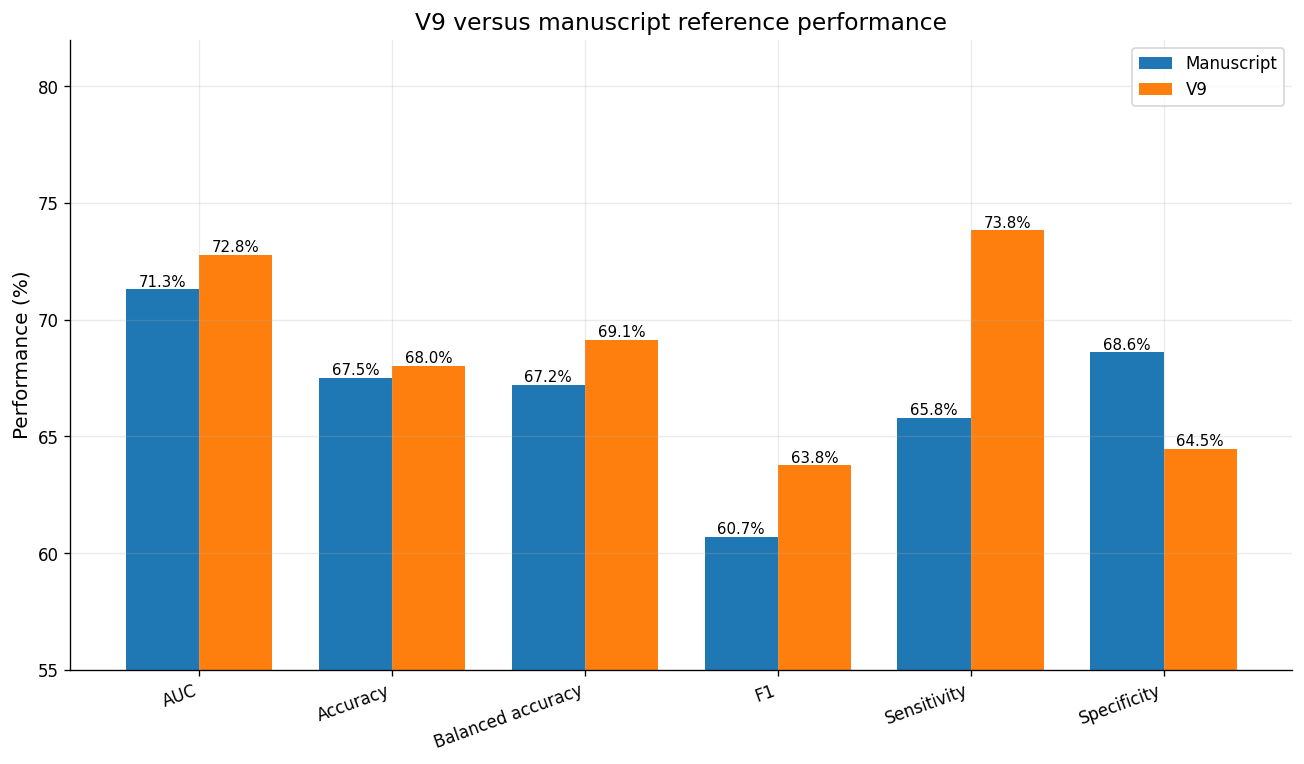

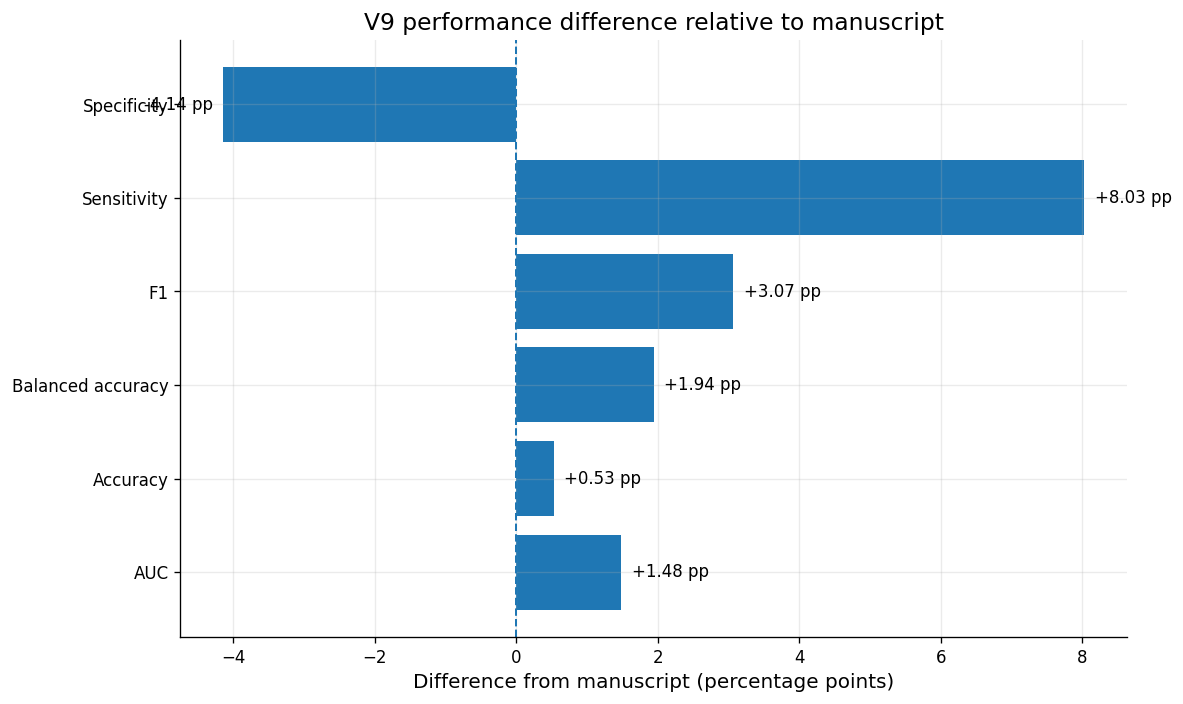

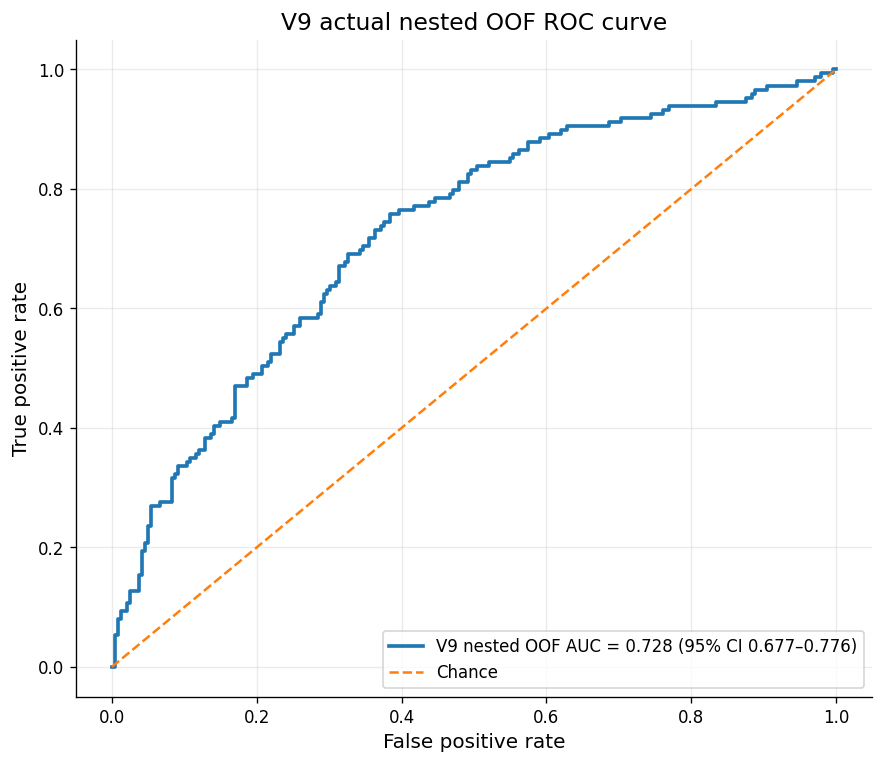

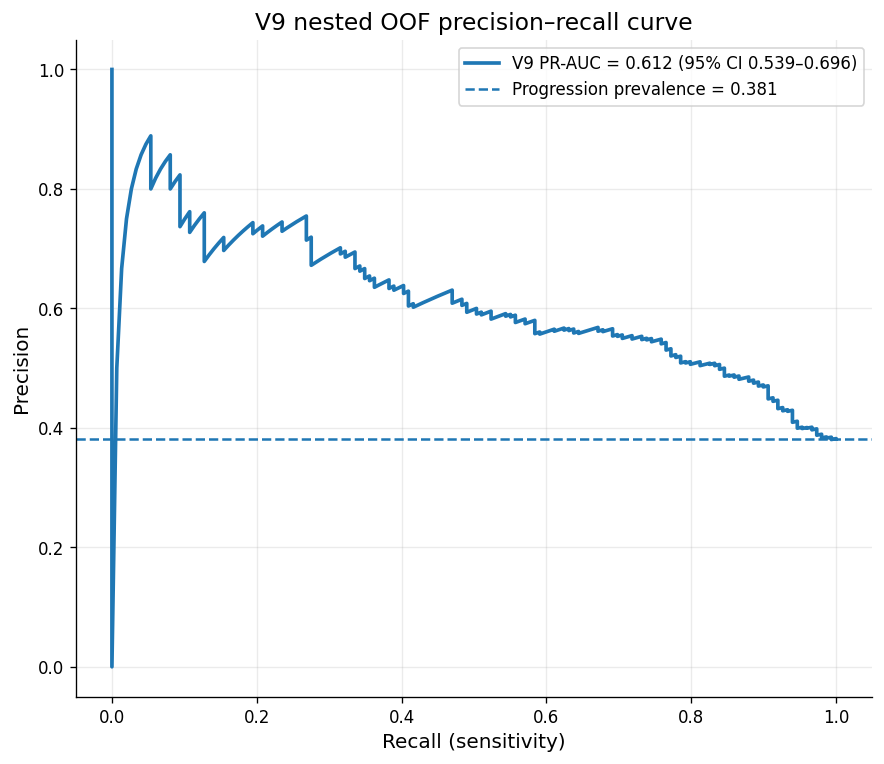

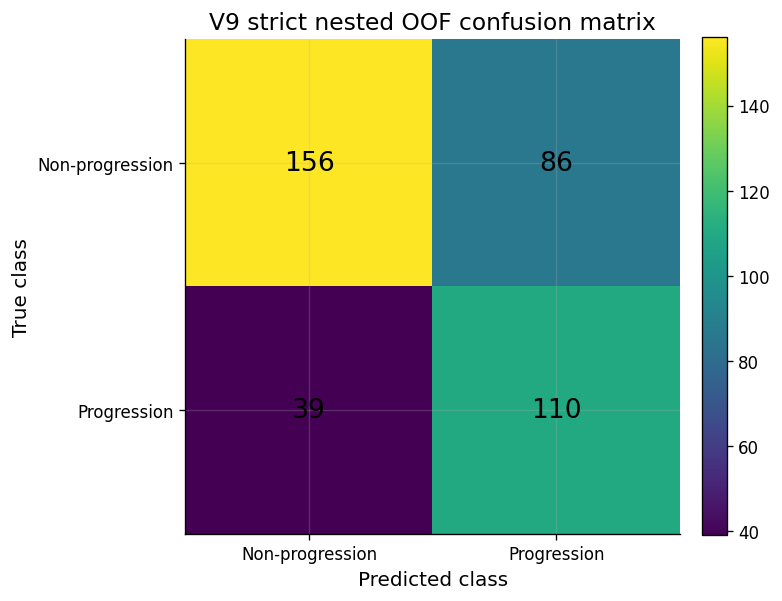

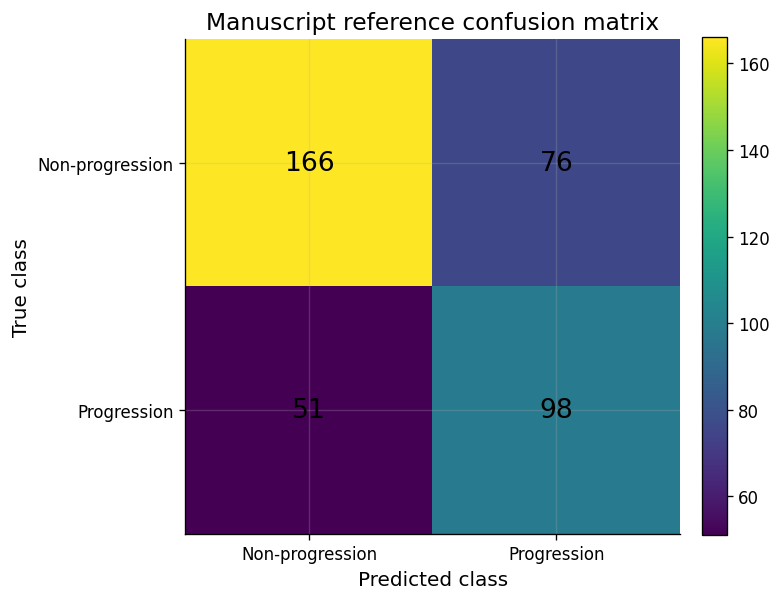

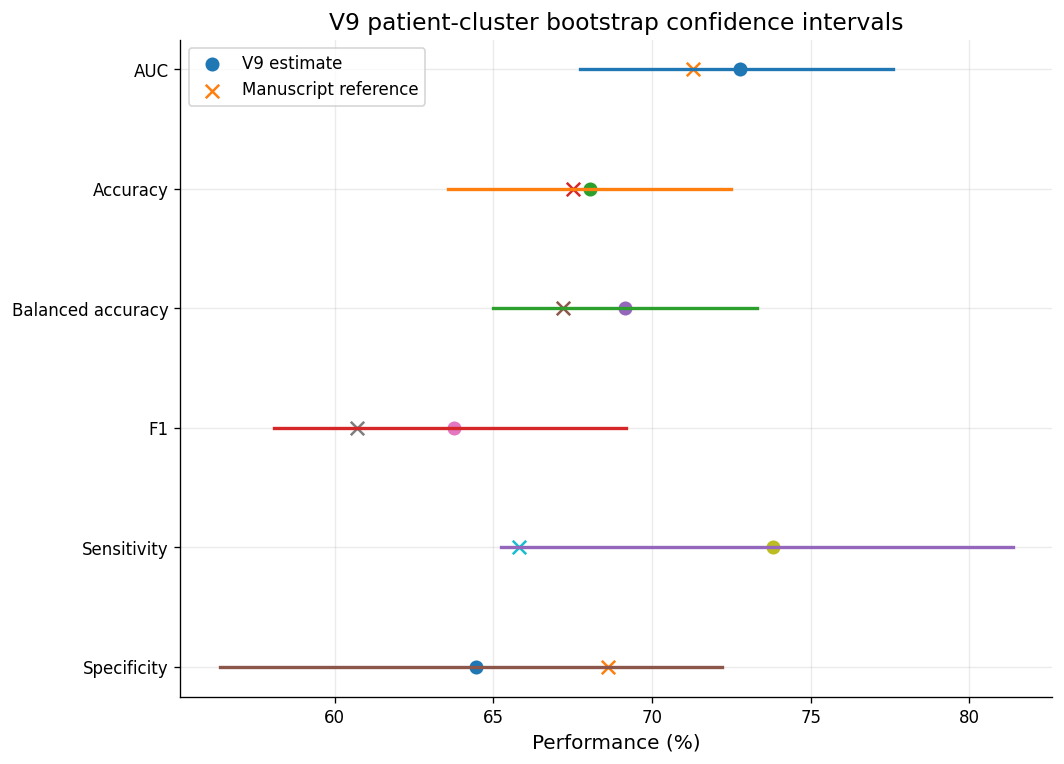

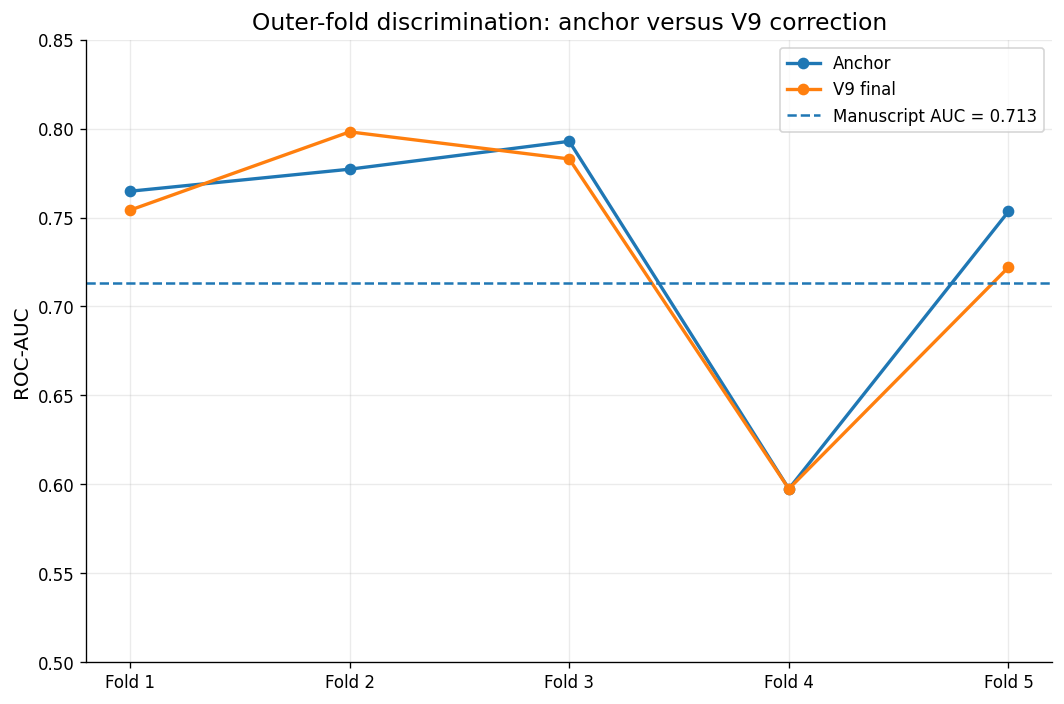

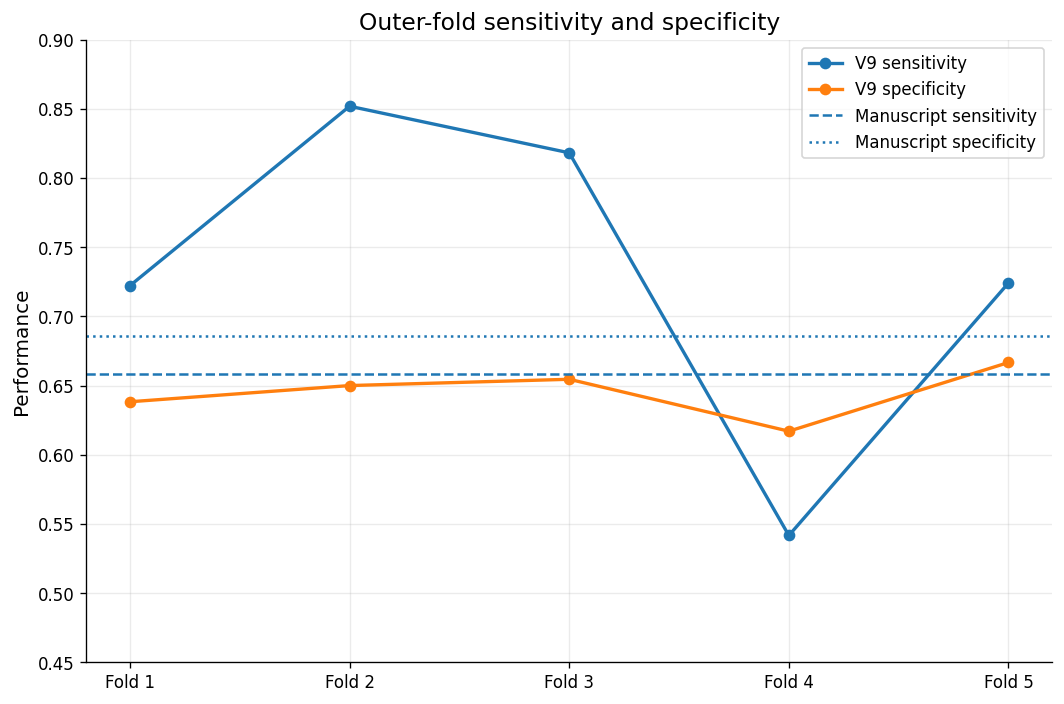

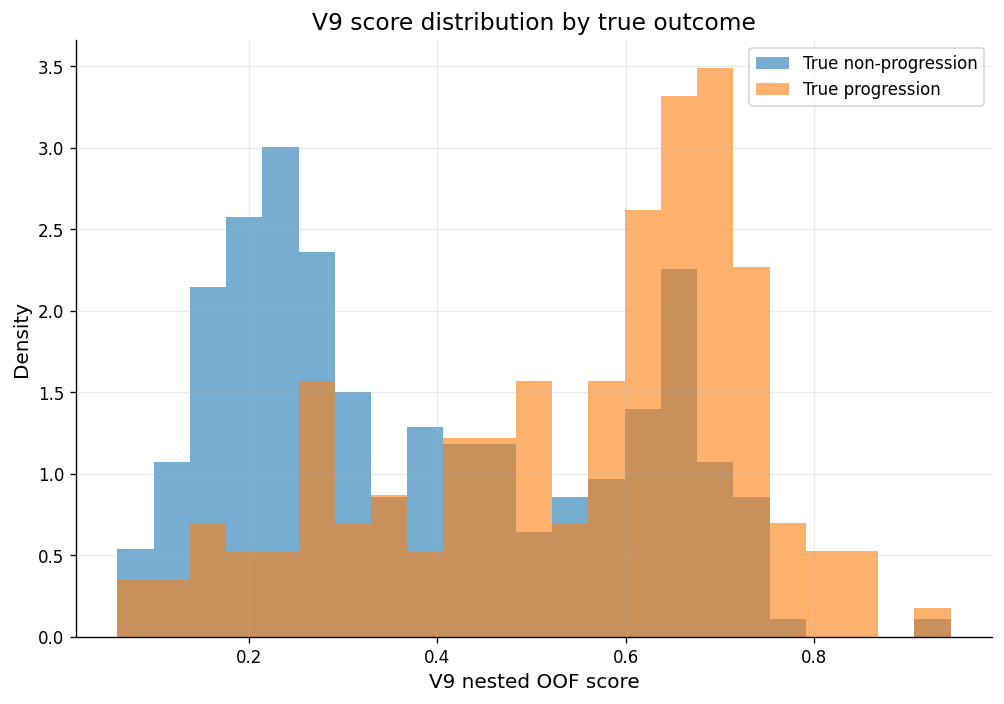

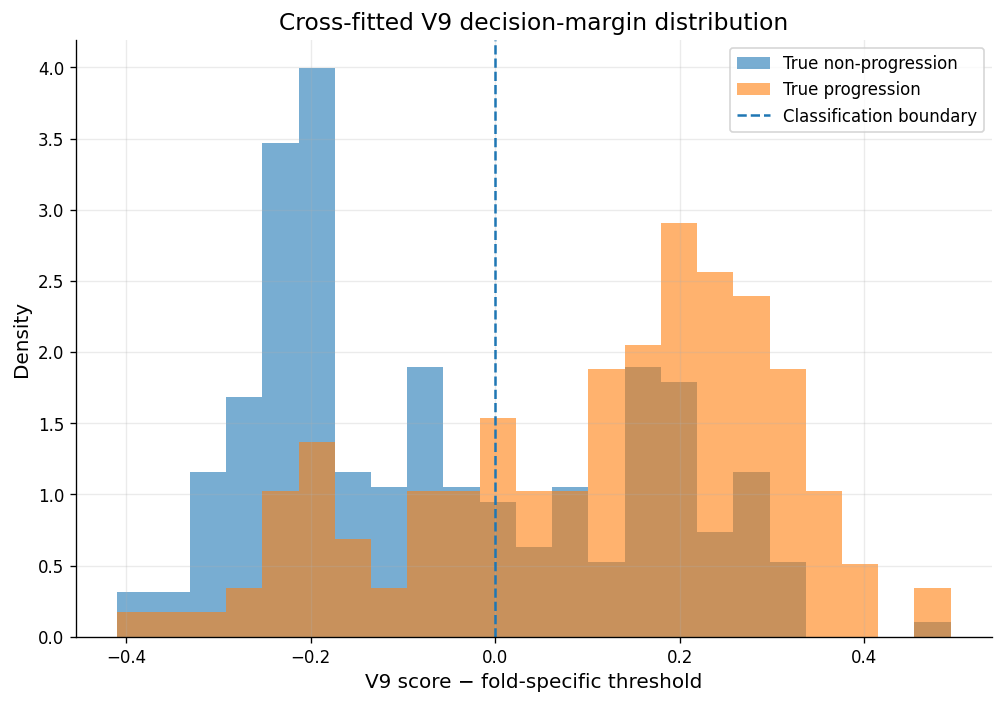

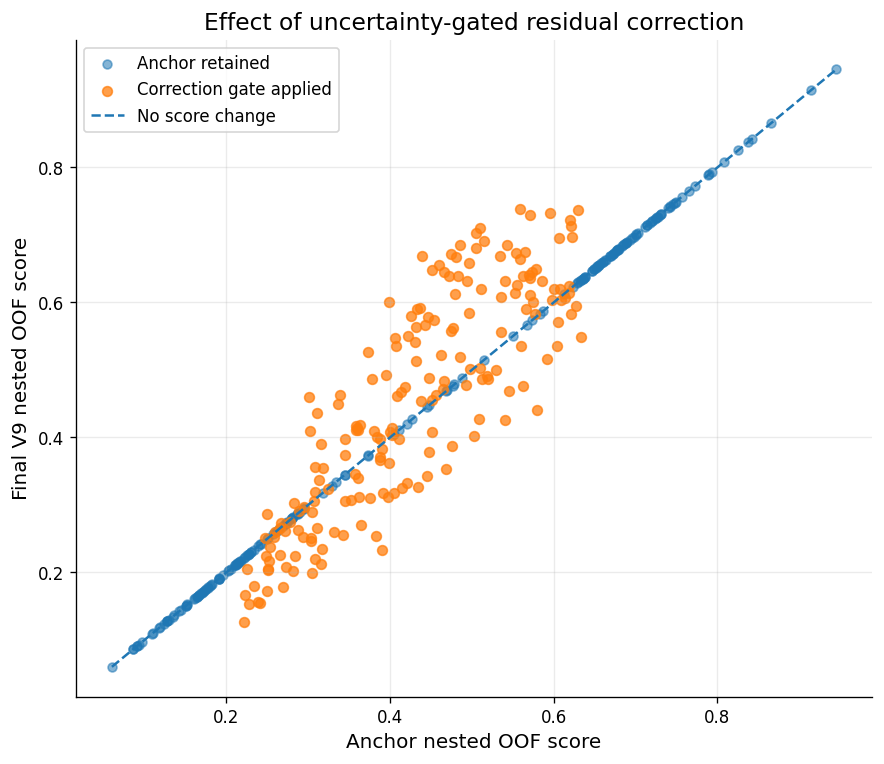

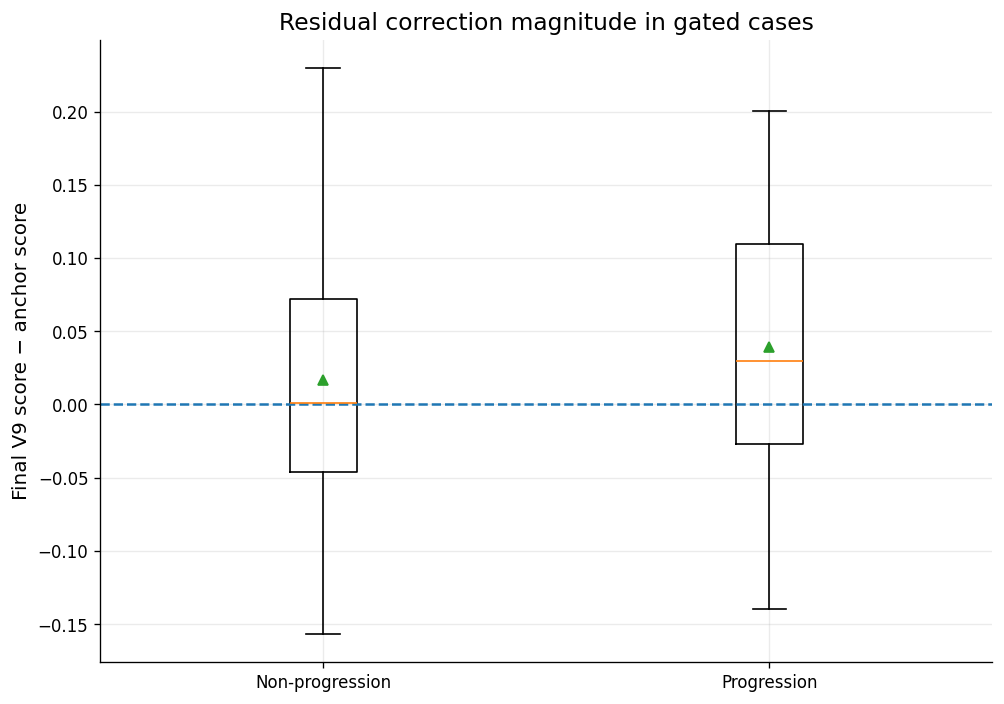

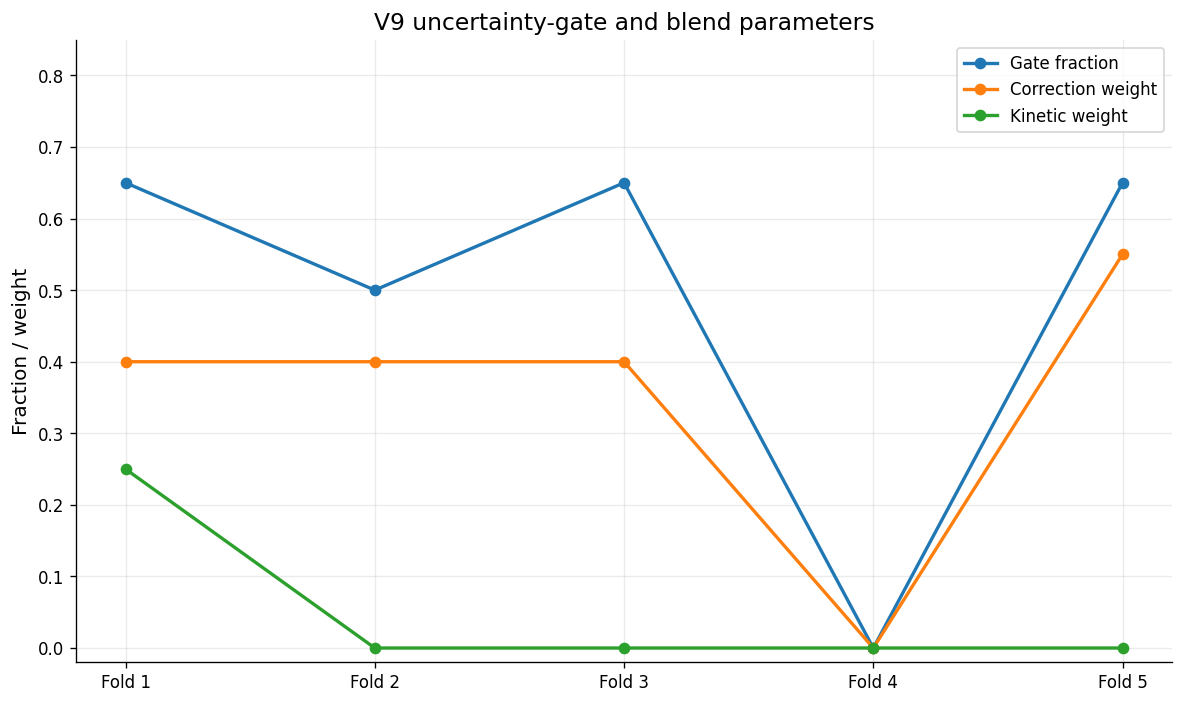

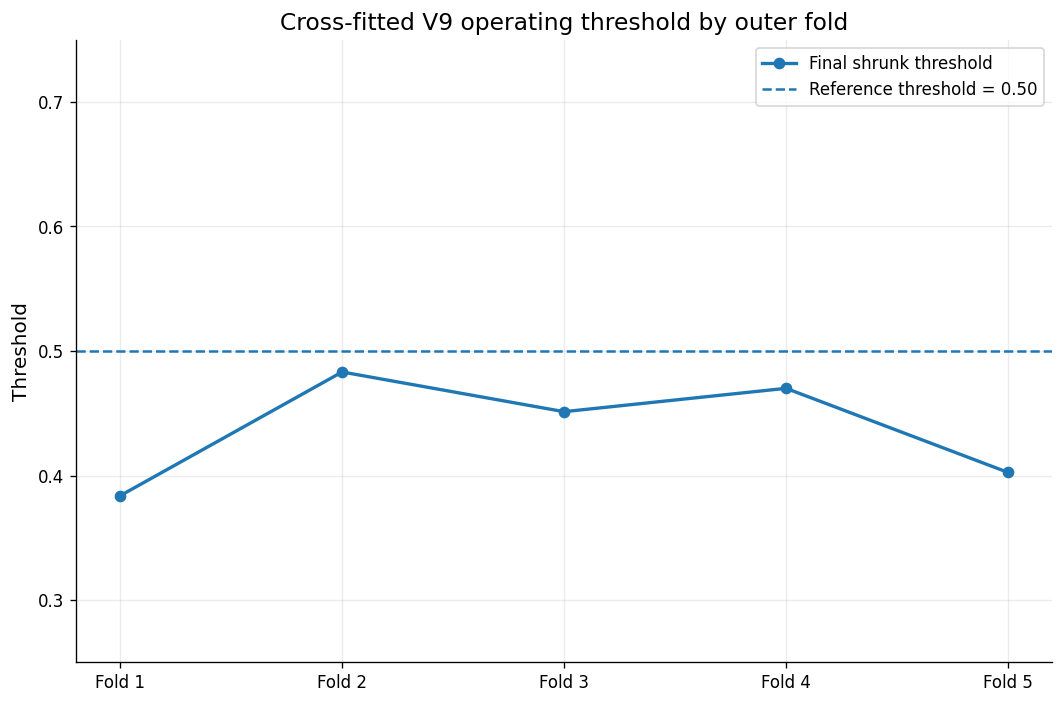

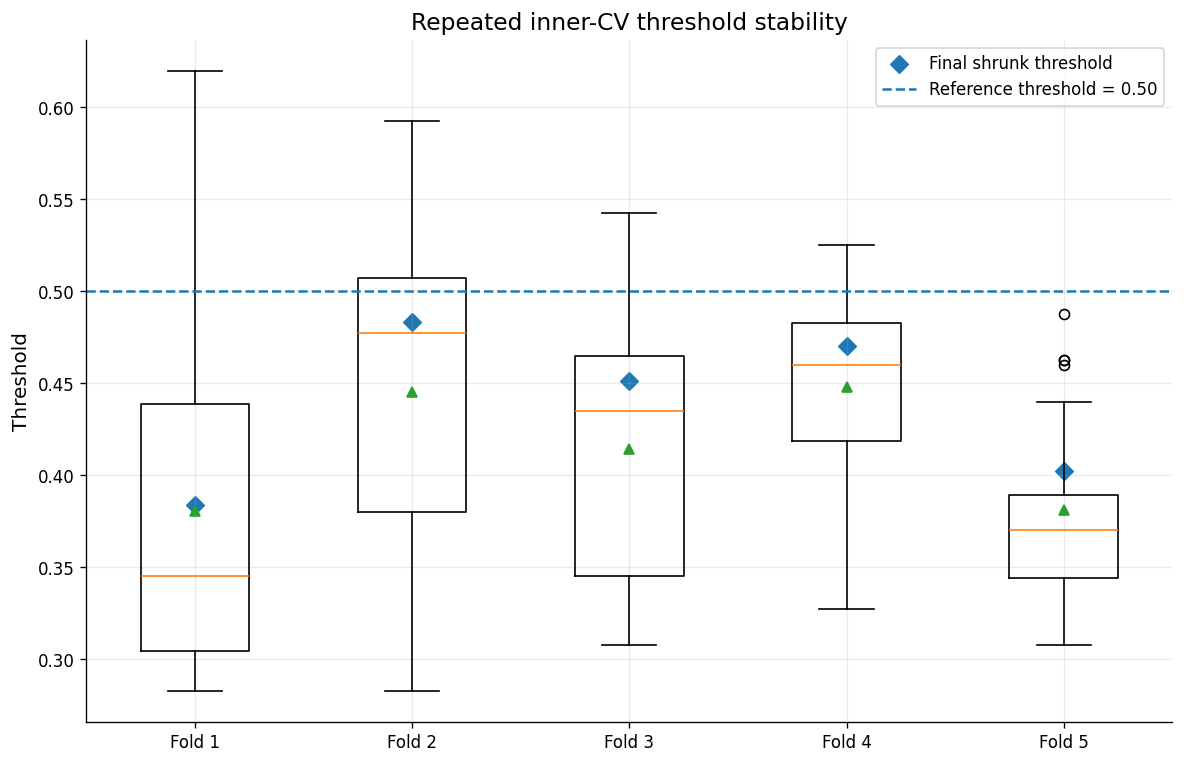

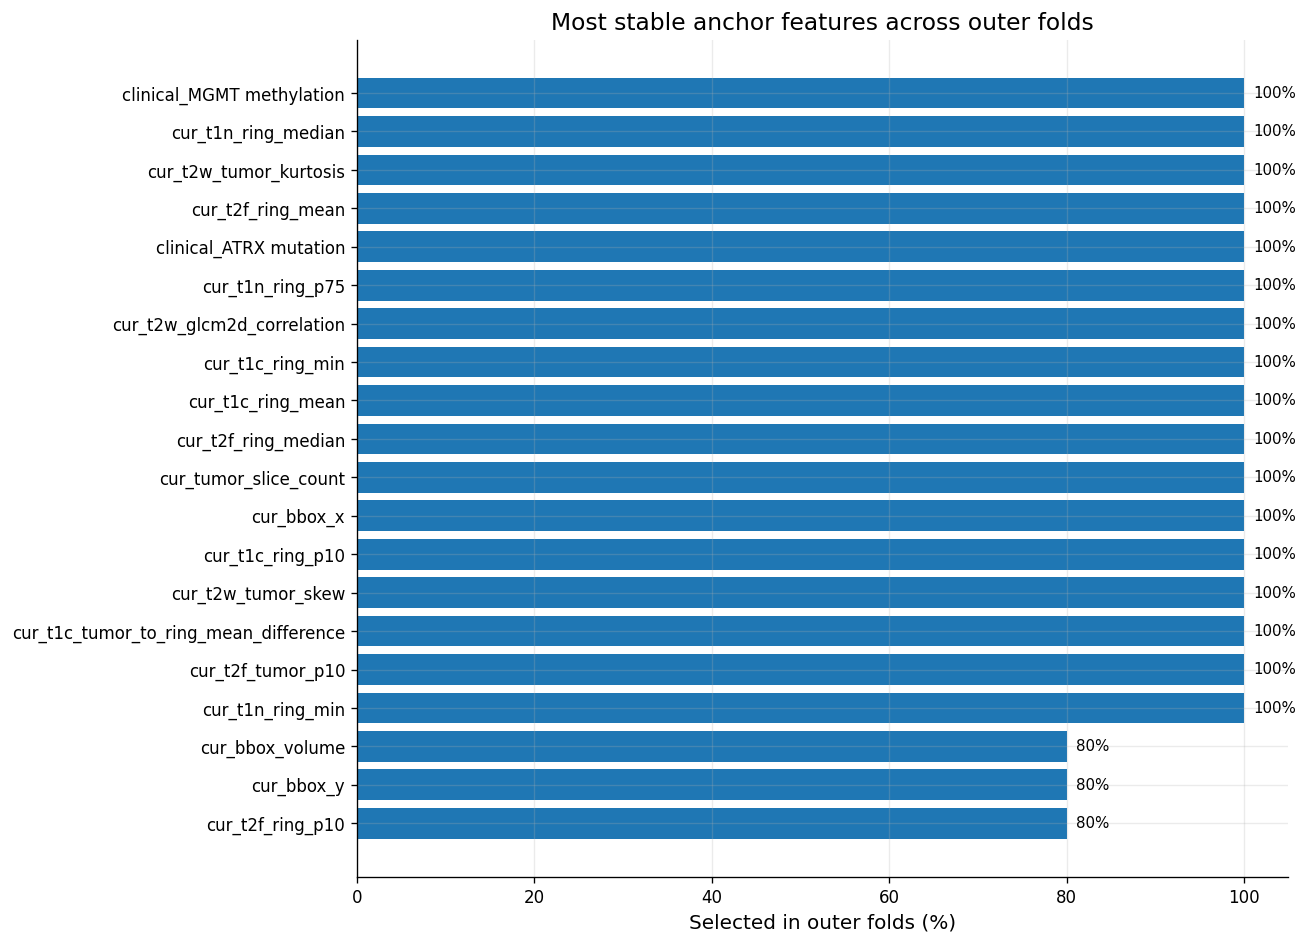

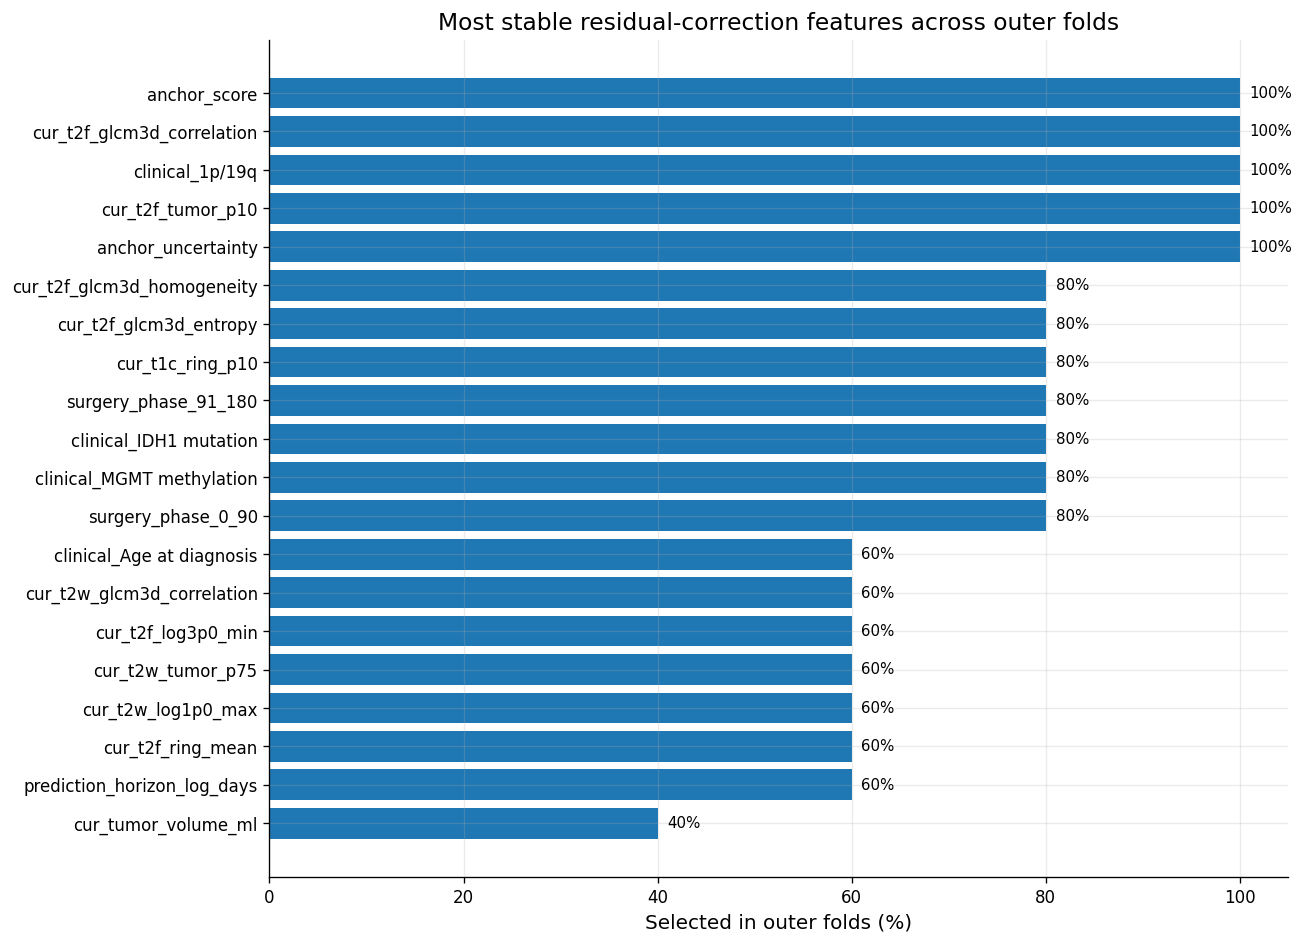

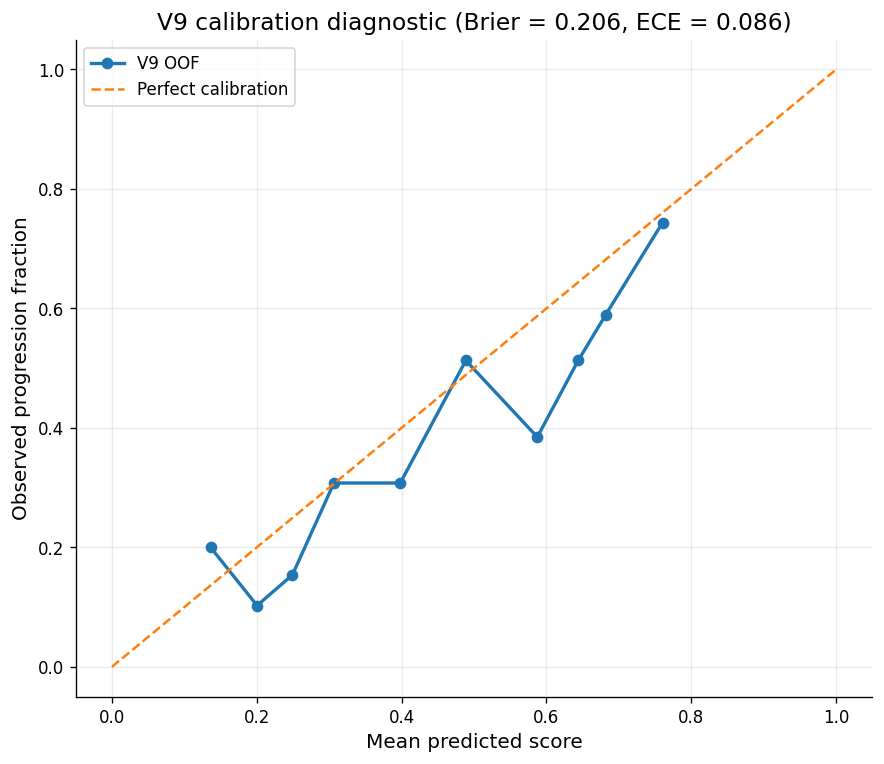

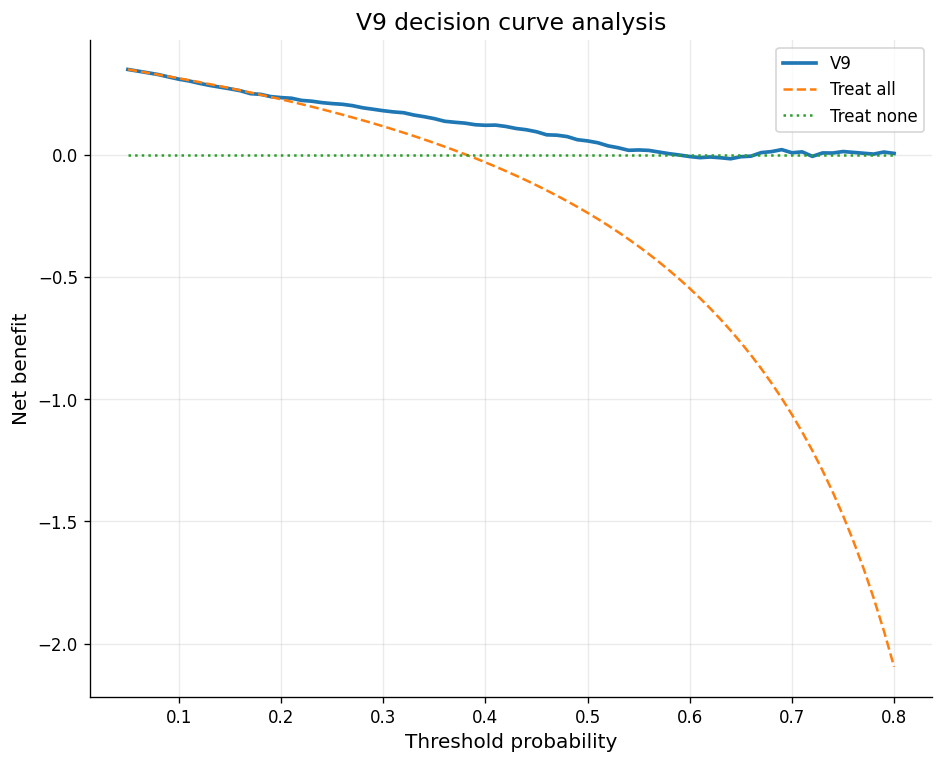

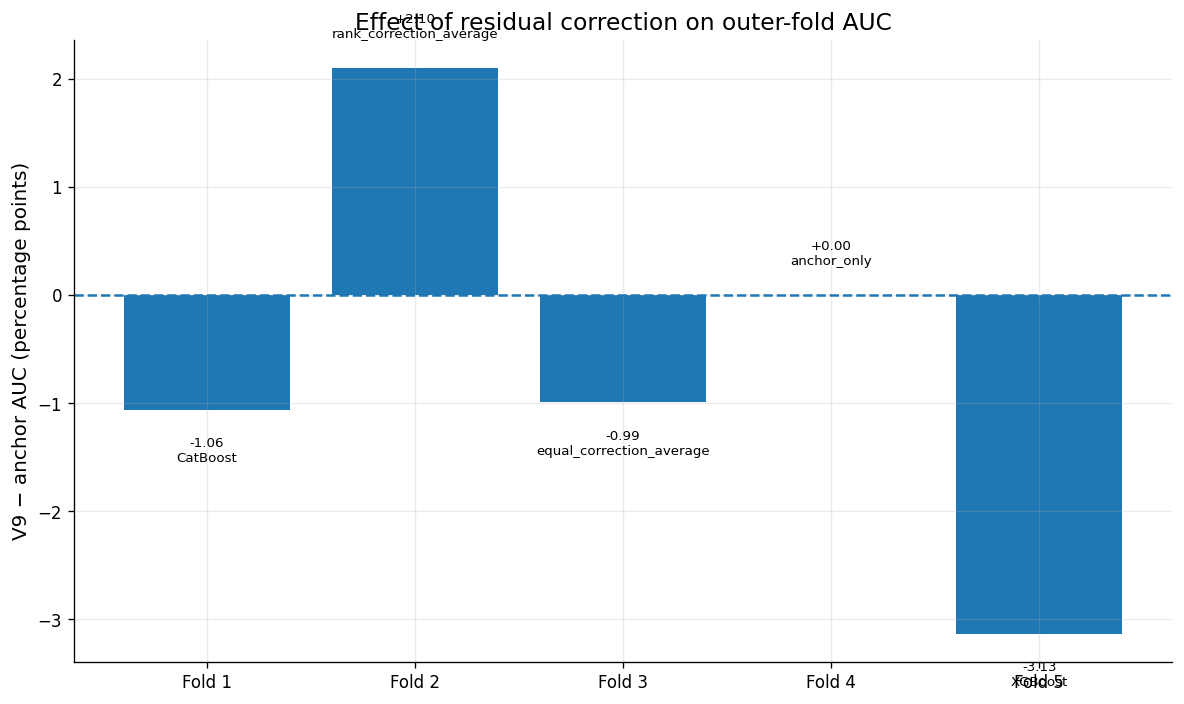

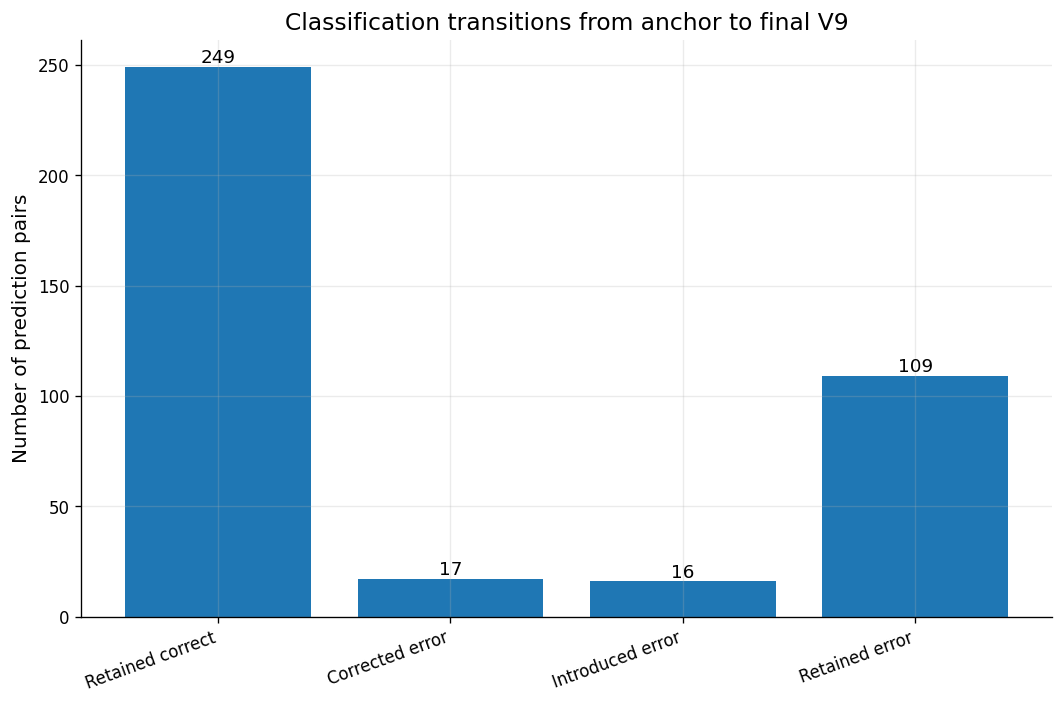

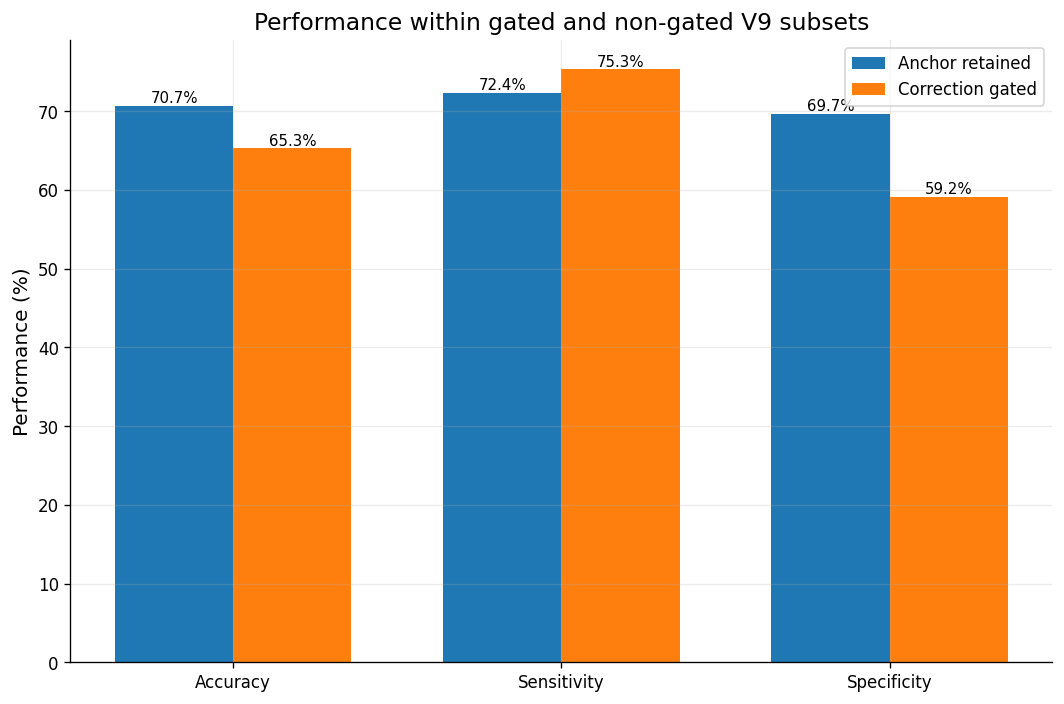

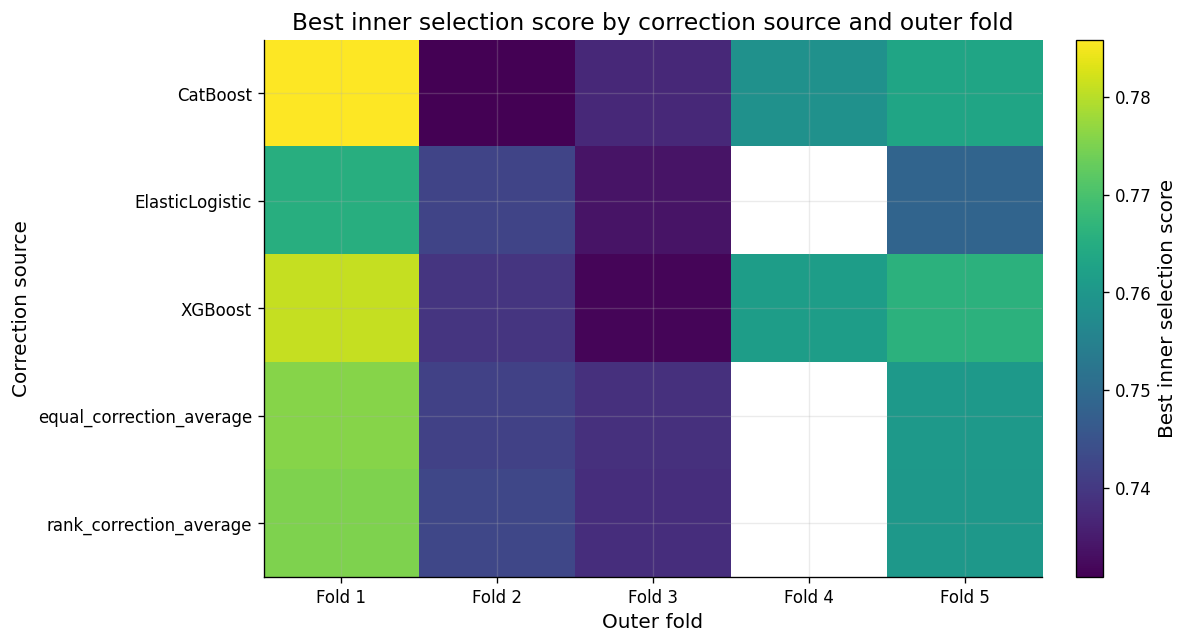


V9 VISUALIZATION COMPLETED
Figures generated: 24
Output directory: /kaggle/working/v9_exact_visualizations
ZIP bundle: /kaggle/working/v9_exact_manuscript_visualization_bundle.zip

Primary V9 result used for all figures:
AUC: 0.727800
PR-AUC: 0.612190
Accuracy: 0.680307
Balanced accuracy: 0.691442
F1: 0.637681
Sensitivity: 0.738255
Specificity: 0.644628
Confusion matrix: {'TN': 156, 'FP': 86, 'FN': 39, 'TP': 110}


In [ ]:
# ======================================================================================
# SINGLE-CELL KAGGLE VISUALIZATION PIPELINE FOR THE ATTACHED V9 RUN
# Exact schema: V9 Uncertainty-Gated Residual Correction + Patient-Level Bagging
# ======================================================================================
# Run this entire file in ONE Kaggle notebook cell AFTER the V9 pipeline has completed,
# or attach the saved V9 CSV outputs as a Kaggle input dataset.
#
# This code:
#   - reads only the V9 result files saved by the attached V9 pipeline;
#   - does NOT retrain, retune, recalibrate, or alter any V9 prediction;
#   - reconstructs all principal metrics from strict nested OOF predictions;
#   - generates manuscript-ready figures as 300-dpi PNG and vector PDF files;
#   - creates summary CSV tables, captions, README, and a ZIP bundle.
#
# Exact V9 files expected:
#   v9_uncertainty_gated_residual_nested_results.csv
#   v9_uncertainty_gated_residual_nested_oof_predictions.csv
#   v9_uncertainty_gated_residual_fold_details.csv
#   v9_uncertainty_gated_residual_feature_stability.csv
#   v9_uncertainty_gated_residual_gate_candidates.csv
#   v9_uncertainty_gated_residual_threshold_details.csv
#   v9_uncertainty_gated_residual_manuscript_ready_summary.csv
#   v9_uncertainty_gated_residual_calibration_table.csv
#   v9_uncertainty_gated_residual_decision_curve.csv
# ======================================================================================

import os
import math
import shutil
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    confusion_matrix,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    roc_curve,
    precision_recall_curve,
)
from sklearn.calibration import calibration_curve

# ======================================================================================
# 1. CONFIGURATION
# ======================================================================================
SEED = 42
N_BOOTSTRAP = int(os.environ.get("V9_VIS_BOOTSTRAP", "2000"))
PREFIX = "v9_uncertainty_gated_residual"

# Optional environment override for testing or custom storage.
PRIMARY_BASE_DIR = Path(os.environ.get("V9_RESULTS_DIR", "/kaggle/working"))
SEARCH_ROOTS = [PRIMARY_BASE_DIR, Path("/kaggle/working"), Path("/kaggle/input")]
SEARCH_ROOTS = list(dict.fromkeys([p for p in SEARCH_ROOTS if p.exists()]))

VIS_DIR = Path(os.environ.get(
    "V9_VIS_DIR",
    str(PRIMARY_BASE_DIR / "v9_exact_visualizations")
))
VIS_DIR.mkdir(parents=True, exist_ok=True)

MANUSCRIPT = {
    "AUC": 0.713,
    "Accuracy": 0.675,
    "Balanced_Accuracy": 0.672,
    "F1": 0.607,
    "Sensitivity": 0.658,
    "Specificity": 0.686,
}

MANUSCRIPT_CONFUSION = {
    "TN": 166,
    "FP": 76,
    "FN": 51,
    "TP": 98,
}

plt.rcParams.update({
    "figure.figsize": (8, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 11,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

print("=" * 100)
print("V9 EXACT RESULT VISUALIZATION PIPELINE")
print("=" * 100)
print("Search roots:")
for root in SEARCH_ROOTS:
    print("  ", root)
print("Output directory:", VIS_DIR)
print("Patient-cluster bootstrap resamples:", N_BOOTSTRAP)

# ======================================================================================
# 2. EXACT FILE DISCOVERY
# ======================================================================================
def resolve_file(suffix, required=True):
    filename = f"{PREFIX}_{suffix}"

    # Priority 1: exact path under the primary results directory.
    exact = PRIMARY_BASE_DIR / filename
    if exact.exists():
        return exact

    # Priority 2: exact filename anywhere under working/input roots.
    matches = []
    for root in SEARCH_ROOTS:
        if not root.exists():
            continue
        try:
            matches.extend(root.glob(f"**/{filename}"))
        except Exception:
            pass

    matches = [m for m in matches if m.is_file()]
    if matches:
        # Prefer /kaggle/working, then shortest path, then lexical order.
        matches = sorted(
            set(matches),
            key=lambda p: (
                0 if str(p).startswith("/kaggle/working") else 1,
                len(str(p)),
                str(p),
            ),
        )
        return matches[0]

    if required:
        raise FileNotFoundError(
            f"Required V9 output file was not found: {filename}\n"
            "Run the complete V9 pipeline first, or attach its saved CSV outputs as a Kaggle input dataset."
        )
    return None


RESULTS_PATH = resolve_file("nested_results.csv")
OOF_PATH = resolve_file("nested_oof_predictions.csv")
FOLD_PATH = resolve_file("fold_details.csv")
STABILITY_PATH = resolve_file("feature_stability.csv")
GATE_PATH = resolve_file("gate_candidates.csv", required=False)
THRESHOLD_PATH = resolve_file("threshold_details.csv", required=False)
SUMMARY_PATH = resolve_file("manuscript_ready_summary.csv", required=False)
CALIBRATION_PATH = resolve_file("calibration_table.csv", required=False)
DCA_PATH = resolve_file("decision_curve.csv", required=False)

print("\nDetected V9 files:")
for label, path in [
    ("Nested results", RESULTS_PATH),
    ("Nested OOF predictions", OOF_PATH),
    ("Outer-fold details", FOLD_PATH),
    ("Feature stability", STABILITY_PATH),
    ("Gate candidates", GATE_PATH),
    ("Threshold details", THRESHOLD_PATH),
    ("Summary", SUMMARY_PATH),
    ("Calibration", CALIBRATION_PATH),
    ("Decision curve", DCA_PATH),
]:
    print(f"  {label:24s}: {path}")

results_df = pd.read_csv(RESULTS_PATH)
oof_df = pd.read_csv(OOF_PATH)
fold_df = pd.read_csv(FOLD_PATH)
stability_df = pd.read_csv(STABILITY_PATH)
gate_df = pd.read_csv(GATE_PATH) if GATE_PATH is not None else pd.DataFrame()
threshold_df = pd.read_csv(THRESHOLD_PATH) if THRESHOLD_PATH is not None else pd.DataFrame()
summary_df = pd.read_csv(SUMMARY_PATH) if SUMMARY_PATH is not None else pd.DataFrame()

# ======================================================================================
# 3. EXACT V9 SCHEMA VALIDATION
# ======================================================================================
REQUIRED_OOF_COLUMNS = {
    "patient_id",
    "timepoint_current",
    "timepoint_next",
    "progression_like_25pct",
    "history_available",
    "prediction_horizon_days",
    "outer_fold",
    "anchor_score",
    "anchor_rank",
    "correction_score",
    "kinetic_score",
    "v9_score",
    "threshold",
    "prediction",
    "correction_gate_applied",
}

REQUIRED_FOLD_COLUMNS = {
    "outer_fold",
    "anchor_selected_features",
    "correction_selected_features",
    "anchor_ensemble",
    "correction_source",
    "gate_fraction",
    "correction_weight",
    "kinetic_weight",
    "final_threshold",
    "inner_anchor_auc",
    "inner_selected_auc",
    "outer_anchor_auc",
    "outer_final_auc",
    "outer_Accuracy",
    "outer_Balanced_Accuracy",
    "outer_F1",
    "outer_Sensitivity",
    "outer_Specificity",
}

REQUIRED_STABILITY_COLUMNS = {
    "feature",
    "selection_frequency",
    "mean_importance",
    "selected",
    "view",
    "outer_fold",
}


def validate_columns(frame, required, label):
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(
            f"{label} does not match the attached V9 schema. Missing columns: {missing}\n"
            f"Available columns: {list(frame.columns)}"
        )


validate_columns(oof_df, REQUIRED_OOF_COLUMNS, "V9 OOF prediction file")
validate_columns(fold_df, REQUIRED_FOLD_COLUMNS, "V9 fold-details file")
validate_columns(stability_df, REQUIRED_STABILITY_COLUMNS, "V9 feature-stability file")

if not gate_df.empty:
    expected_gate = {
        "source", "gate_fraction", "gate_cutoff", "correction_weight", "kinetic_weight",
        "threshold", "classification_utility", "selection_score", "pooled_auc",
        "fold_std", "min_fold_auc", "robust_score", "outer_fold"
    }
    missing_gate = sorted(expected_gate - set(gate_df.columns))
    if missing_gate:
        print("Warning: gate-candidate file is missing optional columns:", missing_gate)

if not threshold_df.empty:
    expected_threshold = {
        "repeat", "fold", "threshold", "utility", "Accuracy", "Balanced_Accuracy",
        "F1", "Sensitivity", "Specificity", "outer_fold", "stage"
    }
    missing_threshold = sorted(expected_threshold - set(threshold_df.columns))
    if missing_threshold:
        print("Warning: threshold-details file is missing optional columns:", missing_threshold)

print("\nLoaded table shapes:")
print("  Results          :", results_df.shape)
print("  OOF predictions  :", oof_df.shape)
print("  Fold details     :", fold_df.shape)
print("  Feature stability:", stability_df.shape)
print("  Gate candidates  :", gate_df.shape)
print("  Threshold details:", threshold_df.shape)

# ======================================================================================
# 4. CORE V9 DATA AND METRICS
# ======================================================================================
TARGET = "progression_like_25pct"
y = oof_df[TARGET].astype(int).to_numpy()
score = oof_df["v9_score"].astype(float).to_numpy()
anchor_score = oof_df["anchor_score"].astype(float).to_numpy()
anchor_rank = oof_df["anchor_rank"].astype(float).to_numpy()
correction_score = oof_df["correction_score"].astype(float).to_numpy()
kinetic_score = oof_df["kinetic_score"].astype(float).to_numpy()
prediction = oof_df["prediction"].astype(int).to_numpy()
groups = oof_df["patient_id"].astype(str).to_numpy()
folds = oof_df["outer_fold"].astype(int).to_numpy()
gate = oof_df["correction_gate_applied"].fillna(0).astype(int).to_numpy()
thresholds = oof_df["threshold"].astype(float).to_numpy()
history = oof_df["history_available"].fillna(0).astype(int).to_numpy()


def expected_calibration_error(y_true, probability, n_bins=10):
    probability = np.asarray(probability, dtype=float)
    edges = np.unique(np.quantile(probability, np.linspace(0, 1, n_bins + 1)))
    if len(edges) < 2:
        return 0.0
    total = 0.0
    for i in range(len(edges) - 1):
        mask = (probability >= edges[i]) & (
            (probability <= edges[i + 1]) if i == len(edges) - 2 else (probability < edges[i + 1])
        )
        if mask.sum() == 0:
            continue
        total += mask.mean() * abs(y_true[mask].mean() - probability[mask].mean())
    return float(total)


def compute_metrics(y_true, probability, pred):
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    specificity = tn / max(tn + fp, 1)
    return {
        "AUC": roc_auc_score(y_true, probability) if len(np.unique(y_true)) == 2 else np.nan,
        "PR_AUC": average_precision_score(y_true, probability) if len(np.unique(y_true)) == 2 else np.nan,
        "Accuracy": accuracy_score(y_true, pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, pred),
        "F1": f1_score(y_true, pred, zero_division=0),
        "Precision": precision_score(y_true, pred, zero_division=0),
        "Sensitivity": recall_score(y_true, pred, zero_division=0),
        "Specificity": specificity,
        "MCC": matthews_corrcoef(y_true, pred),
        "Brier": brier_score_loss(y_true, np.clip(probability, 0, 1)),
        "LogLoss": log_loss(y_true, np.clip(probability, 1e-6, 1 - 1e-6), labels=[0, 1]),
        "ECE_10": expected_calibration_error(y_true, np.clip(probability, 0, 1), 10),
        "TN": int(tn),
        "FP": int(fp),
        "FN": int(fn),
        "TP": int(tp),
    }


V9 = compute_metrics(y, score, prediction)

# The attached V9 does not save a separate anchor operating threshold. For transition
# analysis only, use the same frozen fold-specific threshold applied to V9. This is not
# presented as a primary anchor classification benchmark.
anchor_prediction_at_v9_threshold = (anchor_score >= thresholds).astype(int)
ANCHOR_AT_V9_THRESHOLD = compute_metrics(y, anchor_score, anchor_prediction_at_v9_threshold)

comparison_metrics = [
    "AUC",
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "Sensitivity",
    "Specificity",
]

comparison_table = pd.DataFrame({
    "Metric": comparison_metrics,
    "Manuscript": [MANUSCRIPT[m] for m in comparison_metrics],
    "V9": [V9[m] for m in comparison_metrics],
})
comparison_table["Difference"] = comparison_table["V9"] - comparison_table["Manuscript"]
comparison_table["Difference_pp"] = comparison_table["Difference"] * 100.0
comparison_table["V9_Better"] = comparison_table["Difference"] > 0
comparison_table.to_csv(VIS_DIR / "table01_v9_vs_manuscript.csv", index=False)

print("\nPrimary metrics recomputed from exact V9 nested OOF predictions:")
for metric in [
    "AUC", "PR_AUC", "Accuracy", "Balanced_Accuracy", "F1", "Precision",
    "Sensitivity", "Specificity", "MCC", "Brier", "LogLoss", "ECE_10"
]:
    print(f"  {metric:22s}: {V9[metric]:.6f}")
print("  Confusion matrix       :", {k: V9[k] for k in ["TN", "FP", "FN", "TP"]})
print("  Pairs / patients       :", len(oof_df), "/", oof_df["patient_id"].nunique())

# Cross-check against the one-row V9 nested results table.
if len(results_df) == 1:
    for metric in ["AUC", "PR_AUC", "Accuracy", "Balanced_Accuracy", "F1", "Sensitivity", "Specificity"]:
        if metric in results_df.columns:
            saved_value = float(results_df.iloc[0][metric])
            if abs(saved_value - V9[metric]) > 1e-6:
                print(f"Warning: recomputed {metric} differs from saved results by {V9[metric] - saved_value:+.8f}")

# ======================================================================================
# 5. PATIENT-CLUSTER BOOTSTRAP CONFIDENCE INTERVALS
# ======================================================================================
def patient_cluster_bootstrap(oof, n_bootstrap=2000, seed_value=42):
    rng = np.random.default_rng(seed_value)
    patient_values = oof["patient_id"].astype(str).to_numpy()
    patients = np.unique(patient_values)
    patient_indices = {
        patient: np.where(patient_values == patient)[0]
        for patient in patients
    }

    metric_names = [
        "AUC", "PR_AUC", "Accuracy", "Balanced_Accuracy",
        "F1", "Sensitivity", "Specificity"
    ]
    values = {name: [] for name in metric_names}

    for _ in range(n_bootstrap):
        sampled_patients = rng.choice(patients, size=len(patients), replace=True)
        idx = np.concatenate([patient_indices[p] for p in sampled_patients])
        y_b = y[idx]
        if len(np.unique(y_b)) < 2:
            continue
        score_b = score[idx]
        pred_b = prediction[idx]
        metrics_b = compute_metrics(y_b, score_b, pred_b)
        for name in metric_names:
            value = metrics_b[name]
            if np.isfinite(value):
                values[name].append(value)

    rows = []
    for name in metric_names:
        arr = np.asarray(values[name], dtype=float)
        rows.append({
            "Metric": name,
            "Estimate": V9[name],
            "CI_2.5": float(np.percentile(arr, 2.5)) if len(arr) else np.nan,
            "CI_97.5": float(np.percentile(arr, 97.5)) if len(arr) else np.nan,
            "Valid_Resamples": int(len(arr)),
        })
    return pd.DataFrame(rows)


bootstrap_ci_df = patient_cluster_bootstrap(oof_df, N_BOOTSTRAP, SEED)
bootstrap_ci_df.to_csv(VIS_DIR / "table02_patient_cluster_bootstrap_cis.csv", index=False)

# ======================================================================================
# 6. FIGURE HELPERS
# ======================================================================================
figure_catalog = []


def save_current_figure(stem, caption):
    png_path = VIS_DIR / f"{stem}.png"
    pdf_path = VIS_DIR / f"{stem}.pdf"
    plt.tight_layout()
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()
    plt.close()
    figure_catalog.append({
        "Figure": stem,
        "PNG": str(png_path),
        "PDF": str(pdf_path),
        "Caption": caption,
    })


def add_bar_labels(ax, bars, decimals=1, suffix=""):
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value,
            f"{value:.{decimals}f}{suffix}",
            ha="center",
            va="bottom",
            fontsize=9,
        )


def clean_feature_name(name, max_length=70):
    text = str(name)
    for prefix in ["numeric__", "categorical__", "num__", "cat__"]:
        text = text.replace(prefix, "")
    replacements = {
        "current_": "cur_",
        "history_delta_": "delta_",
        "history_slope30_": "slope30_",
        "kinetic_": "kin_",
        "anchor_meta_": "anchor_",
    }
    for old, new in replacements.items():
        text = text.replace(old, new)
    if len(text) > max_length:
        text = text[:max_length - 1] + "…"
    return text

# ======================================================================================
# 7. FIGURE 1 — V9 VS MANUSCRIPT PERFORMANCE
# ======================================================================================
metrics_display = [
    ("AUC", "AUC"),
    ("Accuracy", "Accuracy"),
    ("Balanced_Accuracy", "Balanced accuracy"),
    ("F1", "F1"),
    ("Sensitivity", "Sensitivity"),
    ("Specificity", "Specificity"),
]
labels = [display for _, display in metrics_display]
manuscript_values = np.array([MANUSCRIPT[key] for key, _ in metrics_display]) * 100
v9_values = np.array([V9[key] for key, _ in metrics_display]) * 100
x = np.arange(len(labels))
width = 0.38

plt.figure(figsize=(11, 6.5))
ax = plt.gca()
bars1 = ax.bar(x - width / 2, manuscript_values, width, label="Manuscript")
bars2 = ax.bar(x + width / 2, v9_values, width, label="V9")
ax.set_ylabel("Performance (%)")
ax.set_title("V9 versus manuscript reference performance")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=20, ha="right")
ax.set_ylim(55, max(82, float(max(v9_values.max(), manuscript_values.max()) + 5)))
ax.legend()
add_bar_labels(ax, bars1, 1, "%")
add_bar_labels(ax, bars2, 1, "%")
save_current_figure(
    "fig01_v9_vs_manuscript_performance",
    "Comparison of strict nested OOF V9 performance with the manuscript reference across six principal metrics.",
)

# ======================================================================================
# 8. FIGURE 2 — DIFFERENCE FROM MANUSCRIPT
# ======================================================================================
differences_pp = v9_values - manuscript_values
plt.figure(figsize=(10, 6))
ax = plt.gca()
bars = ax.barh(labels, differences_pp)
ax.axvline(0, linestyle="--", linewidth=1.2)
ax.set_xlabel("Difference from manuscript (percentage points)")
ax.set_title("V9 performance difference relative to manuscript")
for bar, value in zip(bars, differences_pp):
    ax.text(
        value + (0.15 if value >= 0 else -0.15),
        bar.get_y() + bar.get_height() / 2,
        f"{value:+.2f} pp",
        va="center",
        ha="left" if value >= 0 else "right",
        fontsize=10,
    )
save_current_figure(
    "fig02_metric_difference_from_manuscript",
    "Absolute percentage-point difference between V9 and the manuscript reference; positive values favor V9.",
)

# ======================================================================================
# 9. FIGURE 3 — ACTUAL NESTED OOF ROC CURVE
# ======================================================================================
fpr, tpr, _ = roc_curve(y, score)
auc_row = bootstrap_ci_df.loc[bootstrap_ci_df["Metric"] == "AUC"].iloc[0]
plt.figure(figsize=(7.5, 6.5))
plt.plot(
    fpr,
    tpr,
    linewidth=2.2,
    label=(
        f"V9 nested OOF AUC = {V9['AUC']:.3f} "
        f"(95% CI {auc_row['CI_2.5']:.3f}–{auc_row['CI_97.5']:.3f})"
    ),
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("V9 actual nested OOF ROC curve")
plt.legend(loc="lower right")
save_current_figure(
    "fig03_v9_nested_oof_roc_curve",
    "Receiver operating characteristic curve from actual strict nested OOF V9 predictions with a patient-cluster bootstrap AUC confidence interval.",
)

# ======================================================================================
# 10. FIGURE 4 — ACTUAL NESTED OOF PRECISION–RECALL CURVE
# ======================================================================================
precision_curve, recall_curve, _ = precision_recall_curve(y, score)
pr_row = bootstrap_ci_df.loc[bootstrap_ci_df["Metric"] == "PR_AUC"].iloc[0]
prevalence = y.mean()
plt.figure(figsize=(7.5, 6.5))
plt.plot(
    recall_curve,
    precision_curve,
    linewidth=2.2,
    label=(
        f"V9 PR-AUC = {V9['PR_AUC']:.3f} "
        f"(95% CI {pr_row['CI_2.5']:.3f}–{pr_row['CI_97.5']:.3f})"
    ),
)
plt.axhline(prevalence, linestyle="--", label=f"Progression prevalence = {prevalence:.3f}")
plt.xlabel("Recall (sensitivity)")
plt.ylabel("Precision")
plt.title("V9 nested OOF precision–recall curve")
plt.legend(loc="best")
save_current_figure(
    "fig04_v9_nested_oof_precision_recall_curve",
    "Precision–recall curve from strict nested OOF V9 predictions with cohort progression prevalence shown as the baseline.",
)

# ======================================================================================
# 11. FIGURES 5–6 — V9 AND MANUSCRIPT CONFUSION MATRICES
# ======================================================================================
def plot_confusion_matrix_counts(matrix, title, stem, caption):
    plt.figure(figsize=(6.5, 5.8))
    ax = plt.gca()
    image = ax.imshow(matrix)
    plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["Non-progression", "Progression"])
    ax.set_yticklabels(["Non-progression", "Progression"])
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(int(matrix[i, j])), ha="center", va="center", fontsize=16)
    save_current_figure(stem, caption)


v9_cm = np.array([[V9["TN"], V9["FP"]], [V9["FN"], V9["TP"]]])
manuscript_cm = np.array([
    [MANUSCRIPT_CONFUSION["TN"], MANUSCRIPT_CONFUSION["FP"]],
    [MANUSCRIPT_CONFUSION["FN"], MANUSCRIPT_CONFUSION["TP"]],
])

plot_confusion_matrix_counts(
    v9_cm,
    "V9 strict nested OOF confusion matrix",
    "fig05_v9_confusion_matrix",
    f"V9 strict nested OOF confusion matrix: TN={V9['TN']}, FP={V9['FP']}, FN={V9['FN']}, TP={V9['TP']}.",
)
plot_confusion_matrix_counts(
    manuscript_cm,
    "Manuscript reference confusion matrix",
    "fig06_manuscript_confusion_matrix",
    "Reference confusion matrix reported for the manuscript model: TN=166, FP=76, FN=51, TP=98.",
)

# ======================================================================================
# 12. FIGURE 7 — PATIENT-CLUSTER BOOTSTRAP CI FOREST PLOT
# ======================================================================================
forest_metrics = ["AUC", "Accuracy", "Balanced_Accuracy", "F1", "Sensitivity", "Specificity"]
forest = bootstrap_ci_df.set_index("Metric").loc[forest_metrics].reset_index()
forest["Manuscript"] = forest["Metric"].map(MANUSCRIPT)
y_pos = np.arange(len(forest_metrics))

plt.figure(figsize=(9, 6.5))
ax = plt.gca()
for i, row in forest.iterrows():
    ax.plot([row["CI_2.5"] * 100, row["CI_97.5"] * 100], [i, i], linewidth=2)
    ax.scatter(row["Estimate"] * 100, i, s=55, label="V9 estimate" if i == 0 else None)
    ax.scatter(row["Manuscript"] * 100, i, marker="x", s=65, label="Manuscript reference" if i == 0 else None)
ax.set_yticks(y_pos)
ax.set_yticklabels(["Balanced accuracy" if m == "Balanced_Accuracy" else m for m in forest_metrics])
ax.set_xlabel("Performance (%)")
ax.set_title("V9 patient-cluster bootstrap confidence intervals")
ax.invert_yaxis()
ax.legend(loc="best")
save_current_figure(
    "fig07_v9_bootstrap_ci_forest",
    "Patient-cluster bootstrap 95% confidence intervals for V9 performance, with manuscript point estimates shown as reference markers.",
)

# ======================================================================================
# 13. FIGURE 8 — OUTER-FOLD AUC: ANCHOR VS FINAL V9
# ======================================================================================
fold_df = fold_df.sort_values("outer_fold").reset_index(drop=True)
fold_x = np.arange(len(fold_df))
plt.figure(figsize=(9, 6))
plt.plot(fold_x, fold_df["outer_anchor_auc"], marker="o", linewidth=2, label="Anchor")
plt.plot(fold_x, fold_df["outer_final_auc"], marker="o", linewidth=2, label="V9 final")
plt.axhline(MANUSCRIPT["AUC"], linestyle="--", label=f"Manuscript AUC = {MANUSCRIPT['AUC']:.3f}")
plt.xticks(fold_x, [f"Fold {int(v)}" for v in fold_df["outer_fold"]])
plt.ylabel("ROC-AUC")
plt.ylim(0.50, max(0.85, float(fold_df[["outer_anchor_auc", "outer_final_auc"]].max().max() + 0.04)))
plt.title("Outer-fold discrimination: anchor versus V9 correction")
plt.legend(loc="best")
save_current_figure(
    "fig08_fold_auc_anchor_vs_v9",
    "Outer-fold ROC-AUC comparison showing where uncertainty-gated residual correction improved or reduced anchor discrimination.",
)

# ======================================================================================
# 14. FIGURE 9 — OUTER-FOLD SENSITIVITY AND SPECIFICITY
# ======================================================================================
plt.figure(figsize=(9, 6))
plt.plot(fold_x, fold_df["outer_Sensitivity"], marker="o", linewidth=2, label="V9 sensitivity")
plt.plot(fold_x, fold_df["outer_Specificity"], marker="o", linewidth=2, label="V9 specificity")
plt.axhline(MANUSCRIPT["Sensitivity"], linestyle="--", label="Manuscript sensitivity")
plt.axhline(MANUSCRIPT["Specificity"], linestyle=":", label="Manuscript specificity")
plt.xticks(fold_x, [f"Fold {int(v)}" for v in fold_df["outer_fold"]])
plt.ylabel("Performance")
plt.ylim(0.45, 0.90)
plt.title("Outer-fold sensitivity and specificity")
plt.legend(loc="best")
save_current_figure(
    "fig09_fold_sensitivity_specificity",
    "Outer-fold sensitivity and specificity for V9 compared with manuscript reference levels.",
)

# ======================================================================================
# 15. FIGURE 10 — V9 SCORE DISTRIBUTION BY TRUE CLASS
# ======================================================================================
plt.figure(figsize=(8.5, 6))
score_min = float(np.nanmin(score))
score_max = float(np.nanmax(score))
if score_max <= score_min:
    score_max = score_min + 1.0
bins = np.linspace(score_min, score_max, 24)
plt.hist(score[y == 0], bins=bins, alpha=0.60, density=True, label="True non-progression")
plt.hist(score[y == 1], bins=bins, alpha=0.60, density=True, label="True progression")
plt.xlabel("V9 nested OOF score")
plt.ylabel("Density")
plt.title("V9 score distribution by true outcome")
plt.legend(loc="best")
save_current_figure(
    "fig10_v9_score_distribution_by_class",
    "Distribution of strict nested OOF V9 scores for true non-progression and progression cases.",
)

# ======================================================================================
# 16. FIGURE 11 — CROSS-FITTED DECISION MARGIN DISTRIBUTION
# ======================================================================================
decision_margin = score - thresholds
plt.figure(figsize=(8.5, 6))
margin_min = float(np.nanmin(decision_margin))
margin_max = float(np.nanmax(decision_margin))
if margin_max <= margin_min:
    margin_max = margin_min + 1.0
margin_bins = np.linspace(margin_min, margin_max, 24)
plt.hist(decision_margin[y == 0], bins=margin_bins, alpha=0.60, density=True, label="True non-progression")
plt.hist(decision_margin[y == 1], bins=margin_bins, alpha=0.60, density=True, label="True progression")
plt.axvline(0, linestyle="--", label="Classification boundary")
plt.xlabel("V9 score − fold-specific threshold")
plt.ylabel("Density")
plt.title("Cross-fitted V9 decision-margin distribution")
plt.legend(loc="best")
save_current_figure(
    "fig11_v9_decision_margin_distribution",
    "Distribution of cross-fitted decision margins, where positive values are classified as progression using the threshold learned inside the corresponding outer-training fold.",
)

# ======================================================================================
# 17. FIGURE 12 — ANCHOR SCORE VS V9 SCORE, SHOWING CORRECTION GATE
# ======================================================================================
plt.figure(figsize=(7.5, 6.5))
not_gated = gate == 0
gated = gate == 1
plt.scatter(anchor_score[not_gated], score[not_gated], alpha=0.55, s=28, label="Anchor retained")
plt.scatter(anchor_score[gated], score[gated], alpha=0.75, s=34, label="Correction gate applied")
low = float(min(np.nanmin(anchor_score), np.nanmin(score)))
high = float(max(np.nanmax(anchor_score), np.nanmax(score)))
plt.plot([low, high], [low, high], linestyle="--", label="No score change")
plt.xlabel("Anchor nested OOF score")
plt.ylabel("Final V9 nested OOF score")
plt.title("Effect of uncertainty-gated residual correction")
plt.legend(loc="best")
save_current_figure(
    "fig12_anchor_vs_v9_score_correction_gate",
    "Anchor versus final V9 scores, separating cases for which the uncertainty-gated correction was applied from cases that retained the anchor score.",
)

# ======================================================================================
# 18. FIGURE 13 — SCORE CORRECTION DELTA IN GATED CASES
# ======================================================================================
correction_delta = score - anchor_score
plt.figure(figsize=(8.5, 6))
if gated.sum() > 0:
    gated_delta_0 = correction_delta[gated & (y == 0)]
    gated_delta_1 = correction_delta[gated & (y == 1)]
    data_to_plot = [gated_delta_0, gated_delta_1]
    labels_to_plot = ["Non-progression", "Progression"]
    plt.boxplot(data_to_plot, labels=labels_to_plot, showmeans=True)
    plt.axhline(0, linestyle="--")
    plt.ylabel("Final V9 score − anchor score")
    plt.title("Residual correction magnitude in gated cases")
else:
    plt.text(0.5, 0.5, "No correction-gated cases", ha="center", va="center", transform=plt.gca().transAxes)
    plt.axis("off")
save_current_figure(
    "fig13_correction_delta_by_true_class",
    "Distribution of the change from anchor score to final V9 score among correction-gated cases, stratified by the true outcome.",
)

# ======================================================================================
# 19. FIGURE 14 — GATE AND BLEND PARAMETERS BY OUTER FOLD
# ======================================================================================
plt.figure(figsize=(10, 6))
plt.plot(fold_x, fold_df["gate_fraction"], marker="o", linewidth=2, label="Gate fraction")
plt.plot(fold_x, fold_df["correction_weight"], marker="o", linewidth=2, label="Correction weight")
plt.plot(fold_x, fold_df["kinetic_weight"], marker="o", linewidth=2, label="Kinetic weight")
plt.xticks(fold_x, [f"Fold {int(v)}" for v in fold_df["outer_fold"]])
plt.ylabel("Fraction / weight")
plt.ylim(-0.02, 0.85)
plt.title("V9 uncertainty-gate and blend parameters")
plt.legend(loc="best")
save_current_figure(
    "fig14_gate_and_blend_parameters_by_fold",
    "Outer-fold gate fraction and residual/kinetic blending weights selected using only outer-training information.",
)

# ======================================================================================
# 20. FIGURE 15 — FINAL SHRUNK THRESHOLD BY OUTER FOLD
# ======================================================================================
plt.figure(figsize=(9, 6))
plt.plot(fold_x, fold_df["final_threshold"], marker="o", linewidth=2, label="Final shrunk threshold")
plt.axhline(0.5, linestyle="--", label="Reference threshold = 0.50")
plt.xticks(fold_x, [f"Fold {int(v)}" for v in fold_df["outer_fold"]])
plt.ylabel("Threshold")
plt.ylim(0.25, 0.75)
plt.title("Cross-fitted V9 operating threshold by outer fold")
plt.legend(loc="best")
save_current_figure(
    "fig15_final_threshold_by_fold",
    "One global threshold per outer fold, aggregated from repeated grouped inner validation and shrunk toward 0.50.",
)

# ======================================================================================
# 21. FIGURE 16 — INNER THRESHOLD STABILITY
# ======================================================================================
if not threshold_df.empty and {"outer_fold", "stage", "threshold"}.issubset(threshold_df.columns):
    selected_stage = threshold_df[threshold_df["stage"].astype(str) == "selected_v9_score"].copy()
    if not selected_stage.empty:
        plt.figure(figsize=(10, 6.5))
        grouped = [
            selected_stage.loc[selected_stage["outer_fold"] == fold, "threshold"].dropna().to_numpy()
            for fold in fold_df["outer_fold"]
        ]
        plt.boxplot(grouped, labels=[f"Fold {int(v)}" for v in fold_df["outer_fold"]], showmeans=True)
        plt.scatter(
            np.arange(1, len(fold_df) + 1),
            fold_df["final_threshold"],
            marker="D",
            s=55,
            label="Final shrunk threshold",
        )
        plt.axhline(0.5, linestyle="--", label="Reference threshold = 0.50")
        plt.ylabel("Threshold")
        plt.title("Repeated inner-CV threshold stability")
        plt.legend(loc="best")
        save_current_figure(
            "fig16_inner_threshold_stability",
            "Distribution of repeated inner-CV threshold estimates with the final shrunk threshold overlaid for each outer fold.",
        )
    else:
        print("Skipping Figure 16: no selected_v9_score threshold rows found.")
else:
    print("Skipping Figure 16: threshold details are unavailable or incomplete.")

# ======================================================================================
# 22. FIGURES 17–18 — CONSENSUS FEATURE STABILITY
# ======================================================================================
def aggregate_feature_stability(view_name):
    subset = stability_df[stability_df["view"].astype(str) == view_name].copy()
    if subset.empty:
        return pd.DataFrame()
    aggregated = (
        subset.groupby("feature", as_index=False)
        .agg(
            selected_fold_rate=("selected", "mean"),
            mean_selection_frequency=("selection_frequency", "mean"),
            mean_importance=("mean_importance", "mean"),
            outer_folds_observed=("outer_fold", "nunique"),
        )
    )
    return aggregated.sort_values(
        ["selected_fold_rate", "mean_selection_frequency", "mean_importance"],
        ascending=False,
    )


def plot_top_stable_features(view_name, stem, title, top_n=20):
    aggregated = aggregate_feature_stability(view_name)
    if aggregated.empty:
        print(f"Skipping {stem}: no rows for view '{view_name}'.")
        return
    top = aggregated.head(top_n).copy()
    top.to_csv(VIS_DIR / f"table_features_{view_name}_top{top_n}.csv", index=False)
    top = top.sort_values(
        ["selected_fold_rate", "mean_selection_frequency", "mean_importance"],
        ascending=True,
    )
    labels_local = [clean_feature_name(v) for v in top["feature"]]
    values = top["selected_fold_rate"].to_numpy() * 100

    plt.figure(figsize=(11, 8))
    bars = plt.barh(labels_local, values)
    plt.xlabel("Selected in outer folds (%)")
    plt.xlim(0, 105)
    plt.title(title)
    for bar, value in zip(bars, values):
        plt.text(value + 1, bar.get_y() + bar.get_height() / 2, f"{value:.0f}%", va="center", fontsize=9)
    save_current_figure(
        stem,
        f"Top {top_n} {view_name} features ranked by cross-fold consensus-selection stability.",
    )


plot_top_stable_features(
    "anchor",
    "fig17_top_anchor_feature_stability",
    "Most stable anchor features across outer folds",
)
plot_top_stable_features(
    "correction",
    "fig18_top_correction_feature_stability",
    "Most stable residual-correction features across outer folds",
)

# ======================================================================================
# 23. FIGURE 19 — CALIBRATION DIAGNOSTIC
# ======================================================================================
if CALIBRATION_PATH is not None:
    calibration_df = pd.read_csv(CALIBRATION_PATH)
else:
    fraction_positive, mean_predicted = calibration_curve(
        y, np.clip(score, 0, 1), n_bins=10, strategy="quantile"
    )
    calibration_df = pd.DataFrame({
        "mean_predicted_probability": mean_predicted,
        "fraction_positive": fraction_positive,
    })

if not {"mean_predicted_probability", "fraction_positive"}.issubset(calibration_df.columns):
    fraction_positive, mean_predicted = calibration_curve(
        y, np.clip(score, 0, 1), n_bins=10, strategy="quantile"
    )
    calibration_df = pd.DataFrame({
        "mean_predicted_probability": mean_predicted,
        "fraction_positive": fraction_positive,
    })

calibration_df.to_csv(VIS_DIR / "table03_calibration_points.csv", index=False)
plt.figure(figsize=(7.5, 6.5))
plt.plot(
    calibration_df["mean_predicted_probability"],
    calibration_df["fraction_positive"],
    marker="o",
    linewidth=2,
    label="V9 OOF",
)
plt.plot([0, 1], [0, 1], linestyle="--", label="Perfect calibration")
plt.xlabel("Mean predicted score")
plt.ylabel("Observed progression fraction")
plt.title(f"V9 calibration diagnostic (Brier = {V9['Brier']:.3f}, ECE = {V9['ECE_10']:.3f})")
plt.legend(loc="best")
save_current_figure(
    "fig19_v9_calibration_diagnostic",
    "Quantile-binned calibration diagnostic for strict nested OOF V9 scores.",
)

# ======================================================================================
# 24. FIGURE 20 — DECISION CURVE ANALYSIS
# ======================================================================================
def decision_curve_table(y_true, probability, threshold_grid):
    n = len(y_true)
    prevalence_local = y_true.mean()
    rows = []
    for threshold in threshold_grid:
        pred = probability >= threshold
        tp = np.sum((pred == 1) & (y_true == 1))
        fp = np.sum((pred == 1) & (y_true == 0))
        odds = threshold / (1.0 - threshold)
        model_nb = tp / n - fp / n * odds
        treat_all_nb = prevalence_local - (1.0 - prevalence_local) * odds
        rows.append({
            "threshold": threshold,
            "model_net_benefit": model_nb,
            "treat_all_net_benefit": treat_all_nb,
            "treat_none_net_benefit": 0.0,
        })
    return pd.DataFrame(rows)


if DCA_PATH is not None:
    dca_df = pd.read_csv(DCA_PATH)
else:
    dca_df = decision_curve_table(y, score, np.linspace(0.05, 0.80, 76))

needed_dca = {"threshold", "model_net_benefit", "treat_all_net_benefit", "treat_none_net_benefit"}
if not needed_dca.issubset(dca_df.columns):
    dca_df = decision_curve_table(y, score, np.linspace(0.05, 0.80, 76))

dca_df.to_csv(VIS_DIR / "table04_decision_curve.csv", index=False)
plt.figure(figsize=(8, 6.5))
plt.plot(dca_df["threshold"], dca_df["model_net_benefit"], linewidth=2.2, label="V9")
plt.plot(dca_df["threshold"], dca_df["treat_all_net_benefit"], linestyle="--", label="Treat all")
plt.plot(dca_df["threshold"], dca_df["treat_none_net_benefit"], linestyle=":", label="Treat none")
plt.xlabel("Threshold probability")
plt.ylabel("Net benefit")
plt.title("V9 decision curve analysis")
plt.legend(loc="best")
save_current_figure(
    "fig20_v9_decision_curve_analysis",
    "Decision curve analysis comparing V9 with treat-all and treat-none strategies across threshold probabilities.",
)

# ======================================================================================
# 25. FIGURE 21 — OUTER-FOLD AUC CHANGE FROM CORRECTION
# ======================================================================================
auc_change = fold_df["outer_final_auc"] - fold_df["outer_anchor_auc"]
source_labels = fold_df["correction_source"].astype(str).tolist()
plt.figure(figsize=(10, 6))
ax = plt.gca()
bars = ax.bar([f"Fold {int(v)}" for v in fold_df["outer_fold"]], auc_change * 100)
ax.axhline(0, linestyle="--")
ax.set_ylabel("V9 − anchor AUC (percentage points)")
ax.set_title("Effect of residual correction on outer-fold AUC")
for bar, value, source_name in zip(bars, auc_change * 100, source_labels):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + (0.25 if value >= 0 else -0.25),
        f"{value:+.2f}\n{source_name}",
        ha="center",
        va="bottom" if value >= 0 else "top",
        fontsize=8,
    )
save_current_figure(
    "fig21_outer_fold_auc_change_from_correction",
    "Change in outer-fold AUC from the anchor to the final V9 score, annotated with the correction source selected within each outer-training fold.",
)

# ======================================================================================
# 26. FIGURE 22 — ANCHOR-TO-V9 CLASSIFICATION TRANSITIONS
# ======================================================================================
anchor_correct = anchor_prediction_at_v9_threshold == y
v9_correct = prediction == y
transition_labels = [
    "Retained correct",
    "Corrected error",
    "Introduced error",
    "Retained error",
]
transition_counts = [
    int(np.sum(anchor_correct & v9_correct)),
    int(np.sum((~anchor_correct) & v9_correct)),
    int(np.sum(anchor_correct & (~v9_correct))),
    int(np.sum((~anchor_correct) & (~v9_correct))),
]
transition_table = pd.DataFrame({"Transition": transition_labels, "Count": transition_counts})
transition_table.to_csv(VIS_DIR / "table05_anchor_to_v9_transitions.csv", index=False)

plt.figure(figsize=(9, 6))
ax = plt.gca()
bars = ax.bar(transition_labels, transition_counts)
ax.set_ylabel("Number of prediction pairs")
ax.set_title("Classification transitions from anchor to final V9")
ax.set_xticklabels(transition_labels, rotation=20, ha="right")
for bar, value in zip(bars, transition_counts):
    ax.text(bar.get_x() + bar.get_width() / 2, value, str(value), ha="center", va="bottom")
save_current_figure(
    "fig22_anchor_to_v9_classification_transitions",
    "Prediction-pair transitions from the anchor decision to the final V9 decision using the same cross-fitted V9 fold-specific threshold; this is a mechanism analysis rather than a standalone anchor benchmark.",
)

# ======================================================================================
# 27. FIGURE 23 — GATED VS NON-GATED SUBSET PERFORMANCE
# ======================================================================================
def subset_metrics(mask, label):
    mask = np.asarray(mask, dtype=bool)
    if mask.sum() == 0:
        return {"Subset": label, "N": 0, "Prevalence": np.nan, "Accuracy": np.nan,
                "Sensitivity": np.nan, "Specificity": np.nan, "AUC": np.nan}
    yt = y[mask]
    sc = score[mask]
    pr = prediction[mask]
    metrics = compute_metrics(yt, sc, pr)
    return {
        "Subset": label,
        "N": int(mask.sum()),
        "Prevalence": float(yt.mean()),
        "Accuracy": metrics["Accuracy"],
        "Sensitivity": metrics["Sensitivity"],
        "Specificity": metrics["Specificity"],
        "AUC": metrics["AUC"],
    }


gate_subset_table = pd.DataFrame([
    subset_metrics(gate == 0, "Anchor retained"),
    subset_metrics(gate == 1, "Correction gated"),
])
gate_subset_table.to_csv(VIS_DIR / "table06_gate_subset_performance.csv", index=False)

plot_metrics = ["Accuracy", "Sensitivity", "Specificity"]
plot_x = np.arange(len(plot_metrics))
plot_width = 0.36
plt.figure(figsize=(9, 6))
ax = plt.gca()
retained = gate_subset_table.iloc[0]
gated_row = gate_subset_table.iloc[1]
bars1 = ax.bar(plot_x - plot_width / 2, [retained[m] * 100 for m in plot_metrics], plot_width, label="Anchor retained")
bars2 = ax.bar(plot_x + plot_width / 2, [gated_row[m] * 100 for m in plot_metrics], plot_width, label="Correction gated")
ax.set_xticks(plot_x)
ax.set_xticklabels(plot_metrics)
ax.set_ylabel("Performance (%)")
ax.set_title("Performance within gated and non-gated V9 subsets")
ax.legend()
add_bar_labels(ax, bars1, 1, "%")
add_bar_labels(ax, bars2, 1, "%")
save_current_figure(
    "fig23_gate_subset_performance",
    "Accuracy, sensitivity, and specificity within cases that retained the anchor score and cases that received uncertainty-gated correction.",
)

# ======================================================================================
# 28. FIGURE 24 — GATE-CANDIDATE SELECTION LANDSCAPE
# ======================================================================================
if not gate_df.empty and {"outer_fold", "source", "selection_score"}.issubset(gate_df.columns):
    source_by_fold = (
        gate_df.groupby(["outer_fold", "source"], as_index=False)["selection_score"]
        .max()
    )
    pivot = source_by_fold.pivot(index="source", columns="outer_fold", values="selection_score")
    if not pivot.empty:
        plt.figure(figsize=(10, max(5.5, 0.55 * len(pivot))))
        ax = plt.gca()
        image = ax.imshow(pivot.values, aspect="auto")
        plt.colorbar(image, ax=ax, fraction=0.046, pad=0.04, label="Best inner selection score")
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([f"Fold {int(v)}" for v in pivot.columns])
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels([str(v) for v in pivot.index])
        ax.set_xlabel("Outer fold")
        ax.set_ylabel("Correction source")
        ax.set_title("Best inner selection score by correction source and outer fold")
        save_current_figure(
            "fig24_gate_candidate_selection_landscape",
            "Best training-only gate-candidate selection score for each correction source within each outer fold.",
        )
else:
    print("Skipping Figure 24: gate-candidate table unavailable or incomplete.")

# ======================================================================================
# 29. SUMMARY TABLES
# ======================================================================================
fold_summary_columns = [
    "outer_fold",
    "n_train_pairs",
    "n_test_pairs",
    "n_train_patients",
    "n_test_patients",
    "test_prevalence",
    "test_history_rate",
    "anchor_selected_features",
    "correction_selected_features",
    "anchor_ensemble",
    "correction_source",
    "gate_fraction",
    "correction_weight",
    "kinetic_weight",
    "final_threshold",
    "inner_anchor_auc",
    "inner_selected_auc",
    "outer_anchor_auc",
    "outer_final_auc",
    "outer_Accuracy",
    "outer_Balanced_Accuracy",
    "outer_F1",
    "outer_Sensitivity",
    "outer_Specificity",
    "outer_TN",
    "outer_FP",
    "outer_FN",
    "outer_TP",
]
fold_summary_columns = [c for c in fold_summary_columns if c in fold_df.columns]
fold_df[fold_summary_columns].to_csv(VIS_DIR / "table07_foldwise_v9_performance.csv", index=False)

# Exact main result summary.
main_result_table = pd.DataFrame([
    {
        "Metric": metric,
        "V9": V9.get(metric, np.nan),
        "Manuscript": MANUSCRIPT.get(metric, np.nan),
        "Difference": V9.get(metric, np.nan) - MANUSCRIPT.get(metric, np.nan) if metric in MANUSCRIPT else np.nan,
    }
    for metric in [
        "AUC", "PR_AUC", "Accuracy", "Balanced_Accuracy", "F1", "Precision",
        "Sensitivity", "Specificity", "MCC", "Brier", "LogLoss", "ECE_10"
    ]
])
main_result_table.to_csv(VIS_DIR / "table08_complete_v9_metrics.csv", index=False)

# Key interpretation table.
interpretation_rows = [
    {
        "Finding": "Primary discrimination",
        "V9": V9["AUC"],
        "Reference": MANUSCRIPT["AUC"],
        "Interpretation": "V9 exceeds the manuscript AUC.",
    },
    {
        "Finding": "Balanced performance",
        "V9": V9["Balanced_Accuracy"],
        "Reference": MANUSCRIPT["Balanced_Accuracy"],
        "Interpretation": "V9 improves balanced accuracy.",
    },
    {
        "Finding": "Positive-class detection",
        "V9": V9["Sensitivity"],
        "Reference": MANUSCRIPT["Sensitivity"],
        "Interpretation": "V9 detects more progression cases.",
    },
    {
        "Finding": "Non-progression exclusion",
        "V9": V9["Specificity"],
        "Reference": MANUSCRIPT["Specificity"],
        "Interpretation": "V9 specificity is lower; this is the principal trade-off.",
    },
    {
        "Finding": "Residual-correction mechanism",
        "V9": int(np.sum((~anchor_correct) & v9_correct)),
        "Reference": int(np.sum(anchor_correct & (~v9_correct))),
        "Interpretation": "Corrected anchor errors versus newly introduced errors at the same cross-fitted V9 threshold.",
    },
]
pd.DataFrame(interpretation_rows).to_csv(VIS_DIR / "table09_key_scientific_interpretation.csv", index=False)

# ======================================================================================
# 30. FIGURE CATALOG, CAPTIONS, README, AND ZIP BUNDLE
# ======================================================================================
catalog_df = pd.DataFrame(figure_catalog)
catalog_df.to_csv(VIS_DIR / "figure_catalog_and_captions.csv", index=False)

with open(VIS_DIR / "figure_captions.txt", "w", encoding="utf-8") as handle:
    for index, row in catalog_df.iterrows():
        handle.write(f"Figure {index + 1}. {row['Caption']}\n\n")

readme = f"""
V9 EXACT RESULT VISUALIZATION BUNDLE
====================================

Source model:
- V9 Uncertainty-Gated Residual Correction + Patient-Level Bagging
- Strict nested patient-level grouped OOF validation
- Prediction pairs: {len(oof_df)}
- Unique patients: {oof_df['patient_id'].nunique()}
- Progression pairs: {int(y.sum())}
- Non-progression pairs: {int((1-y).sum())}

Recomputed V9 results:
- AUC: {V9['AUC']:.6f}
- PR-AUC: {V9['PR_AUC']:.6f}
- Accuracy: {V9['Accuracy']:.6f}
- Balanced accuracy: {V9['Balanced_Accuracy']:.6f}
- F1: {V9['F1']:.6f}
- Precision: {V9['Precision']:.6f}
- Sensitivity: {V9['Sensitivity']:.6f}
- Specificity: {V9['Specificity']:.6f}
- MCC: {V9['MCC']:.6f}
- Brier: {V9['Brier']:.6f}
- Log loss: {V9['LogLoss']:.6f}
- ECE-10: {V9['ECE_10']:.6f}
- Confusion matrix: TN={V9['TN']}, FP={V9['FP']}, FN={V9['FN']}, TP={V9['TP']}

Manuscript reference:
- AUC: {MANUSCRIPT['AUC']:.3f}
- Accuracy: {MANUSCRIPT['Accuracy']:.3f}
- Balanced accuracy: {MANUSCRIPT['Balanced_Accuracy']:.3f}
- F1: {MANUSCRIPT['F1']:.3f}
- Sensitivity: {MANUSCRIPT['Sensitivity']:.3f}
- Specificity: {MANUSCRIPT['Specificity']:.3f}

Key interpretation:
- V9 improves AUC, accuracy, balanced accuracy, F1, and sensitivity.
- V9 specificity is lower than the manuscript reference.
- The visualization code does not retrain or optimize the model.
- Figures use only saved strict nested OOF predictions and training-derived fold metadata.
- Anchor transition analyses use the same fold-specific V9 threshold and are mechanism analyses,
  not independent anchor validation results.

Recommended main manuscript figures:
1. fig01_v9_vs_manuscript_performance
2. fig03_v9_nested_oof_roc_curve
3. fig04_v9_nested_oof_precision_recall_curve
4. fig05_v9_confusion_matrix
5. fig07_v9_bootstrap_ci_forest
6. fig08_fold_auc_anchor_vs_v9
7. fig12_anchor_vs_v9_score_correction_gate
8. fig17_top_anchor_feature_stability
9. fig18_top_correction_feature_stability
10. fig20_v9_decision_curve_analysis

All figures are saved as:
- 300-dpi PNG
- vector PDF
""".strip()

with open(VIS_DIR / "README.txt", "w", encoding="utf-8") as handle:
    handle.write(readme + "\n")

zip_base = PRIMARY_BASE_DIR / "v9_exact_manuscript_visualization_bundle"
zip_path = shutil.make_archive(str(zip_base), "zip", VIS_DIR)

print("\n" + "=" * 100)
print("V9 VISUALIZATION COMPLETED")
print("=" * 100)
print("Figures generated:", len(catalog_df))
print("Output directory:", VIS_DIR)
print("ZIP bundle:", zip_path)
print("\nPrimary V9 result used for all figures:")
print(f"AUC: {V9['AUC']:.6f}")
print(f"PR-AUC: {V9['PR_AUC']:.6f}")
print(f"Accuracy: {V9['Accuracy']:.6f}")
print(f"Balanced accuracy: {V9['Balanced_Accuracy']:.6f}")
print(f"F1: {V9['F1']:.6f}")
print(f"Sensitivity: {V9['Sensitivity']:.6f}")
print(f"Specificity: {V9['Specificity']:.6f}")
print("Confusion matrix:", {k: V9[k] for k in ["TN", "FP", "FN", "TP"]})
print("=" * 100)
